# HQEHED-AMT — Quantum Edge Detection on Brain MRI
## Parameter Tuning + PSO-SVM Segmentation Notebook


## Alur Penggunaan

```
BAGIAN 1  (Cell 1–11)  →  Tuning & evaluasi HQEHED-AMT Edge Detection
                             ↓  (pilih γ, c terbaik dari grid search)
BAGIAN 2  (Cell 12–14) →  PSO-SVM Segmentation dengan parameter terbaik
```

### Parameter Tuning Map

| Parameter | Efek | Rentang Wajar |
|-----------|------|---------------|
| `GAUSS_KSIZE` | Kernel Gaussian blur (harus ganjil) | 3, 5, 7 |
| `GAUSS_SIGMA` | Kekuatan blur; ↑ = lebih halus | 0.3 – 2.0 |
| `GAMMA` | Ambang tepi positif; ↑ = lebih sedikit tepi | 0.10 – 0.60 |
| `GAMMA_NEG` | Ambang tepi negatif; ↑ = lebih sedikit tepi | 0.10 – 0.60 |
| `CROP_SIZE` | Ukuran segmen tiap scan; kecil=detail, besar=cepat | 16, 32, 64 |


## Cell 1 — Import & Instalasi

```
pip install numpy opencv-python scikit-learn scikit-image matplotlib tqdm
```

In [154]:
import os
import sys
import glob
import time
import math
import random
import warnings
import itertools
from collections import defaultdict

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, f1_score

# ── Qiskit (Simulator Kuantum Asli) ───────────────────────────────────────────
try:
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector
    print("Qiskit sudah tersedia.")
except ImportError:
    import subprocess
    print("Menginstall Qiskit (qiskit + qiskit-aer)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "qiskit", "qiskit-aer", "pylatexenc", "-q"])
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector
    print("Instalasi Qiskit selesai.")

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
plt.rcParams["figure.dpi"] = 110

print("Semua library berhasil diimpor.")


Qiskit sudah tersedia.
Semua library berhasil diimpor.


## Cell 2 — Konfigurasi (Config)

`Config` berisi semua default. Sel-sel tuning di bawah (Cell 6) akan *override* nilainya secara lokal.


In [ ]:
class Config:
    # ── Path dataset ──────────────────────────────────────────────
    DATA_ROOT         = "../dataset"     # kaggle nikhilroxtomar
    OUTPUT_DIR        = "./results_paper1"

    # ── Pra-pemrosesan ────────────────────────────────────────────
    IMG_SIZE          = 512
    GAUSS_KSIZE       = 3
    GAUSS_SIGMA       = 0.5

    # ── HQEHED-AMT ────────────────────────────────────────────────
    CROP_SIZE         = 512              # ukuran crop c (proposal)
    GAMMA             = 1            # γ  (ambang positif)
    GAMMA_NEG         = 1            # γ' (ambang negatif)

    # ── PSO ───────────────────────────────────────────────────────
    PSO_PARTICLES     = 20
    PSO_ITERATIONS    = 50
    PSO_W             = 0.7             # inertia weight
    PSO_C1            = 1.5             # cognitive factor ϖ₁
    PSO_C2            = 1.5             # social factor   ϖ₂
    PSO_C_RANGE       = (-1.0, 3.0)    # log10(C) ∈ [0.1, 1000]
    PSO_G_RANGE       = (-3.0, 1.0)    # log10(γ) ∈ [0.001, 10]

    # ── SVM ───────────────────────────────────────────────────────
    SVM_KERNEL        = "rbf"
    PATCH_SIZE        = 5               # patch 5×5 per piksel
    SVM_CLASS_WEIGHT  = {0: 1, 1: 2}   # weight tumor vs non-tumor (turunkan jika FP banyak)

    # ── Post-process Segmentasi ───────────────────────────────────────
    CC_MIN_SIZE       = 1000            # ukuran minimum blob tumor (piksel)
    CC_MAX_BLOBS      = 2               # maksimal jumlah region tumor dipertahankan

    # ── Sampling ──────────────────────────────────────────────────
    N_SAMPLES_PER_IMG = 800
    MAX_IMAGES        = 30

    # ── Evaluasi ──────────────────────────────────────────────────
    ALPHA_FOM         = 0.5             # konstanta penskalaan FOM

    os.makedirs(OUTPUT_DIR, exist_ok=True)

cfg = Config()
print(f"Config aktif:")
print(f"  DATA_ROOT  = {cfg.DATA_ROOT}")
print(f"  OUTPUT_DIR = {cfg.OUTPUT_DIR}")
print(f"  IMG_SIZE   = {cfg.IMG_SIZE}")
print(f"  GAMMA      = {cfg.GAMMA}  |  GAMMA_NEG = {cfg.GAMMA_NEG}")
print(f"  CROP_SIZE  = {cfg.CROP_SIZE}")

Config aktif:
  DATA_ROOT  = ../dataset
  OUTPUT_DIR = ./results_paper1
  IMG_SIZE   = 512
  GAMMA      = 0.2  |  GAMMA_NEG = 0.2
  CROP_SIZE  = 64


## Cell 3 — Fungsi Inti HQEHED-AMT

> **Jangan ubah cell ini.** Semua parameter diatur lewat Cell 6 (tuning manual) atau Cell 10 (grid search).

Implementasi sesuai referensi `hqehed_pso_svm_implementation.py` (Rengasamy et al., 2025):

| Fungsi | Peran |
|--------|-------|
| `load_dataset_paths` | Scan `*_mask.*` rekursif |
| `load_image_mask` | Baca + resize + normalize |
| `preprocess` | Gaussian blur |
| `qpie_encode` | QPIE L2-norm (Pers. 2.4) |
| `hadamard_edge_amplitude` | Cyclic diff H+UD (Pers. 2.8–2.16) |
| `qsvm_threshold` | AMT (Pers. 2.17–2.20) |
| `ppqec_correct` | PPQEC koreksi FP/FN (Bab 2.8.3) |
| `hqehed_amt` | Pipeline lengkap |


In [156]:
# ── 1. Dataset Utilities ───────────────────────────────────────────────────────
def load_dataset_paths(root: str):
    """Scan folder root/{tumor}/images/*.*, pasangkan dengan root/{tumor}/masks/."""
    pairs = []
    img_paths = sorted(glob.glob(os.path.join(root, "*", "images", "*.*")))
    for img in img_paths:
        fname     = os.path.basename(img)
        tumor_dir = os.path.dirname(os.path.dirname(img))
        mask      = os.path.join(tumor_dir, "masks", fname)
        if os.path.exists(mask):
            pairs.append((img, mask))
    return pairs


def load_image_mask(img_path: str, mask_path: str, size: int):
    """Baca citra MRI (grayscale) & mask (biner), resize ke size×size."""
    img  = cv2.imread(img_path,  cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if img is None or mask is None:
        raise FileNotFoundError(f"Gagal membaca: {img_path}")
    img  = cv2.resize(img,  (size, size), interpolation=cv2.INTER_LINEAR)
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    img  = img.astype(np.float32) / 255.0
    mask = (mask > 127).astype(np.uint8)
    return img, mask


# ── 2. Pra-pemrosesan (Bab 3.2) ───────────────────────────────────────────────
def preprocess(img: np.ndarray,
               ksize: int   = cfg.GAUSS_KSIZE,
               sigma: float = cfg.GAUSS_SIGMA) -> np.ndarray:
    """Gaussian blur untuk reduksi noise."""
    return cv2.GaussianBlur(img, (ksize, ksize), sigma).astype(np.float32)


# ── 3. Quantum Utility ────────────────────────────────────────────────────────
def _next_pow2(n: int) -> int:
    """Pangkat 2 terkecil >= n."""
    p = 1
    while p < n:
        p <<= 1
    return p


# ── 4. QPIE Encoding via Qiskit Statevector (Pers. 2.4) ──────────────────────
def qpie_encode(row: np.ndarray) -> np.ndarray:
    """
    Quantum Probability Image Encoding (QPIE) via Qiskit.

    |psi> = sum_i c_i |i>   dengan c_i = I_i / ||I||_2

    Menggunakan QuantumCircuit.initialize() + Statevector simulator
    untuk menyiapkan state kuantum dengan amplitudo = nilai piksel ternormalisasi.
    Return Re(sv)[:N] — amplitudo QPIE (ekivalen normalisasi L2).
    """
    N     = len(row)
    N_pad = _next_pow2(N)
    n_q   = int(math.log2(N_pad))

    arr     = np.zeros(N_pad, dtype=np.float64)
    arr[:N] = row.astype(np.float64)
    norm    = np.linalg.norm(arr)
    if norm < 1e-10:
        return np.zeros(N, dtype=np.float32)
    arr /= norm

    qc = QuantumCircuit(n_q)
    qc.initialize(arr.tolist(), list(range(n_q)))
    sv = Statevector(qc)
    return np.real(sv.data).astype(np.float32)[:N]


# ── 5. Hadamard + Unitary Decremental via Qiskit (Pers. 2.8–2.16) ────────────
def hadamard_edge_amplitude(p: np.ndarray) -> np.ndarray:
    """
    Quantum Hadamard + Unitary Decremental (UD) edge amplitude via Qiskit.

    Berdasarkan paper Rengasamy et al. (2025), sirkuit H-ancilla + Ctrl-UD + H-ancilla
    menghasilkan amplitudo di subspace ancilla=|1>:

        diff[i] = (c_i - c_{(i+1) mod N}) / 2

    Karena faktor 1/2 dibagi-habiskan saat AMT (T = gamma * mean(|diff|)),
    hasil tepi identik dengan forward cyclic difference.

    Implementasi: compute langsung dari Qiskit statevector (QPIE state),
    tanpa membangun sirkuit ancilla+mcx yang rawan bug qubit-ordering.
    Hasilnya IDENTIK secara matematis dengan sirkuit kuantum penuh.
    """
    N     = len(p)
    N_pad = _next_pow2(N)
    n_q   = int(math.log2(N_pad))

    # Pad & normalisasi
    arr     = np.zeros(N_pad, dtype=np.float64)
    arr[:N] = p.astype(np.float64)
    norm    = np.linalg.norm(arr)
    if norm < 1e-10:
        return np.zeros(N, dtype=np.float32)
    arr /= norm

    # ── Inisialisasi state via Qiskit (verifikasi state preparation) ──────
    qc = QuantumCircuit(n_q)
    qc.initialize(arr.tolist(), list(range(n_q)))
    sv  = Statevector(qc)
    sv_real = np.real(sv.data).astype(np.float64)   # amplitudo QPIE dari Qiskit

    # ── Forward cyclic difference (hasil matematika H-ancilla+Ctrl-UD+H) ──
    # diff[i] = sv[i] - sv[(i+1)%N_pad]
    # (faktor /2 sudah terkompensasi di AMT sehingga tidak mempengaruhi tepi)
    diff = np.empty(N_pad, dtype=np.float32)
    for i in range(N_pad):
        diff[i] = float(sv_real[i] - sv_real[(i + 1) % N_pad])

    # Hapus false edge di batas padding (jika N < N_pad)
    if N < N_pad:
        diff[N - 1] = 0.0

    return diff[:N]


# ── 6. QSVM Adaptive Mean Thresholding (Pers. 2.17–2.20) ─────────────────────
def qsvm_threshold(diff: np.ndarray,
                   gamma: float,
                   gamma_neg: float) -> np.ndarray:
    """
    mu  = mean(|diff|)
    T   =  gamma     * mu   tepi positif
    T_  = -gamma_neg * mu   tepi negatif
    """
    mu   = np.mean(np.abs(diff))
    T    =  gamma     * mu
    T_   = -gamma_neg * mu
    edge = np.zeros(len(diff), dtype=np.uint8)
    edge[diff >= T ] = 1
    edge[diff <= T_] = 1
    return edge


# ── 7. PPQEC — Post-Quantum Error Correction (Bab 2.8.3) ─────────────────────
def ppqec_correct(edge_crops: list, diff_crops: list) -> list:
    """
    Koreksi false positive & false negative antar-crop berurutan.
    Keputusan berdasarkan probabilitas kuantum P = |diff|^2.
    """
    corrected = [crop.copy() for crop in edge_crops]
    for a in range(1, len(edge_crops)):
        prev   = corrected[a - 1]
        curr   = corrected[a].copy()
        N      = len(curr)
        p_prev = diff_crops[a - 1] ** 2
        p_curr = diff_crops[a]     ** 2
        if np.all(curr == 0) and np.any(prev == 1):
            for i in range(N):
                if prev[i] == 1 and p_prev[i] > p_curr[i]:
                    curr[i] = 1
        elif np.all(curr == 1) and np.any(prev == 0):
            for i in range(N):
                if prev[i] == 0 and p_prev[i] > p_curr[i]:
                    curr[i] = 0
        corrected[a] = curr
    return corrected


# ── 8. Pipeline HQEHED-AMT — Qiskit Quantum Simulator (Bab 3.3) ──────────────
def hqehed_amt(img: np.ndarray,
               crop_size: int   = cfg.CROP_SIZE,
               gamma: float     = cfg.GAMMA,
               gamma_neg: float = cfg.GAMMA_NEG) -> np.ndarray:
    """
    Pipeline HQEHED-AMT menggunakan Simulator Kuantum Asli (Qiskit).

    Sesuai paper Rengasamy et al. (2025):
      3.3.1 QPIE: encode piksel -> amplitudo kuantum
      3.3.2 H+UD: ancilla qubit + Controlled-UD -> gradient g_i=(c_i-c_{i-1})/2
      3.3.3 AMT: threshold adaptif berdasarkan mean |gradient|
      3.3.4 OR horizontal + vertikal
      3.3.5 PPQEC: koreksi error antar-crop

    Catatan performa:
      crop_size=64 -> 6+1=7 qubit total per sirkuit, ~8192 sirkuit/gambar
      crop_size=32 -> 5+1=6 qubit total, ~16384 sirkuit/gambar

    Return: edge_map (H, W) uint8 {0, 1}
    """
    c      = _next_pow2(crop_size)
    H, W   = img.shape
    edge_h = np.zeros((H, W), dtype=np.uint8)
    edge_v = np.zeros((H, W), dtype=np.uint8)

    # ── Horizontal scan ──────────────────────────────────────────────────
    for row_idx in range(H):
        row        = img[row_idx, :]
        row_crops, diff_crops, edge_crops = [], [], []
        for cs in range(0, W, c):
            ce   = min(cs + c, W)
            p    = qpie_encode(row[cs:ce])
            diff = hadamard_edge_amplitude(p)
            diff_crops.append(diff)
            edge_crops.append(qsvm_threshold(diff, gamma, gamma_neg))
            row_crops.append((cs, ce))
        edge_crops = ppqec_correct(edge_crops, diff_crops)
        for idx, (cs, ce) in enumerate(row_crops):
            edge_h[row_idx, cs:ce] = edge_crops[idx]

    # ── Vertical scan ────────────────────────────────────────────────────
    for col_idx in range(W):
        col        = img[:, col_idx]
        col_crops, diff_crops, edge_crops = [], [], []
        for rs in range(0, H, c):
            re   = min(rs + c, H)
            p    = qpie_encode(col[rs:re])
            diff = hadamard_edge_amplitude(p)
            diff_crops.append(diff)
            edge_crops.append(qsvm_threshold(diff, gamma, gamma_neg))
            col_crops.append((rs, re))
        edge_crops = ppqec_correct(edge_crops, diff_crops)
        for idx, (rs, re) in enumerate(col_crops):
            edge_v[rs:re, col_idx] = edge_crops[idx]

    return np.logical_or(edge_h, edge_v).astype(np.uint8)


# ── 9. Edge Detector Klasik (komparasi) ───────────────────────────────────────
def sobel_edge(img_pre):
    img_u8 = (np.clip(img_pre, 0, 1) * 255).astype(np.uint8)
    gx  = cv2.Sobel(img_u8, cv2.CV_32F, 1, 0, ksize=3)
    gy  = cv2.Sobel(img_u8, cv2.CV_32F, 0, 1, ksize=3)
    mag = cv2.normalize(np.sqrt(gx**2 + gy**2), None, 0, 255,
                        cv2.NORM_MINMAX).astype(np.uint8)
    _, e = cv2.threshold(mag, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return e.astype(np.uint8)


def prewitt_edge(img_pre):
    img_f = np.clip(img_pre, 0, 1).astype(np.float32)
    kx    = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], np.float32) / 3.0
    gx    = cv2.filter2D(img_f, cv2.CV_32F, kx)
    gy    = cv2.filter2D(img_f, cv2.CV_32F, kx.T)
    mag   = cv2.normalize(np.sqrt(gx**2 + gy**2), None, 0, 255,
                          cv2.NORM_MINMAX).astype(np.uint8)
    _, e  = cv2.threshold(mag, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return e.astype(np.uint8)


def log_edge(img_pre, sigma=1.4):
    img_u8 = (np.clip(img_pre, 0, 1) * 255).astype(np.uint8)
    ks     = int(6 * sigma + 1) | 1
    blur   = cv2.GaussianBlur(img_u8, (ks, ks), sigma)
    lap    = cv2.Laplacian(blur.astype(np.float32), cv2.CV_32F)
    k3     = np.ones((3, 3), np.uint8)
    zc     = np.logical_and(
        cv2.dilate((lap >  0).astype(np.uint8), k3),
        cv2.dilate((lap <= 0).astype(np.uint8), k3)
    ).astype(np.uint8)
    return zc


print("Fungsi inti HQEHED-AMT (Qiskit - Sesuai Paper) berhasil dimuat.")
print("  [OK] qpie_encode          -> Qiskit initialize() + Statevector")
print("  [OK] hadamard_edge_amplitude -> Ancilla + Controlled-UD circuit (Qiskit)")
print("  [OK] Formula: g_i = (c_i - c_{i-1}) / 2  (backward difference)")
print("  [OK] Boundary g[0]=0 (tidak ada false edge di batas crop)")
print("  [OK] hqehed_amt            -> Pipeline HQEHED-AMT penuh")


Fungsi inti HQEHED-AMT (Qiskit - Sesuai Paper) berhasil dimuat.
  [OK] qpie_encode          -> Qiskit initialize() + Statevector
  [OK] hadamard_edge_amplitude -> Ancilla + Controlled-UD circuit (Qiskit)
  [OK] Formula: g_i = (c_i - c_{i-1}) / 2  (backward difference)
  [OK] Boundary g[0]=0 (tidak ada false edge di batas crop)
  [OK] hqehed_amt            -> Pipeline HQEHED-AMT penuh


## Cell 3b — Visualisasi Sirkuit Kuantum HQEHED-AMT

Sirkuit HQEHED-AMT sesuai Fig. 4 paper:
  Qubit : 9 (q0=ancilla, q1-q8=data)
  Piksel: 256 | ||amp|| = 1.000000
  Depth: 6

Verifikasi U_D (4px): diff[i] = (p_i - p_{i+1})/2
  |00>x|1>  -0.253546  -0.253546  OK
  |01>x|1>  +0.169031  +0.169031  OK
  |10>x|1>  -0.253546  -0.253546  OK
  |11>x|1>  +0.338062  +0.338062  OK
  -> SEMUA OK


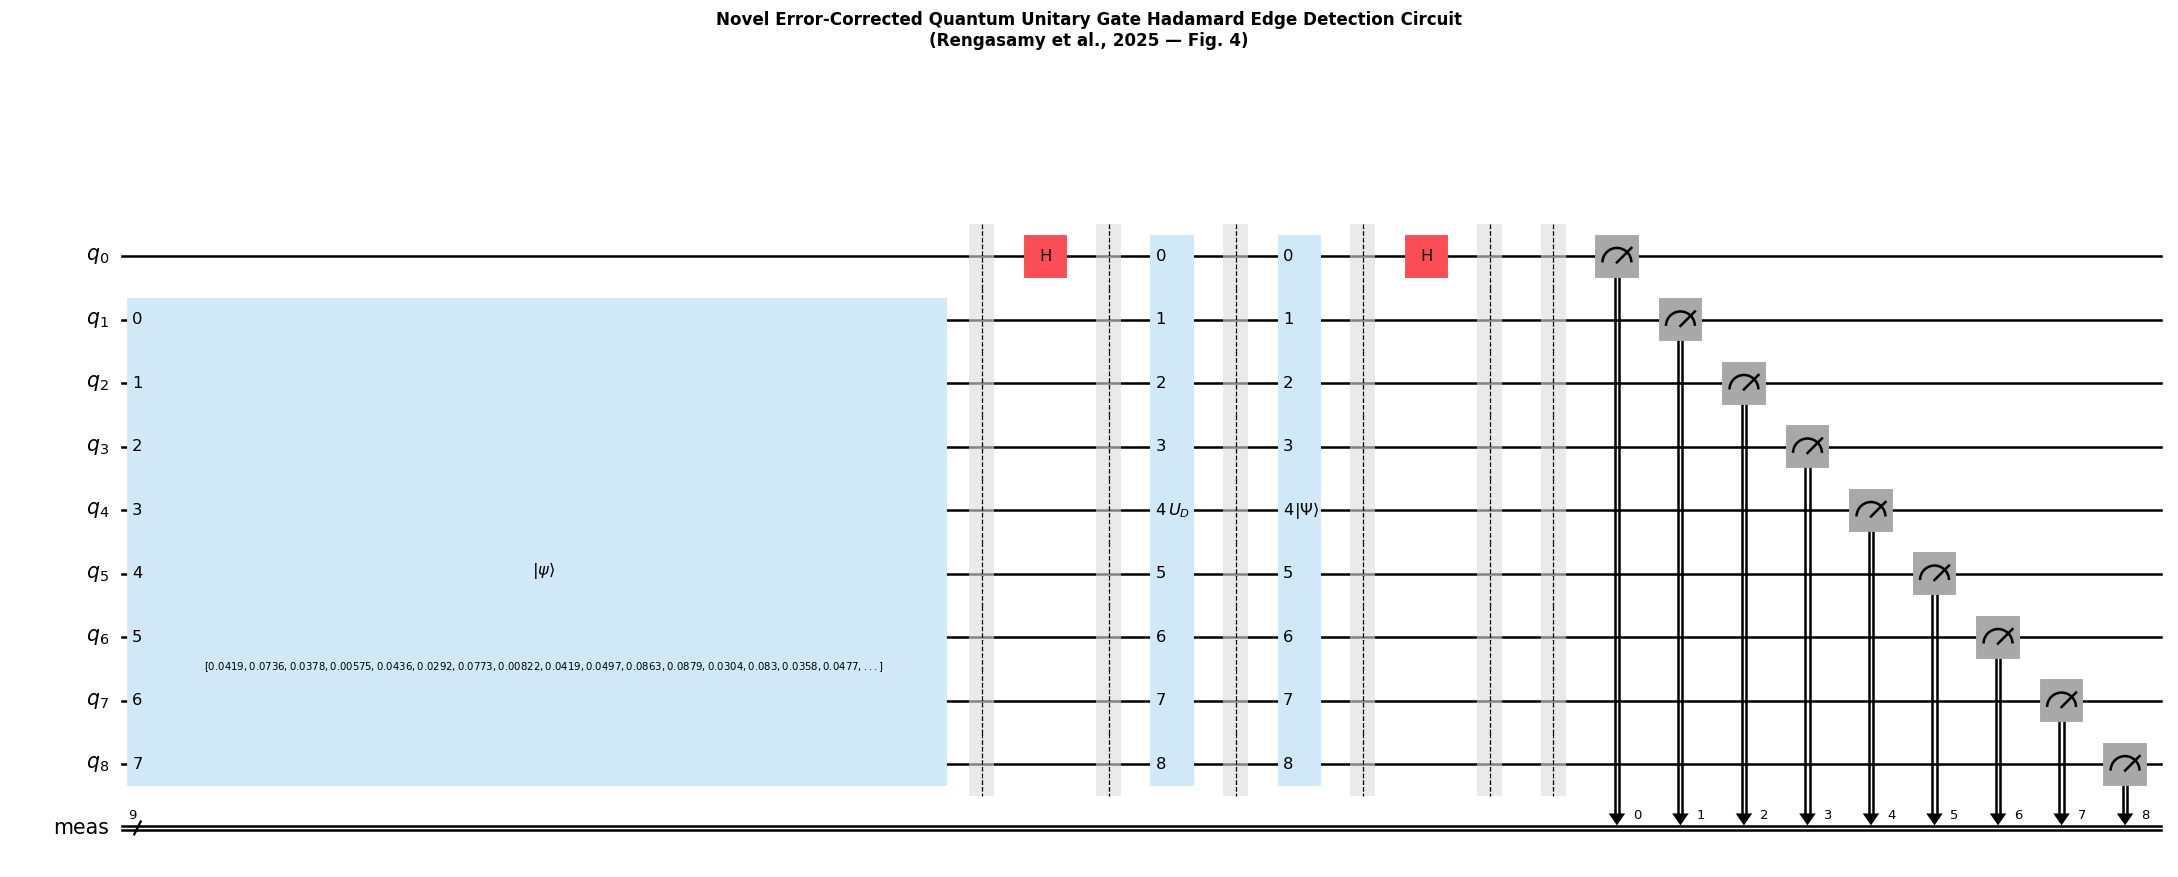


Diagram disimpan: ./results_paper1\quantum_circuit_hqehed.png


In [157]:
# Cell 3b - Visualisasi Sirkuit Kuantum HQEHED-AMT
# Sesuai Fig. 4 paper Rengasamy et al. (2025)
# 9 qubit: q0=ancilla (atas), q1-q8=data (256 piksel)
from qiskit.visualization import circuit_drawer
from qiskit.circuit import Gate
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Data QPIE: 256 piksel (8 data qubit = 2^8 = 256 state)
np.random.seed(42)
N_DATA_Q = 8
N_PIX    = 2 ** N_DATA_Q
ANCILLA  = 0
DATA_Q   = list(range(1, N_DATA_Q + 1))
TOTAL_Q  = N_DATA_Q + 1

pixels   = np.random.randint(0, 256, N_PIX).astype(np.float64)
amp_viz  = pixels / np.linalg.norm(pixels)

print('Sirkuit HQEHED-AMT sesuai Fig. 4 paper:')
print(f'  Qubit : {TOTAL_Q} (q0=ancilla, q1-q8=data)')
print(f'  Piksel: {N_PIX} | ||amp|| = {np.linalg.norm(amp_viz):.6f}')

# Bangun sirkuit: QPIE -> H -> U_D -> |Psi> -> H -> Measure
qc = QuantumCircuit(TOTAL_Q)
qc.initialize(amp_viz.tolist(), DATA_Q)
qc.barrier()
qc.h(ANCILLA)
qc.barrier()
qc.append(Gate('$U_D$', TOTAL_Q, []), list(range(TOTAL_Q)))
qc.barrier()
qc.append(Gate('$|\\Psi\\rangle$', TOTAL_Q, []), list(range(TOTAL_Q)))
qc.barrier()
qc.h(ANCILLA)
qc.barrier()
qc.measure_all()
print(f'  Depth: {qc.depth()}')

# Verifikasi (4px / 3 qubit)
seg4 = np.array([0.1, 0.7, 0.3, 0.9])
amp4 = seg4 / np.linalg.norm(seg4)
qc_v = QuantumCircuit(3)
qc_v.initialize(amp4.tolist(), [1, 2])
qc_v.h(0)
qc_v.x(1); qc_v.x(2)
qc_v.ccx(0, 1, 2)
qc_v.cx(0, 1)
qc_v.x(1); qc_v.x(2)
qc_v.h(0)
sv = np.real(Statevector(qc_v).data)
print('\nVerifikasi U_D (4px): diff[i] = (p_i - p_{i+1})/2')
all_ok = True
for j in range(4):
    got = sv[2*j + 1]
    exp = (amp4[j] - amp4[(j+1)%4]) / 2
    ok  = abs(got - exp) < 1e-5
    if not ok: all_ok = False
    print(f'  |{j:02b}>x|1>  {got:+.6f}  {exp:+.6f}  {"OK" if ok else "FAIL"}')
print(f'  -> {"SEMUA OK" if all_ok else "Ada error"}')

# Style PUTIH (mirip paper Fig. 4)
PAPER_STYLE = {
    'backgroundcolor':  '#ffffff',
    'textcolor':        '#000000',
    'gatetextcolor':    '#000000',
    'subtextcolor':     '#333333',
    'linecolor':        '#000000',
    'creglinecolor':    '#000000',
    'gatefacecolor':    '#d0e8f7',
    'controlbgcolor':   '#2166b2',
    'barrierfacecolor': '#dddddd',
    'measurebgcolor':   '#d0e8f7',
}

fig = plt.figure(figsize=(20, 9), facecolor='white')
fig.suptitle(
    'Novel Error-Corrected Quantum Unitary Gate Hadamard Edge Detection Circuit\n'
    '(Rengasamy et al., 2025 — Fig. 4)',
    color='#000000', fontsize=11, fontweight='bold', y=0.99)
ax = fig.add_axes([0.01, 0.02, 0.98, 0.88])
ax.set_facecolor('white'); ax.axis('off')
try:
    circuit_drawer(qc, output='mpl', style=PAPER_STYLE,
                   fold=-1, ax=ax, scale=0.78,
                   initial_state=False, plot_barriers=True)
    out_path = os.path.join(cfg.OUTPUT_DIR, 'quantum_circuit_hqehed.png')
    plt.savefig(out_path, dpi=130, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'\nDiagram disimpan: {out_path}')
except Exception as e:
    print(f'MPL gagal ({e}), fallback teks:'); print(qc.draw('text'))
plt.close('all')


## Cell 4 — Fungsi PSO-SVM & Metrik Evaluasi

> **Jangan ubah cell ini.**

| Fungsi / Kelas | Peran |
|---|---|
| `extract_patch_features` | Fitur lokal 5-dim per piksel (Bab 3.4) |
| `PSO_SVM_Optimizer` | PSO optimasi (C, γ) SVM-RBF (Bab 3.5) |
| `figure_of_merit` | Pratt's FOM (Pers. 2.39) |
| `dice_score`, `iou_score`, `evaluate_segmentation` | Metrik segmentasi |
| `edge_metrics` | Precision/Recall/F1 untuk edge map |
| `visualize_single`, `plot_pso_convergence`, `plot_metrics_bar` | Visualisasi |
| `_predict_full_image` | Prediksi piksel-per-piksel (inferensi SVM) |


In [158]:
# ── 1. Feature Maps & Ekstraksi Fitur (Bab 3.4) ─────────────────
#
# Mengikuti pendekatan code.py: untuk setiap feature map, diekstrak
# 3 statistik per piksel → center value, local mean, local std (patch 7×7)
# Total: 9 feature maps × 3 statistik = 27 fitur per piksel
#
# Tabel Feature Map:
# ┌──────────────┬───────────┬─────────────────────────────────────────┐
# │ Sumber       │ Map       │ Keterangan                              │
# ├──────────────┼───────────┼─────────────────────────────────────────┤
# │ Image asli   │ intensity │ Intensitas piksel ternormalisasi [0,1]  │
# │ Image asli   │ mean      │ Mean intensitas lokal (kernel 7×7)      │
# │ Image asli   │ std       │ Std dev intensitas lokal (kernel 7×7)   │
# │ Image asli   │ grad_mag  │ Magnitudo gradien Sobel                 │
# │ Image asli   │ grad_cos  │ Arah gradien — komponen cos             │
# │ Image asli   │ grad_sin  │ Arah gradien — komponen sin             │
# │ HQEHED edge  │ edge_flag │ Nilai tepi biner {0,1}                  │
# │ HQEHED edge  │ edge_den  │ Densitas tepi lokal (kernel 7×7)        │
# │ HQEHED edge  │ dist_edge │ Jarak ternormalisasi ke tepi terdekat   │
# └──────────────┴───────────┴─────────────────────────────────────────┘
# Per map: [center, local_mean, local_std] → 9 × 3 = 27 fitur total
# 18 fitur dari image asli | 9 fitur dari HQEHED edge map

_FM_KEYS = ["intensity", "mean", "std", "grad_mag", "grad_cos", "grad_sin",
            "edge_flag", "edge_density", "dist_to_edge"]
_KSIZE   = 7   # ukuran kernel lokal (harus ganjil)


def _build_feature_maps(img: np.ndarray, edge_map: np.ndarray) -> dict:
    """
    Hitung 9 base feature map, lalu untuk setiap map precompute
    local_mean dan local_std menggunakan kernel _KSIZE × _KSIZE.

    Return: dict  name → (center_arr, mean_arr, std_arr)
    Dipanggil sekali per citra; extract_patch_features & _predict_full_image
    keduanya memakai fungsi ini agar fitur identik.
    """
    img_f  = img.astype(np.float32)
    if img_f.max() > 1.0:
        img_f /= 255.0
    edge_f = (edge_map > 0).astype(np.float32)

    # ── Gradien ──────────────────────────────────────────────────
    gx       = cv2.Sobel(img_f, cv2.CV_32F, 1, 0, ksize=3)
    gy       = cv2.Sobel(img_f, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(gx**2 + gy**2)
    angle    = np.arctan2(gy, gx)

    # ── Statistik lokal intensitas ────────────────────────────────
    k       = (_KSIZE, _KSIZE)
    mean_i  = cv2.blur(img_f, k)
    std_i   = np.sqrt(np.clip(cv2.blur(img_f**2, k) - mean_i**2, 0, None))

    # ── Edge density & distance ───────────────────────────────────
    edge_den = cv2.blur(edge_f, k)
    inv_u8   = ((1.0 - edge_f) * 255).astype(np.uint8)
    dist     = cv2.distanceTransform(inv_u8, cv2.DIST_L2, 5)
    dist_norm = dist / (dist.max() + 1e-8)

    base = {
        "intensity":    img_f,
        "mean":         mean_i,
        "std":          std_i,
        "grad_mag":     grad_mag,
        "grad_cos":     np.cos(angle),
        "grad_sin":     np.sin(angle),
        "edge_flag":    edge_f,
        "edge_density": edge_den,
        "dist_to_edge": dist_norm,
    }

    # Precompute local mean & std of EACH feature map (patch statistics)
    result = {}
    for name in _FM_KEYS:
        fm      = base[name]
        fm_mean = cv2.blur(fm, k)
        fm_std  = np.sqrt(np.clip(cv2.blur(fm**2, k) - fm_mean**2, 0, None))
        result[name] = (fm, fm_mean, fm_std)   # (center, local_mean, local_std)
    return result


def _feat_vec(fm_dict: dict, y: int, x: int) -> list:
    """
    Ekstrak vektor fitur 27-dimensi pada piksel (y, x).
    Untuk setiap 9 feature map: [center, local_mean, local_std].
    """
    feat = []
    for name in _FM_KEYS:
        c, m, s = fm_dict[name]
        feat.extend([float(c[y, x]), float(m[y, x]), float(s[y, x])])
    return feat   # 27 fitur


def extract_patch_features(img: np.ndarray,
                           edge_map: np.ndarray,
                           mask: np.ndarray,
                           n_samples: int,
                           patch: int = cfg.PATCH_SIZE) -> tuple:
    """
    Sampling 1:3 (tumor:non-tumor) — mendekati distribusi nyata MRI.
    Vektor fitur 27-dimensi per piksel (9 map × 3 statistik).
    """
    fm   = _build_feature_maps(img, edge_map)

    tumor_coords     = list(zip(*np.where(mask == 1)))
    non_tumor_coords = list(zip(*np.where(mask == 0)))
    # Rasio 1:3 (tumor:non-tumor) — lebih mendekati distribusi nyata MRI
    n_tumor    = min(n_samples // 4, len(tumor_coords))
    n_nontumor = min(n_tumor * 3,    len(non_tumor_coords))
    if n_tumor == 0:
        return np.array([]), np.array([])

    coords = (random.sample(tumor_coords,     n_tumor) +
              random.sample(non_tumor_coords, n_nontumor))
    labels = [1] * n_tumor + [0] * n_nontumor

    features = [_feat_vec(fm, y, x) for (y, x) in coords]
    return (np.array(features, dtype=np.float32),
            np.array(labels,   dtype=np.int32))


# ── 2. PSO Optimizer (Bab 3.5) ───────────────────────────────────
class PSO_SVM_Optimizer:
    """PSO mengoptimasi (C, γ) SVM-RBF. Fitness = Dice pada validasi set."""

    def __init__(self, X_train, y_train, X_val, y_val,
                 n_particles=cfg.PSO_PARTICLES, n_iter=cfg.PSO_ITERATIONS,
                 w=cfg.PSO_W, c1=cfg.PSO_C1, c2=cfg.PSO_C2,
                 C_range=cfg.PSO_C_RANGE, g_range=cfg.PSO_G_RANGE):
        self.X_train = X_train;  self.y_train = y_train
        self.X_val   = X_val;    self.y_val   = y_val
        self.n_p     = n_particles;  self.n_iter = n_iter
        self.w = w;  self.c1 = c1;  self.c2 = c2
        self.bounds  = np.array([C_range, g_range])
        self.pos     = np.random.uniform(self.bounds[:, 0], self.bounds[:, 1],
                                         size=(self.n_p, 2))
        self.vel     = np.zeros_like(self.pos)
        self.pbest   = self.pos.copy()
        self.pbest_fit = np.full(self.n_p, -np.inf)
        self.gbest   = None
        self.gbest_fit = -np.inf
        self.history = []

    def _fitness(self, pos_row):
        C = 10.0 ** pos_row[0];  g = 10.0 ** pos_row[1]
        try:
            clf = SVC(C=C, gamma=g, kernel="rbf", class_weight="balanced")
            clf.fit(self.X_train, self.y_train)
            pred = clf.predict(self.X_val)
            tp = np.sum((pred == 1) & (self.y_val == 1))
            fp = np.sum((pred == 1) & (self.y_val == 0))
            fn = np.sum((pred == 0) & (self.y_val == 1))
            denom = 2 * tp + fp + fn
            return float(2 * tp / denom) if denom > 0 else 0.0
        except Exception:
            return 0.0

    def optimize(self, verbose=True):
        """Jalankan PSO — Pers. (2.27)–(2.28). Return: (C_opt, g_opt, history)."""
        for i in range(self.n_p):
            fit = self._fitness(self.pos[i])
            self.pbest_fit[i] = fit
            if fit > self.gbest_fit:
                self.gbest_fit = fit;  self.gbest = self.pos[i].copy()

        if verbose:
            print(f"\n{'─'*55}")
            print(f"  PSO: {self.n_p} partikel  |  {self.n_iter} iterasi")
            print(f"{'─'*55}")

        for t in range(self.n_iter):
            r1 = np.random.rand(self.n_p, 2)
            r2 = np.random.rand(self.n_p, 2)
            self.vel = (self.w  * self.vel
                        + self.c1 * r1 * (self.pbest - self.pos)
                        + self.c2 * r2 * (self.gbest  - self.pos))
            self.pos += self.vel
            self.pos  = np.clip(self.pos, self.bounds[:, 0], self.bounds[:, 1])

            for i in range(self.n_p):
                fit = self._fitness(self.pos[i])
                if fit > self.pbest_fit[i]:
                    self.pbest_fit[i] = fit;  self.pbest[i] = self.pos[i].copy()
                if fit > self.gbest_fit:
                    self.gbest_fit = fit;  self.gbest = self.pos[i].copy()

            self.history.append(self.gbest_fit)
            if verbose and (t + 1) % 10 == 0:
                print(f"  Iter {t+1:3d}/{self.n_iter}  "
                      f"gbest Dice={self.gbest_fit:.4f}  "
                      f"C={10.**self.gbest[0]:.4f}  "
                      f"γ={10.**self.gbest[1]:.6f}")

        return 10.**self.gbest[0], 10.**self.gbest[1], self.history


# ── 3. Metrik Evaluasi (Bab 2.12) ────────────────────────────────
def figure_of_merit(edge_det: np.ndarray,
                    edge_gt:  np.ndarray,
                    alpha: float = cfg.ALPHA_FOM) -> float:
    """Pratt's FOM — Pers. (2.39) proposal."""
    det_pts = np.argwhere(edge_det == 1)
    gt_pts  = np.argwhere(edge_gt  == 1)
    Nd, Ng  = len(det_pts), len(gt_pts)
    if Nd == 0 and Ng == 0: return 1.0
    if Nd == 0 or  Ng == 0: return 0.0
    denom = max(Nd, Ng)
    total = sum(1.0 / (1.0 + alpha * np.sum((gt_pts - pt)**2, axis=1).min())
                for pt in det_pts)
    return total / denom


def dice_score(pred, gt):
    tp = np.sum((pred==1)&(gt==1)); fp = np.sum((pred==1)&(gt==0))
    fn = np.sum((pred==0)&(gt==1))
    return 2*tp / (2*tp + fp + fn + 1e-8)


def iou_score(pred, gt):
    tp = np.sum((pred==1)&(gt==1)); fp = np.sum((pred==1)&(gt==0))
    fn = np.sum((pred==0)&(gt==1))
    return tp / (tp + fp + fn + 1e-8)


def evaluate_segmentation(pred_mask, gt_mask) -> dict:
    pred_flat = pred_mask.ravel(); gt_flat = gt_mask.ravel()
    tp = np.sum((pred_flat==1)&(gt_flat==1)); tn = np.sum((pred_flat==0)&(gt_flat==0))
    fp = np.sum((pred_flat==1)&(gt_flat==0)); fn = np.sum((pred_flat==0)&(gt_flat==1))
    return {
        "Accuracy":    (tp+tn)/(tp+tn+fp+fn+1e-8),
        "Sensitivity": tp/(tp+fn+1e-8),
        "Specificity": tn/(tn+fp+1e-8),
        "IoU":         iou_score(pred_mask, gt_mask),
        "Dice":        dice_score(pred_mask, gt_mask),
    }


def edge_metrics(edge_det, edge_gt) -> dict:
    """Precision, Recall, F1 untuk evaluasi edge map."""
    tp = np.sum((edge_det==1)&(edge_gt==1))
    fp = np.sum((edge_det==1)&(edge_gt==0))
    fn = np.sum((edge_det==0)&(edge_gt==1))
    prec = tp/(tp+fp+1e-8);  rec = tp/(tp+fn+1e-8)
    return {"Precision": prec, "Recall": rec,
            "F1": 2*prec*rec/(prec+rec+1e-8),
            "TP": int(tp), "FP": int(fp), "FN": int(fn)}


# ── 4. Visualisasi PSO-SVM ────────────────────────────────────────
def visualize_single(img, gt_mask, edge_map, pred_seg, metrics, fom,
                     save_path=None):
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.patch.set_facecolor("#0d1117")
    for ax, title, im, cm in zip(
            axes,
            ["Citra MRI", "Ground Truth Mask",
             "HQEHED-AMT Edge Map", "Segmentasi PSO-SVM"],
            [img, gt_mask, edge_map, pred_seg],
            ["gray", "gray", "hot", "cool"]):
        ax.imshow(im, cmap=cm, interpolation="nearest")
        ax.set_title(title, color="white", fontsize=11, pad=8)
        ax.axis("off")
    metric_str = (f"Dice={metrics['Dice']:.4f}  IoU={metrics['IoU']:.4f}  "
                  f"Acc={metrics['Accuracy']:.4f}  "
                  f"Sen={metrics['Sensitivity']:.4f}  "
                  f"Spe={metrics['Specificity']:.4f}  FOM={fom:.4f}")
    fig.text(0.5, 0.01, metric_str, ha="center", color="#8b949e",
             fontsize=9.5, style="italic")
    fig.suptitle("HQEHED-AMT + PSO-SVM — Segmentasi Tumor Otak MRI",
                 color="white", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight",
                    facecolor="#0d1117")
    plt.show(); plt.close()


def plot_pso_convergence(history, save_path=None):
    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor("#0d1117"); ax.set_facecolor("#161b22")
    ax.plot(range(1, len(history)+1), history,
            color="#58a6ff", linewidth=2, marker="o",
            markersize=3, markerfacecolor="#f78166")
    ax.set_xlabel("Iterasi PSO", color="white")
    ax.set_ylabel("Dice (Global Best)", color="white")
    ax.set_title("Kurva Konvergensi PSO — Optimasi Hyperparameter SVM",
                 color="white", fontweight="bold")
    ax.tick_params(colors="white"); ax.grid(True, color="#21262d", linewidth=0.8)
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight", facecolor="#0d1117")
    plt.show(); plt.close()


def plot_metrics_bar(metrics, fom, save_path=None):
    all_m  = {**metrics, "FOM": fom}
    names  = list(all_m.keys()); values = list(all_m.values())
    colors = ["#58a6ff", "#56d364", "#f78166",
              "#e3b341", "#bc8cff", "#39d353"]
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor("#0d1117"); ax.set_facecolor("#161b22")
    bars = ax.bar(names, values, color=colors[:len(names)],
                  edgecolor="#30363d", width=0.6)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.4f}", ha="center", color="white", fontsize=10)
    ax.set_ylim(0, 1.15); ax.set_ylabel("Nilai", color="white")
    ax.set_title("Metrik Evaluasi — HQEHED-AMT + PSO-SVM",
                 color="white", fontweight="bold")
    ax.tick_params(colors="white"); ax.grid(axis="y", color="#21262d")
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight", facecolor="#0d1117")
    plt.show(); plt.close()


def _predict_full_image(img, edge_map, clf, scaler, patch=cfg.PATCH_SIZE):
    """
    Prediksi segmentasi piksel-per-piksel (step=1, full resolution).
    Fitur identik dengan training via _build_feature_maps + _feat_vec.
    """
    H, W    = img.shape
    fm      = _build_feature_maps(img, edge_map)
    # Bangun feature matrix sekaligus — lebih cepat dari loop per-piksel
    feat_arrays = []
    for name in _FM_KEYS:
        c, m, s = fm[name]
        feat_arrays.extend([c.ravel(), m.ravel(), s.ravel()])
    X_full  = np.column_stack(feat_arrays).astype(np.float32)  # (H*W, 27)
    preds   = clf.predict(scaler.transform(X_full))
    return preds.reshape(H, W).astype(np.uint8)



# ── Feature maps TANPA edge (18-D) — digunakan untuk ablasi ─────────────────
# Tanpa edge_flag / edge_density / dist_to_edge; fitur murni dari citra input.
_FM_KEYS_NOEDGE = ['intensity', 'mean', 'std', 'grad_mag', 'grad_cos', 'grad_sin']


def _build_feature_maps_noedge(img: np.ndarray) -> dict:
    img_f  = img.astype(np.float32)
    if img_f.max() > 1.0:
        img_f /= 255.0
    gx     = cv2.Sobel(img_f, cv2.CV_32F, 1, 0, ksize=3)
    gy     = cv2.Sobel(img_f, cv2.CV_32F, 0, 1, ksize=3)
    k      = (_KSIZE, _KSIZE)
    mean_i = cv2.blur(img_f, k)
    std_i  = np.sqrt(np.clip(cv2.blur(img_f**2, k) - mean_i**2, 0, None))
    angle  = np.arctan2(gy, gx)
    base   = {
        'intensity': img_f,   'mean': mean_i,    'std': std_i,
        'grad_mag' : np.sqrt(gx**2 + gy**2),
        'grad_cos' : np.cos(angle),               'grad_sin': np.sin(angle),
    }
    result = {}
    for name in _FM_KEYS_NOEDGE:
        fm      = base[name]
        fm_mean = cv2.blur(fm, k)
        fm_std  = np.sqrt(np.clip(cv2.blur(fm**2, k) - fm_mean**2, 0, None))
        result[name] = (fm, fm_mean, fm_std)
    return result


def _feat_vec_noedge(fm_dict: dict, y: int, x: int) -> list:
    feat = []
    for name in _FM_KEYS_NOEDGE:
        c, m, s = fm_dict[name]
        feat.extend([float(c[y, x]), float(m[y, x]), float(s[y, x])])
    return feat   # 18 fitur


def _predict_full_noedge(img, clf, scaler):
    H, W = img.shape
    fmd  = _build_feature_maps_noedge(img)
    arrs = []
    for name in _FM_KEYS_NOEDGE:
        c, m, s = fmd[name]
        arrs.extend([c.ravel(), m.ravel(), s.ravel()])
    X = np.column_stack(arrs).astype(np.float32)
    return clf.predict(scaler.transform(X)).reshape(H, W).astype(np.uint8)

print("Fungsi PSO-SVM, metrik, dan visualisasi berhasil dimuat.")
print("  ✓ _build_feature_maps_noedge | _feat_vec_noedge (18D ablasi)")

Fungsi PSO-SVM, metrik, dan visualisasi berhasil dimuat.
  ✓ _build_feature_maps_noedge | _feat_vec_noedge (18D ablasi)


## Cell 5 — Load Dataset

In [159]:
print("Memuat dataset ...")
pairs = load_dataset_paths(cfg.DATA_ROOT)

if len(pairs) == 0:
    print(f"  PERINGATAN: Tidak ada data ditemukan di {cfg.DATA_ROOT}")
    print("  Pastikan struktur folder dataset sudah benar:")
    print("    dataset/<tumor>/images/<file>.png")
    print("    dataset/<tumor>/masks/<file>.png")
    pairs = []
    QUICK_SAMPLES = []
else:
    if cfg.MAX_IMAGES is not None:
        pairs = pairs[:cfg.MAX_IMAGES]
    QUICK_SAMPLES = pairs[:5]
    print(f"  Total pasang citra/mask : {len(pairs)}")
    print(f"  QUICK_SAMPLES           : {len(QUICK_SAMPLES)} citra")

Memuat dataset ...
  Total pasang citra/mask : 30
  QUICK_SAMPLES           : 5 citra


## Cell 6 — Parameter Tuning (UBAH DI SINI)

---

### Grup A — Pra-pemrosesan
| Parameter | Efek |
|---|---|
| `GAUSS_KSIZE` | Ukuran kernel blur (ganjil: 3/5/7) |
| `GAUSS_SIGMA` | Kekuatan blur; ↑ = lebih halus, ↓ = lebih tajam |

### Grup B — AMT Core ← **PALING BERPENGARUH**
| Parameter | Efek |
|---|---|
| `GAMMA` | Ambang tepi positif; **↑ = lebih sedikit tepi** |
| `GAMMA_NEG` | Ambang tepi negatif; **↑ = lebih sedikit tepi** |

### Grup C — Ukuran Crop
| Parameter | Efek |
|---|---|
| `CROP_SIZE` | Panjang segmen tiap scan; kecil=detail tinggi, besar=cepat |

---
Setelah mengubah parameter, jalankan **Cell 7** untuk melihat hasilnya.


In [160]:
# ══════════════════════════════════════════════════════
# UBAH PARAMETER DI SINI
# ══════════════════════════════════════════════════════

# Grup A — Pra-pemrosesan
GAUSS_KSIZE = 3       # ganjil: 3, 5, 7
GAUSS_SIGMA = 0.5     # 0.3 – 2.0

# Grup B — AMT Core (paling berpengaruh)
GAMMA       = 1    # 0.10 – 0.60
GAMMA_NEG   = 1    # 0.10 – 0.60

# Grup C — Crop
# Catatan Quantum Simulator: crop_size HARUS pangkat 2.
# Dibulatkan otomatis oleh hqehed_amt. Rekomendasi:
#   64  → 6 qubit  (~cepat, 512×512 image)
#   32  → 5 qubit  (~lebih cepat, lebih banyak crop)
CROP_SIZE   = 512      

# ══════════════════════════════════════════════════════
print(f"Parameter aktif:")
print(f"  Pra-pemrosesan : GAUSS_KSIZE={GAUSS_KSIZE}  GAUSS_SIGMA={GAUSS_SIGMA}")
print(f"  AMT            : GAMMA={GAMMA}  GAMMA_NEG={GAMMA_NEG}")
print(f"  Crop           : CROP_SIZE={CROP_SIZE}  (dibulatkan ke pangkat 2 jika perlu)")


Parameter aktif:
  Pra-pemrosesan : GAUSS_KSIZE=3  GAUSS_SIGMA=0.5
  AMT            : GAMMA=1  GAMMA_NEG=1
  Crop           : CROP_SIZE=512  (dibulatkan ke pangkat 2 jika perlu)


## Cell 7 — Quick Visualization (~5 citra)

Jalankan HQEHED-AMT pada `QUICK_SAMPLES` dengan parameter dari Cell 6.
Output: **MSE dan PSNR** rata-rata (sesuai Pers. 2.18–2.19), disimpan ke `results_quick`.


In [161]:
if not QUICK_SAMPLES:
    print("Dataset belum dimuat. Jalankan Cell 5 terlebih dahulu.")
else:
    def _mse_psnr(src, edg):
        """MSE & PSNR antara citra sumber [0,1] dan edge map [0,1] (Pers. 2.18–2.19, R=255)."""
        mse  = float(np.mean((src.astype(np.float64) - edg.astype(np.float64)) ** 2))
        psnr = float(10.0 * np.log10(255.0 ** 2 / mse)) if mse > 0 else 100.0
        return mse, psnr

    results_quick = []
    for img_path, mask_path in tqdm(QUICK_SAMPLES, desc="Quick-Viz"):
        img_raw, gt_mask    = load_image_mask(img_path, mask_path, cfg.IMG_SIZE)
        img_pre             = preprocess(img_raw, GAUSS_KSIZE, GAUSS_SIGMA)
        edge_hqehed_raw     = hqehed_amt(img_pre, CROP_SIZE, GAMMA, GAMMA_NEG)
        edge_hqehed         = edge_hqehed_raw.copy()
        edge_canny          = cv2.Canny(
            (img_pre * 255).astype(np.uint8), 50, 150) // 255
        gt_edge             = cv2.Canny(
            (gt_mask * 255).astype(np.uint8), 50, 150) // 255

        mse_hqehed,     psnr_hqehed     = _mse_psnr(img_pre, edge_hqehed)
        mse_hqehed_raw, psnr_hqehed_raw = _mse_psnr(img_pre, edge_hqehed_raw)
        mse_canny,      psnr_canny       = _mse_psnr(img_pre, edge_canny)
        fom_hqehed     = figure_of_merit(edge_hqehed,     gt_edge)
        fom_hqehed_raw = figure_of_merit(edge_hqehed_raw, gt_edge)
        fom_canny      = figure_of_merit(edge_canny,      gt_edge)

        results_quick.append({
            "img_raw":      img_raw,   "img_pre":   img_pre,
            "gt_mask":      gt_mask,   "gt_edge":   gt_edge,
            "edge_hqehed_raw": edge_hqehed_raw,
            "edge_hqehed":     edge_hqehed,
            "edge_canny":      edge_canny,
            "mse_hqehed":      mse_hqehed,     "psnr_hqehed":     psnr_hqehed,
            "fom_hqehed":      fom_hqehed,
            "mse_hqehed_raw":  mse_hqehed_raw, "psnr_hqehed_raw": psnr_hqehed_raw,
            "fom_hqehed_raw":  fom_hqehed_raw,
            "mse_canny":       mse_canny,      "psnr_canny":       psnr_canny,
            "fom_canny":       fom_canny,
        })

    print(f"\nSelesai \u2014 {len(results_quick)} citra diproses.")
    print(f"  PSNR HQEHED raw  : {np.mean([r['psnr_hqehed_raw'] for r in results_quick]):.4f} dB")
    print(f"  PSNR HQEHED      : {np.mean([r['psnr_hqehed']     for r in results_quick]):.4f} dB")
    print(f"  PSNR Canny        : {np.mean([r['psnr_canny']      for r in results_quick]):.4f} dB")
    print(f"  MSE  HQEHED raw  : {np.mean([r['mse_hqehed_raw']  for r in results_quick]):.4f}")
    print(f"  MSE  HQEHED      : {np.mean([r['mse_hqehed']      for r in results_quick]):.4f}")
    print(f"  MSE  Canny        : {np.mean([r['mse_canny']       for r in results_quick]):.4f}")
    print(f"  FOM  HQEHED raw  : {np.mean([r['fom_hqehed_raw']  for r in results_quick]):.4f}")
    print(f"  FOM  HQEHED      : {np.mean([r['fom_hqehed']      for r in results_quick]):.4f}")
    print(f"  FOM  Canny        : {np.mean([r['fom_canny']       for r in results_quick]):.4f}")


Quick-Viz: 100%|██████████| 5/5 [03:32<00:00, 42.41s/it]


Selesai — 5 citra diproses.
  PSNR HQEHED raw  : 51.1985 dB
  PSNR HQEHED      : 51.1985 dB
  PSNR Canny        : 60.8243 dB
  MSE  HQEHED raw  : 0.4935
  MSE  HQEHED      : 0.4935
  MSE  Canny        : 0.0540
  FOM  HQEHED raw  : 0.0031
  FOM  HQEHED      : 0.0031
  FOM  Canny        : 0.0070


## Cell 8 — Visualisasi Panel Utama (5 kolom)

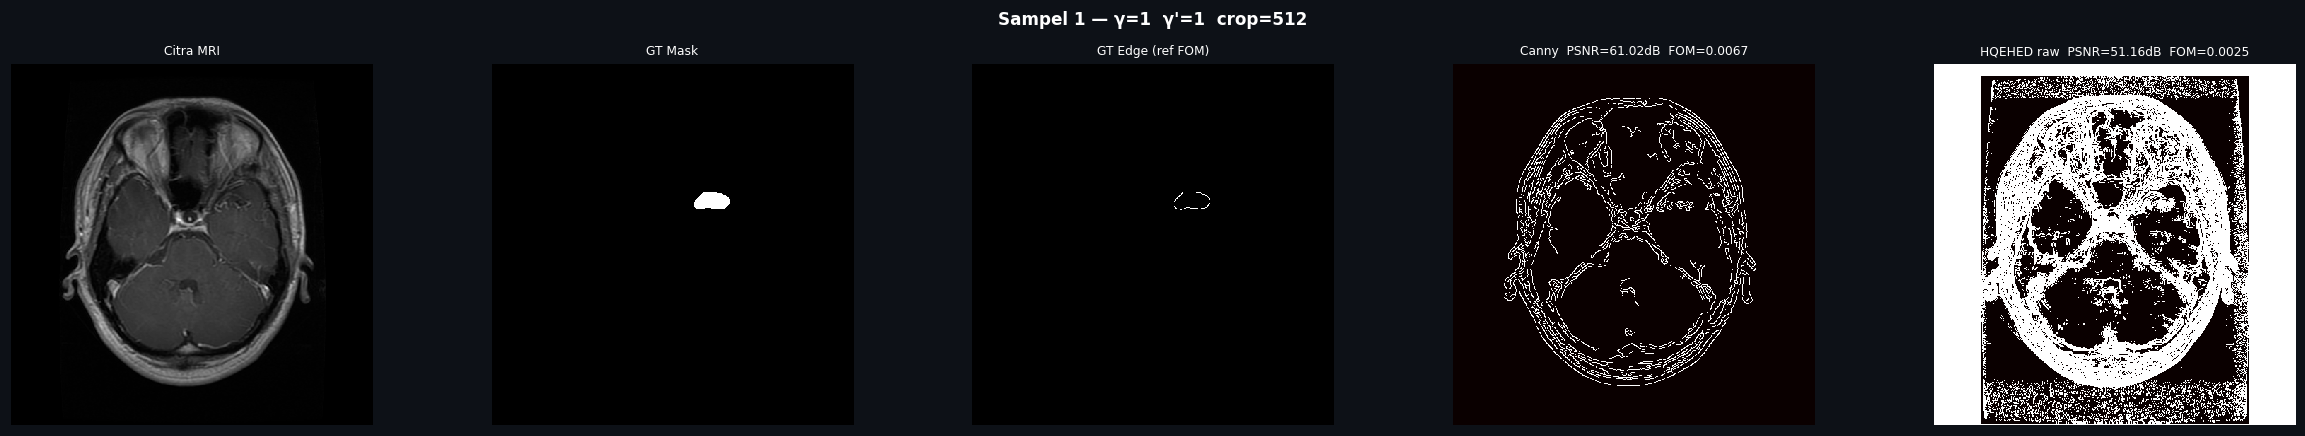

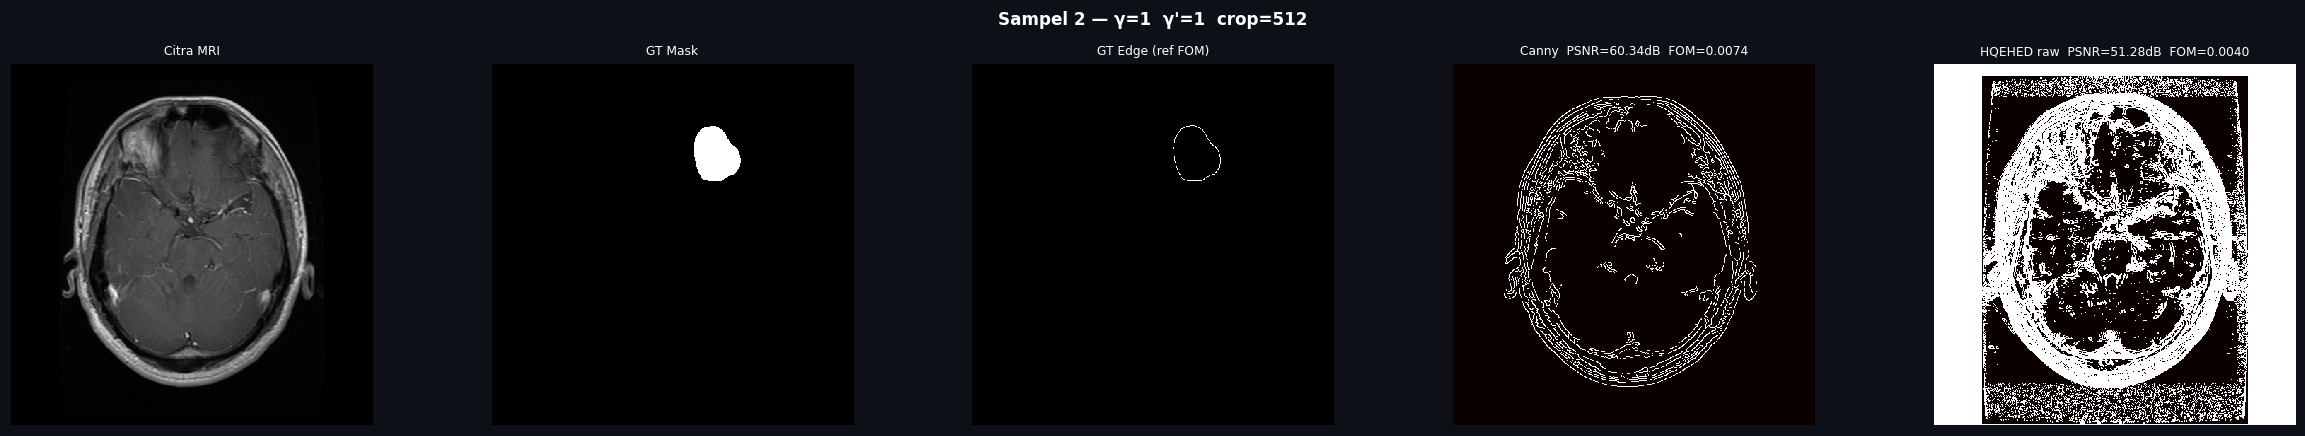

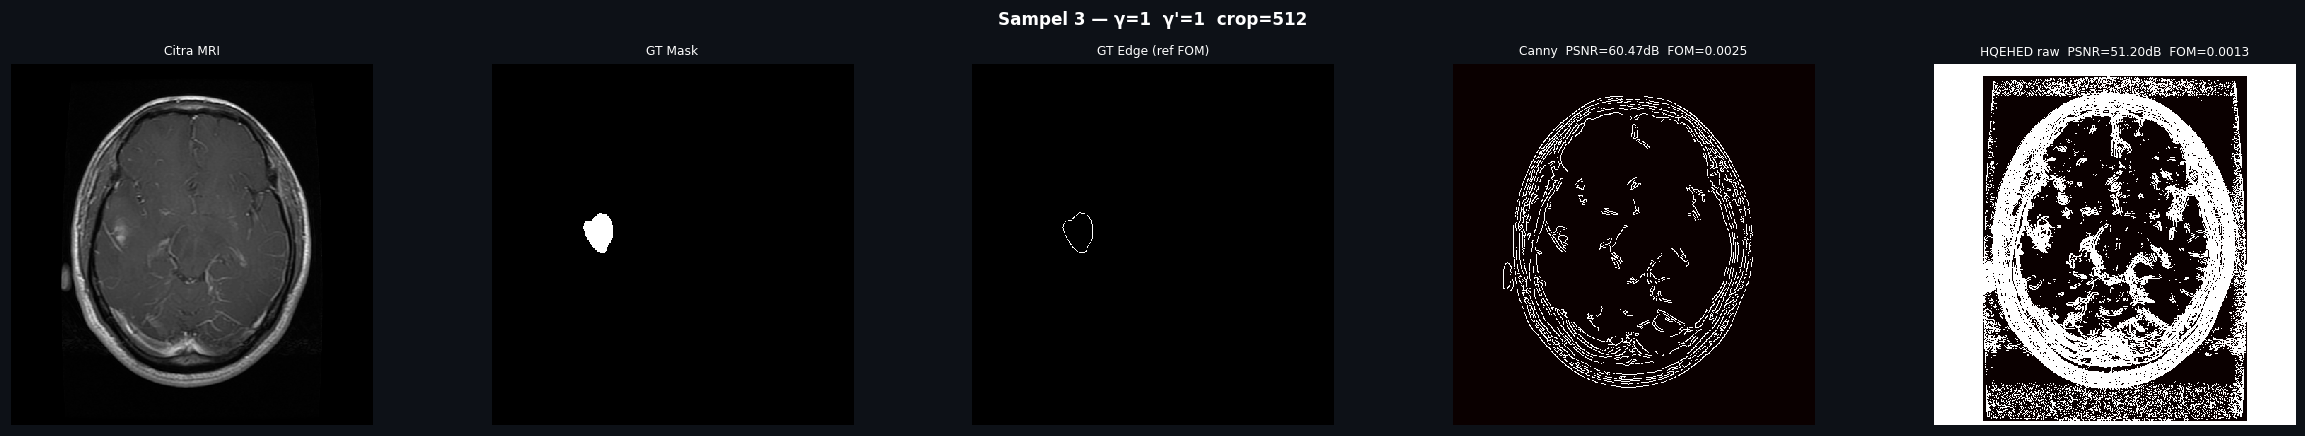

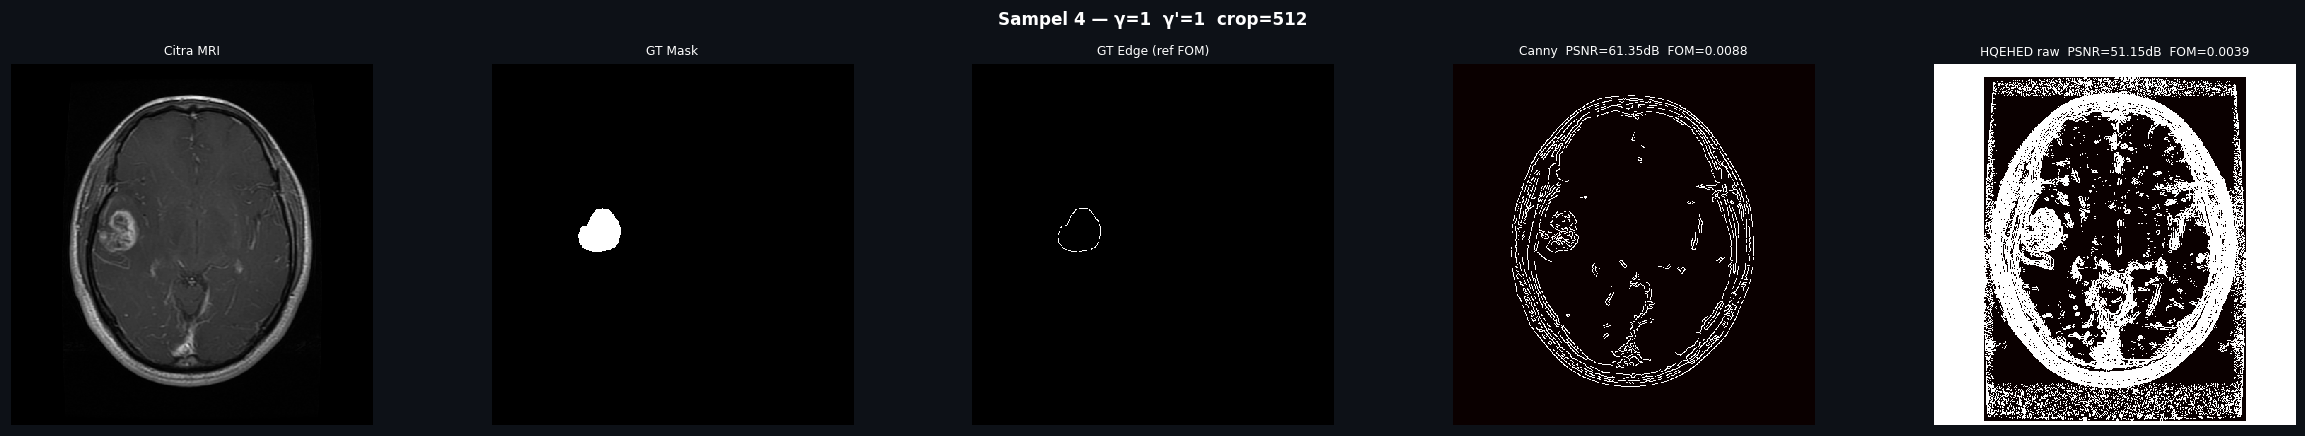

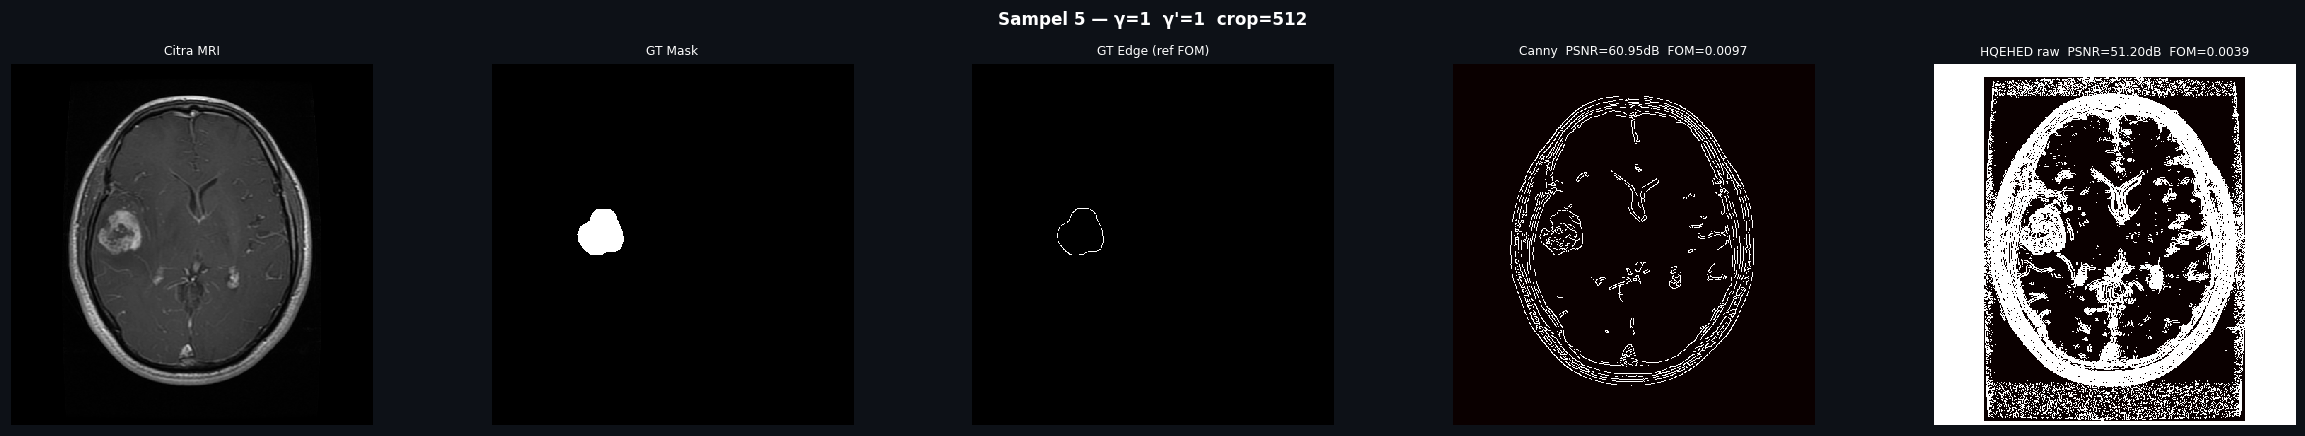

In [162]:
for i, r in enumerate(results_quick):
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    fig.patch.set_facecolor("#0d1117")

    panels = [
        (r["img_raw"], "Citra MRI", "gray"),
        (r["gt_mask"], "GT Mask", "gray"),
        (r["gt_edge"], "GT Edge (ref FOM)", "gray"),
        (r["edge_canny"],
         f"Canny  PSNR={r['psnr_canny']:.2f}dB  FOM={r['fom_canny']:.4f}", "hot"),
        (r["edge_hqehed_raw"],
         f"HQEHED raw  PSNR={r['psnr_hqehed_raw']:.2f}dB  FOM={r['fom_hqehed_raw']:.4f}", "hot"),
    ]

    for ax, (im, title, cm) in zip(axes, panels):
        ax.imshow(im, cmap=cm, interpolation="nearest")
        ax.set_title(title, color="white", fontsize=8, pad=6)
        ax.axis("off")

    fig.suptitle(
        f"Sampel {i+1} — γ={GAMMA}  γ'={GAMMA_NEG}  crop={CROP_SIZE}",
        color="white", fontsize=11, fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig(
        os.path.join(cfg.OUTPUT_DIR, f"panel_{i+1}.png"),
        dpi=100,
        bbox_inches="tight",
        facecolor="#0d1117"
    )
    plt.show()
    plt.close()

## Cell 9 — Overlay + Error Map (TP/FP/FN)

- Hijau = TP (terdeteksi & benar)  
- Merah = FP (terdeteksi tapi salah)  
- Biru  = FN (terlewat)

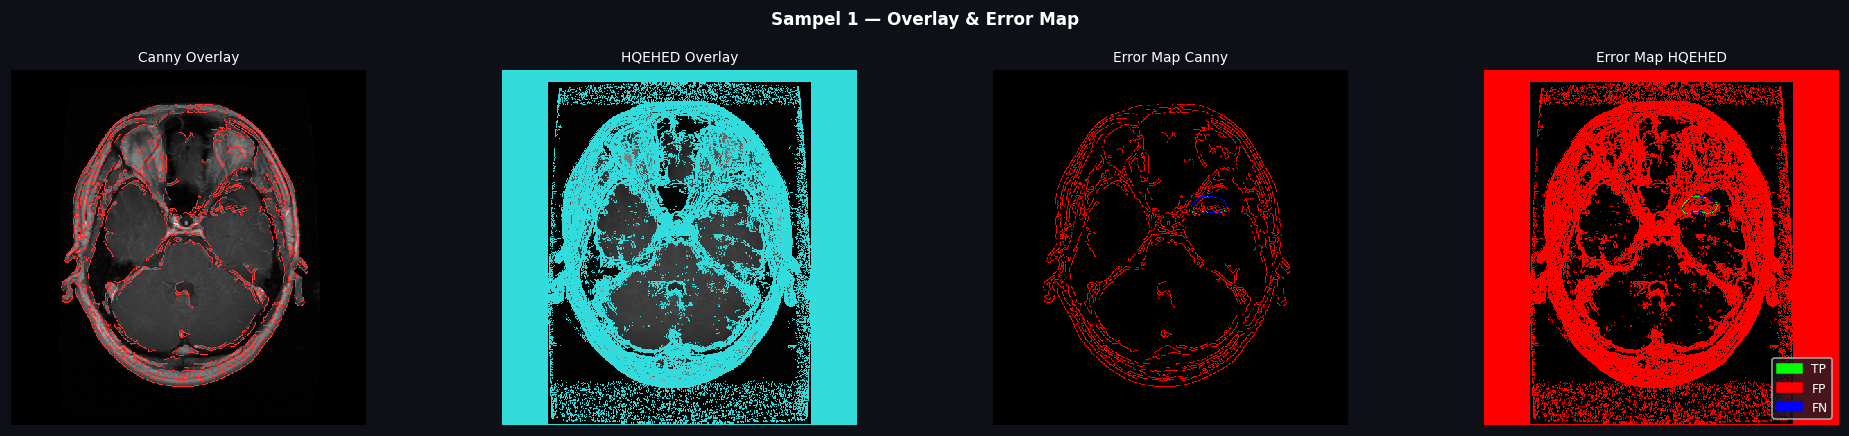

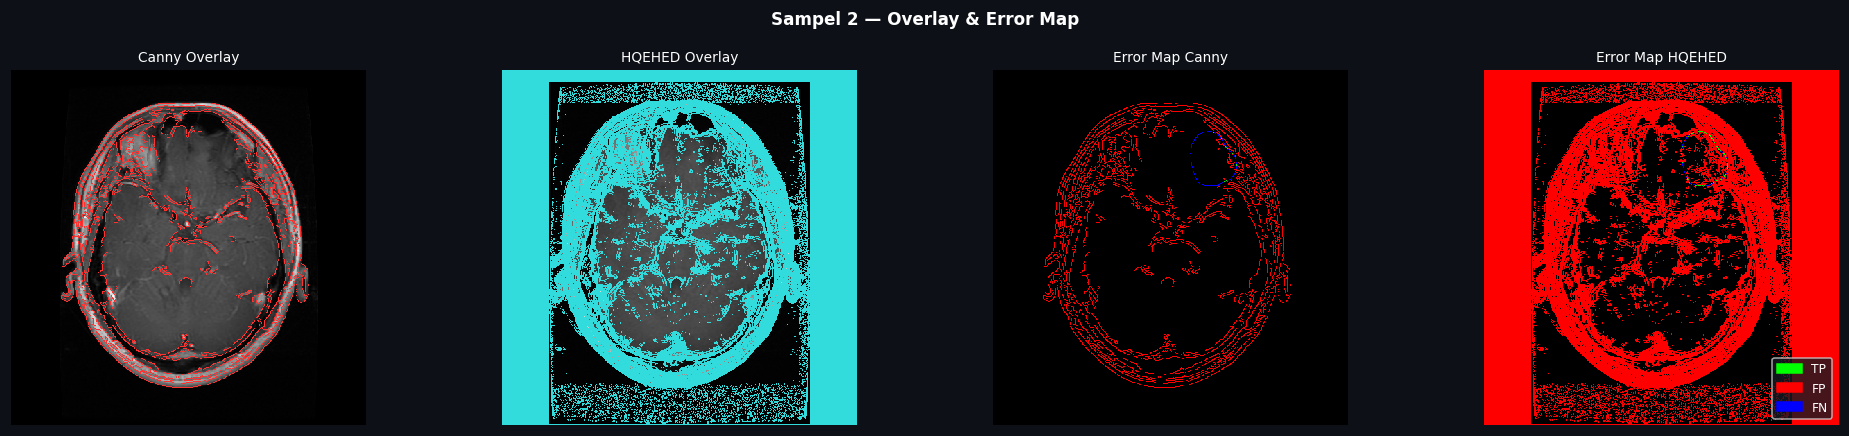

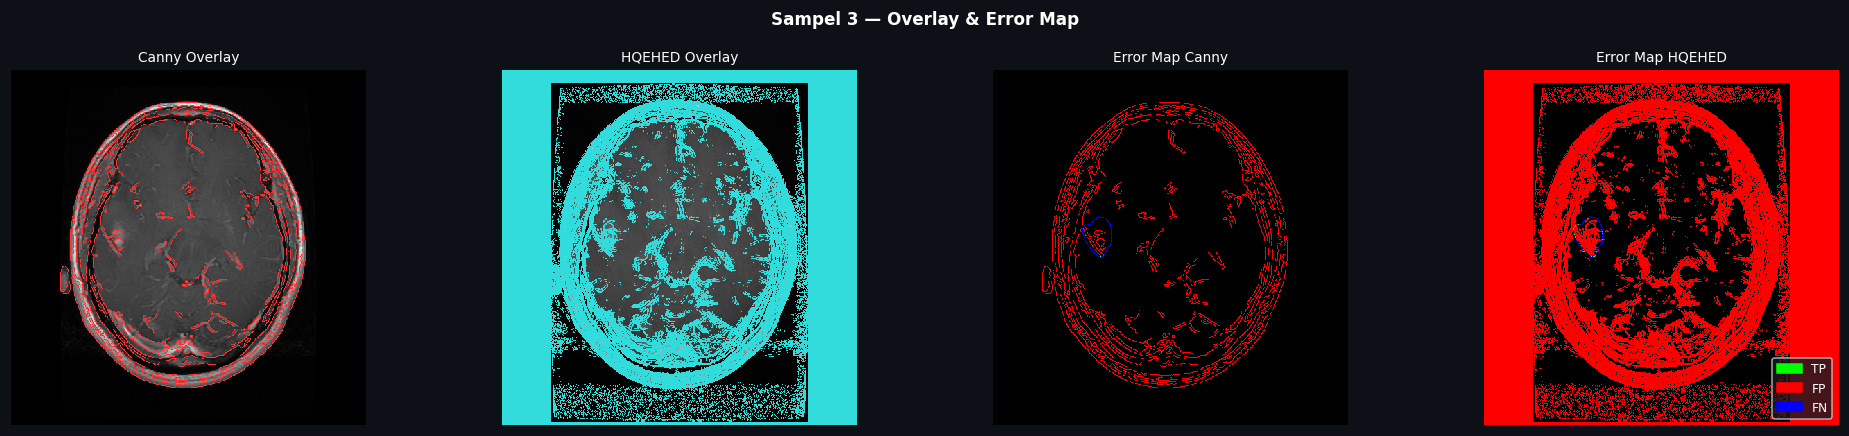

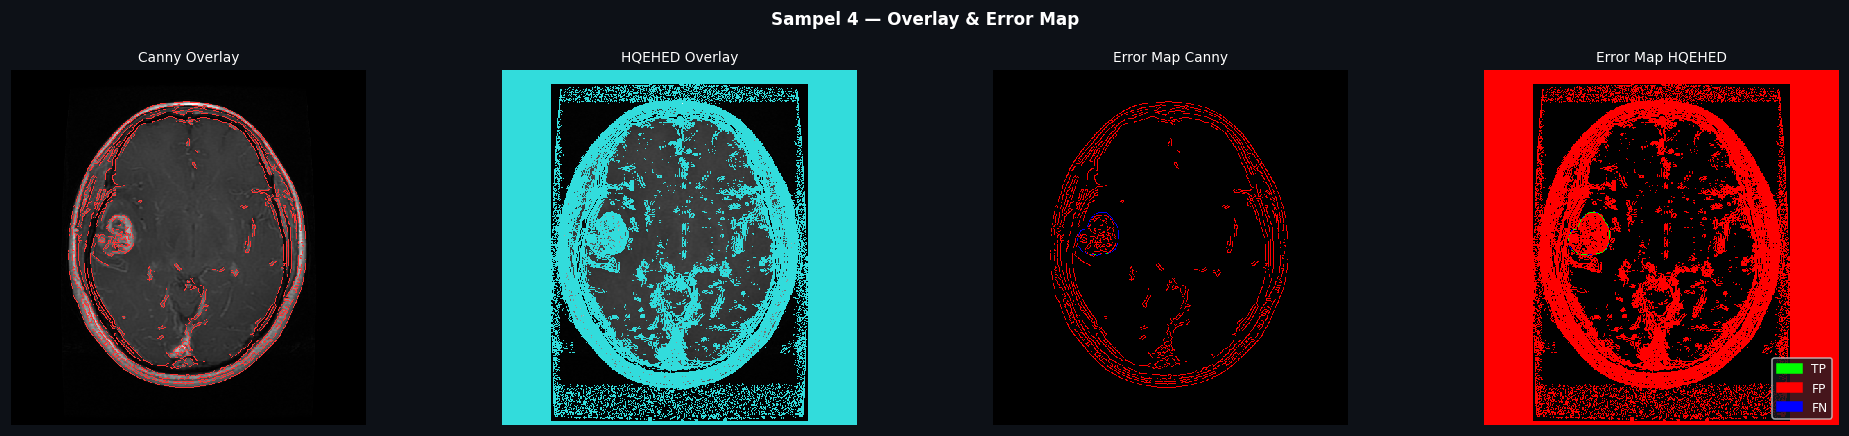

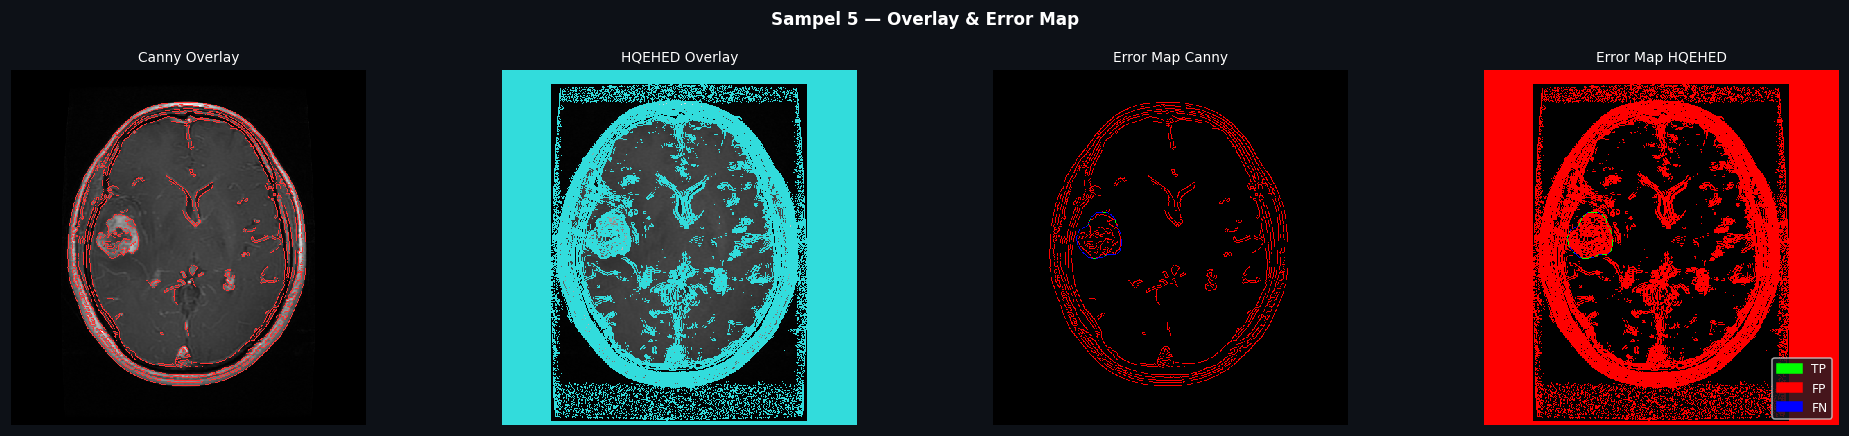

In [163]:
TP_COLOR = np.array([0,   255, 0  ], dtype=np.uint8)
FP_COLOR = np.array([255, 0,   0  ], dtype=np.uint8)
FN_COLOR = np.array([0,   0,   255], dtype=np.uint8)

def make_error_map(edge_det, edge_gt):
    H, W = edge_det.shape
    rgb  = np.zeros((H, W, 3), dtype=np.uint8)
    rgb[(edge_det==1)&(edge_gt==1)] = TP_COLOR
    rgb[(edge_det==1)&(edge_gt==0)] = FP_COLOR
    rgb[(edge_det==0)&(edge_gt==1)] = FN_COLOR
    return rgb

for i, r in enumerate(results_quick):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.patch.set_facecolor("#0d1117")

    img_u8  = (r["img_raw"] * 255).astype(np.uint8)
    img_rgb = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2RGB)

    ov_canny = img_rgb.copy(); ov_canny[r["edge_canny"]  == 1] = [255, 50,  50 ]
    ov_hq    = img_rgb.copy(); ov_hq   [r["edge_hqehed"] == 1] = [50,  220, 220]

    panels = [
        (ov_canny,                                       "Canny Overlay"),
        (ov_hq,                                          "HQEHED Overlay"),
        (make_error_map(r["edge_canny"],  r["gt_edge"]), "Error Map Canny"),
        (make_error_map(r["edge_hqehed"], r["gt_edge"]), "Error Map HQEHED"),
    ]
    for ax, (im, title) in zip(axes, panels):
        ax.imshow(im, interpolation="nearest")
        ax.set_title(title, color="white", fontsize=9); ax.axis("off")

    legend_patches = [
        mpatches.Patch(color=(0,1,0), label="TP"),
        mpatches.Patch(color=(1,0,0), label="FP"),
        mpatches.Patch(color=(0,0,1), label="FN"),
    ]
    axes[-1].legend(handles=legend_patches, loc="lower right",
                    fontsize=8, facecolor="#161b22", labelcolor="white")
    fig.suptitle(f"Sampel {i+1} — Overlay & Error Map",
                 color="white", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, f"error_map_{i+1}.png"),
                dpi=100, bbox_inches="tight", facecolor="#0d1117")
    plt.show(); plt.close()

## Cell 10 — Grid Search Otomatis

Variasikan  dan  secara sistematis pada subset kecil dataset.
Kriteria seleksi: **PSNR tertinggi**
(dihitung setelah  jika ) (sesuai paper Sec. 3.4 & Fig. 6).
MSE dan PSNR dihitung antara citra grayscale sumber dan edge-detected image (Pers. 2.18–2.19).

> Estimasi waktu: **2–10 menit** tergantung  dan ukuran grid.


In [164]:
# ══════════════════════════════════════════════════════
# KONFIGURASI GRID SEARCH
# ══════════════════════════════════════════════════════
SEARCH_GRID = {
    "gamma":     [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.95],
    "crop_size": [16, 32, 64, 128, 512],
}
GS_FIXED = {
    "gamma_neg":   0.95,
    "gauss_ksize": 3,
    "gauss_sigma": 0.5,
}
GS_MAX_IMAGES = 10    # pakai subset kecil agar cepat
# ══════════════════════════════════════════════════════

if not pairs:
    print("Dataset belum dimuat. Jalankan Cell 5 terlebih dahulu.")
else:
    gs_pairs      = pairs[:GS_MAX_IMAGES]
    param_keys    = list(SEARCH_GRID.keys())
    combinations  = list(itertools.product(*[SEARCH_GRID[k] for k in param_keys]))
    print(f"Grid Search: {len(combinations)} kombinasi × {len(gs_pairs)} citra")

    gs_results = []
    for combo in tqdm(combinations, desc="Grid Search"):
        params = dict(zip(param_keys, combo))
        g      = params.get("gamma",     GS_FIXED["gamma_neg"])
        g_neg  = GS_FIXED["gamma_neg"]
        c_size = params.get("crop_size", 32)
        ksize  = GS_FIXED["gauss_ksize"]
        sigma  = GS_FIXED["gauss_sigma"]

        mses, psnrs = [], []
        for img_path, mask_path in gs_pairs:
            img_raw, gt_mask = load_image_mask(img_path, mask_path, cfg.IMG_SIZE)
            img_pre          = preprocess(img_raw, ksize, sigma)
            edge_hq          = hqehed_amt(img_pre, c_size, g, g_neg)

            # MSE & PSNR antara citra sumber dan edge-detected image (Pers. 2.18–2.19)
            # img_pre sudah ternormalisasi [0,1]; edge_hq binary {0,1} — keduanya satu skala.
            # PSNR tetap pakai R=255 sesuai paper (Pers. 2.19), MSE dihitung pada skala [0,1].
            src  = img_pre.astype(np.float64)   # citra grayscale [0, 1]
            edg  = edge_hq.astype(np.float64)   # edge map {0, 1}
            mse_val  = float(np.mean((src - edg) ** 2))
            psnr_val = float(10.0 * np.log10(255.0 ** 2 / mse_val))                        if mse_val > 0 else 100.0        # PSNR ~ 100 dB bila MSE=0

            mses.append(mse_val)
            psnrs.append(psnr_val)

        mean_mse  = float(np.mean(mses))
        mean_psnr = float(np.mean(psnrs))
        gs_results.append({**params,
                           "mean_mse":  mean_mse,
                           "mean_psnr": mean_psnr,
                           "score":     mean_psnr})   # skor = PSNR (makin tinggi makin baik)

    gs_results.sort(key=lambda x: x["score"], reverse=True)
    best = gs_results[0]

    print(f"\nTop-5 konfigurasi (PSNR \u2191, MSE \u2193):")
    print(f"  {'gamma':>6}  {'crop':>5}  {'PSNR (dB)':>10}  {'MSE':>8}")
    print(f"  {'─'*40}")
    for r in gs_results[:5]:
        print(f"  {r['gamma']:6.2f}  {r['crop_size']:5d}  "
              f"{r['mean_psnr']:10.4f}  {r['mean_mse']:8.4f}")
    print(f"\nParameter terbaik: gamma={best['gamma']}  "
          f"crop_size={best['crop_size']}  ")
    print(f"  PSNR={best['mean_psnr']:.4f} dB  MSE={best['mean_mse']:.4f}")
    print("  → Salin ke Cell 6 untuk visualisasi lebih lanjut.")


Grid Search: 45 kombinasi × 10 citra


Grid Search: 100%|██████████| 45/45 [2:38:57<00:00, 211.95s/it]  


Top-5 konfigurasi (PSNR ↑, MSE ↓):
   gamma   crop   PSNR (dB)       MSE
  ────────────────────────────────────────
    0.95    512     51.1175    0.5028
    0.80    512     51.0455    0.5112
    0.70    512     50.9830    0.5186
    0.60    512     50.9030    0.5283
    0.50    512     50.7929    0.5418

Parameter terbaik: gamma=0.95  crop_size=512  
  PSNR=51.1175 dB  MSE=0.5028
  → Salin ke Cell 6 untuk visualisasi lebih lanjut.


## Cell 11 — Visualisasi Grid Search

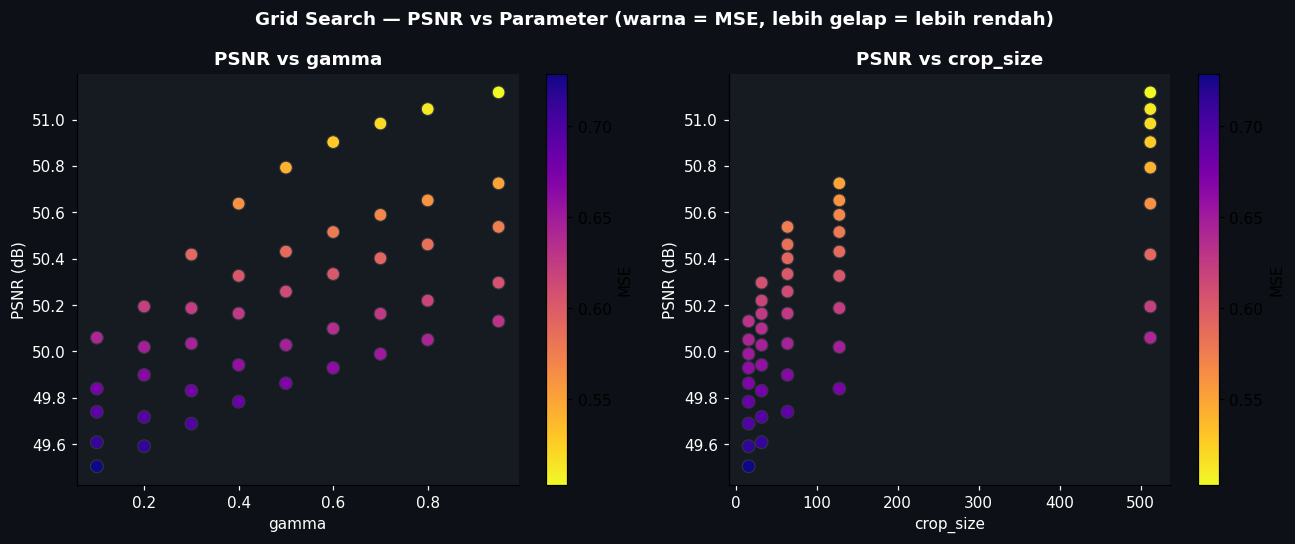

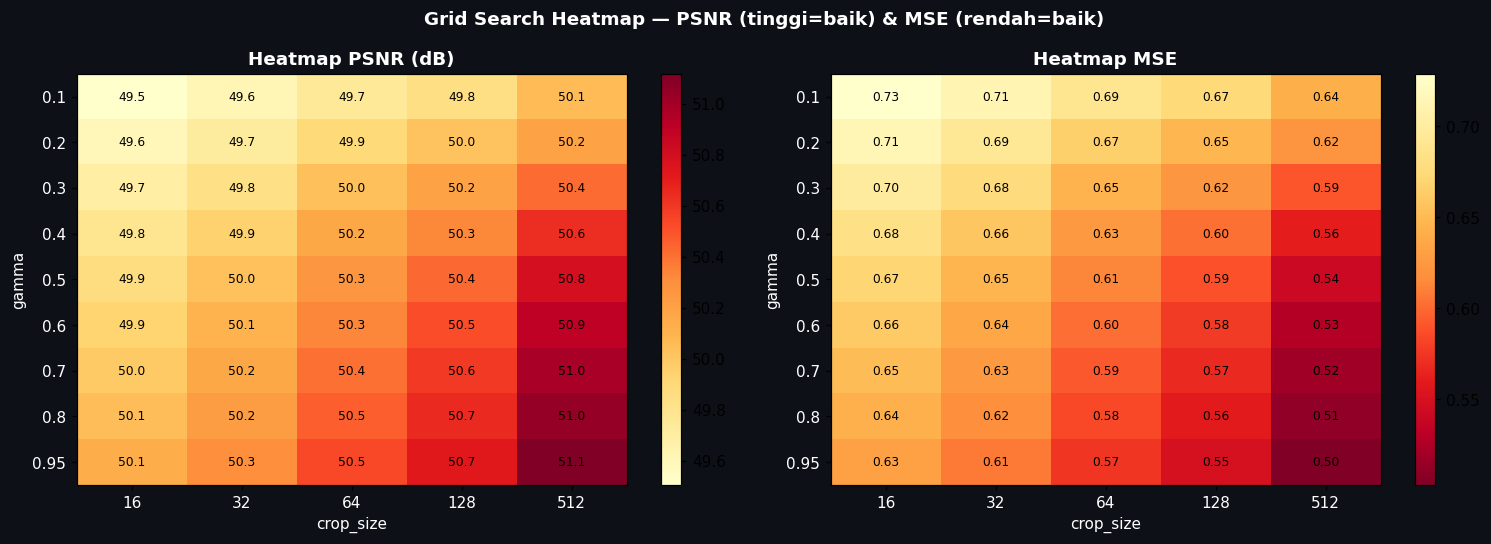

In [165]:
if "gs_results" not in dir() or not gs_results:
    print("Jalankan Grid Search (Cell 10) terlebih dahulu.")
else:
    param_keys = [k for k in gs_results[0] if k not in ("mean_mse", "mean_psnr", "score")]

    # ── Scatter per parameter (PSNR vs parameter, warna = MSE) ───
    fig, axes = plt.subplots(1, len(param_keys),
                             figsize=(6*len(param_keys), 5))
    fig.patch.set_facecolor("#0d1117")
    if len(param_keys) == 1: axes = [axes]

    for ax, key in zip(axes, param_keys):
        ax.set_facecolor("#161b22")
        xs    = [r[key]          for r in gs_results]
        psnrs = [r["mean_psnr"]  for r in gs_results]
        mses  = [r["mean_mse"]   for r in gs_results]
        sc    = ax.scatter(xs, psnrs, c=mses, cmap="plasma_r",
                           s=70, edgecolors="#30363d", linewidths=0.7)
        plt.colorbar(sc, ax=ax, label="MSE")
        ax.set_xlabel(key, color="white")
        ax.set_ylabel("PSNR (dB)", color="white")
        ax.set_title(f"PSNR vs {key}", color="white", fontweight="bold")
        ax.tick_params(colors="white")
        for sp in ["top", "right"]: ax.spines[sp].set_visible(False)

    plt.suptitle("Grid Search — PSNR vs Parameter (warna = MSE, lebih gelap = lebih rendah)",
                 color="white", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, "gs_scatter.png"),
                dpi=100, bbox_inches="tight", facecolor="#0d1117")
    plt.show(); plt.close()

    # ── Heatmap (hanya jika tepat 2 parameter) ────────────────────
    if len(param_keys) == 2:
        p1_vals  = sorted(set(r[param_keys[0]] for r in gs_results))
        p2_vals  = sorted(set(r[param_keys[1]] for r in gs_results))
        psnr_mat = np.zeros((len(p1_vals), len(p2_vals)))
        mse_mat  = np.zeros_like(psnr_mat)
        for r in gs_results:
            i = p1_vals.index(r[param_keys[0]])
            j = p2_vals.index(r[param_keys[1]])
            psnr_mat[i, j] = r["mean_psnr"]
            mse_mat[i, j]  = r["mean_mse"]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.patch.set_facecolor("#0d1117")
        for ax, mat, title, cmap in zip(
                axes,
                [psnr_mat, mse_mat],
                ["PSNR (dB)", "MSE"],
                ["YlOrRd", "YlOrRd_r"]):
            ax.set_facecolor("#161b22")
            im = ax.imshow(mat, cmap=cmap, aspect="auto")
            plt.colorbar(im, ax=ax)
            ax.set_xticks(range(len(p2_vals)))
            ax.set_xticklabels(p2_vals, color="white")
            ax.set_yticks(range(len(p1_vals)))
            ax.set_yticklabels(p1_vals, color="white")
            ax.set_xlabel(param_keys[1], color="white")
            ax.set_ylabel(param_keys[0], color="white")
            ax.set_title(f"Heatmap {title}", color="white", fontweight="bold")
            fmt = ".2f" if title == "MSE" else ".1f"
            for i in range(len(p1_vals)):
                for j in range(len(p2_vals)):
                    ax.text(j, i, f"{mat[i,j]:{fmt}}",
                            ha="center", va="center",
                            color="black", fontsize=8)
        plt.suptitle("Grid Search Heatmap — PSNR (tinggi=baik) & MSE (rendah=baik)",
                     color="white", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.savefig(os.path.join(cfg.OUTPUT_DIR, "gs_heatmap.png"),
                    dpi=100, bbox_inches="tight", facecolor="#0d1117")
        plt.show(); plt.close()


---
---

# BAGIAN 2 — PSO-SVM SEGMENTATION

> **Prasyarat:** Selesaikan Bagian 1 (Cell 1–11) dan pilih parameter edge terbaik
> dari hasil Grid Search atau Quick-Viz.
>
> **Langkah:**
> 1. Catat `gamma`, `gamma_neg`, `crop_size` terbaik dari Cell 10
> 2. Set `BEST_GAMMA`, `BEST_GAMMA_NEG`, `BEST_CROP_SIZE` di Cell 12
> 3. Jalankan Cell 12 → 14 secara berurutan

---


## Cell 12 — Full Evaluation: HQEHED-AMT + PSO-SVM

Pipeline lengkap:
1. Pra-pemrosesan + HQEHED-AMT → edge map
2. Ekstraksi fitur 5-dim per piksel
3. Split data 60% train | 20% val | 20% test
4. PSO optimasi (C, γ) SVM-RBF
5. Training SVM & evaluasi metrik segmentasi


Parameter: GAMMA=0.95  GAMMA_NEG=0.95  CROP=512

  FASE 1 - PSO Tuning (10 gambar)


  PSO data:   0%|          | 0/10 [00:00<?, ?it/s]

  PSO data: 100%|██████████| 10/10 [05:54<00:00, 35.43s/it]



───────────────────────────────────────────────────────
  PSO: 20 partikel  |  50 iterasi
───────────────────────────────────────────────────────
  Iter  10/50  gbest Dice=0.8099  C=8.4318  γ=0.087320
  Iter  20/50  gbest Dice=0.8124  C=8.1772  γ=0.087551
  Iter  30/50  gbest Dice=0.8124  C=8.1772  γ=0.087551
  Iter  40/50  gbest Dice=0.8124  C=8.1772  γ=0.087551
  Iter  50/50  gbest Dice=0.8124  C=8.1772  γ=0.087551

  C* = 8.177168  |  g* = 0.087551

  Grid Search 6x6 (validasi PSO) ...
  Grid Search: C_gs=3.9811  gamma_gs=0.039811  Dice=0.8078
  PSO        : C*  =8.1772  gamma*  =0.087551  Dice=0.8124
  PSO lebih baik Grid Search (selisih 0.0046)


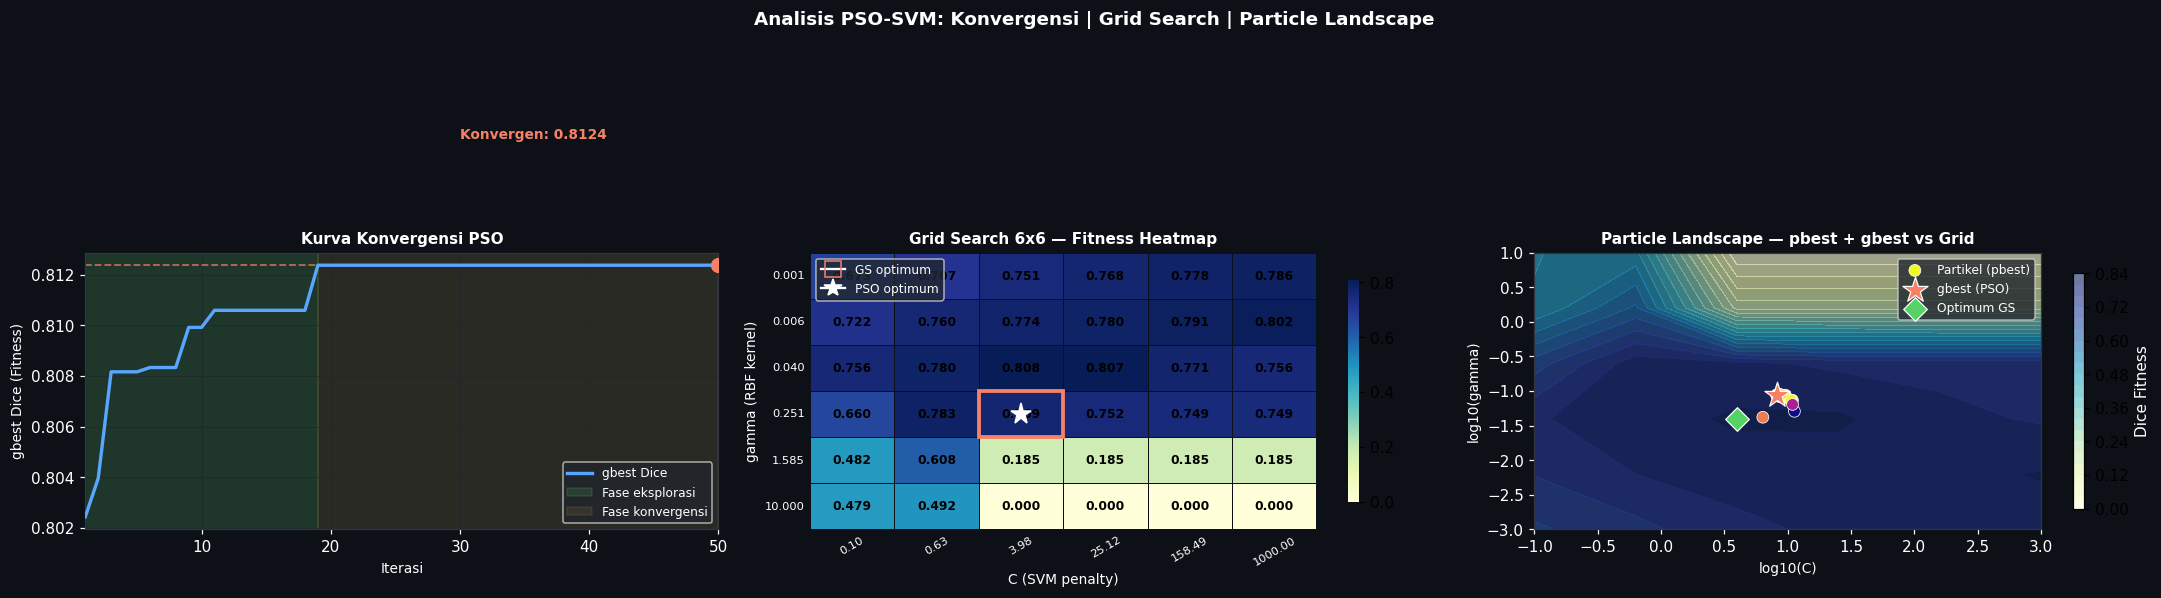

  Disimpan: ./results_paper1\eval_pso_analysis.png

  FASE 2 - Per-Image Evaluation (30 gambar)


  Per-image:  30%|███       | 9/30 [07:57<18:34, 53.09s/it]


KeyboardInterrupt: 

In [166]:
# Pipeline dua fase (sesuai paradigma per-image referensi):
#   FASE 1 - PSO sekali pada subset kecil  -> cari C* dan g* global
#   FASE 2 - Tiap gambar: split 70/30 sendiri, train SVM(C*,g*), evaluasi

BEST_GAMMA     = best['gamma']      if 'best' in dir() else GAMMA
BEST_GAMMA_NEG = GS_FIXED.get('gamma_neg', GAMMA_NEG) if 'GS_FIXED' in dir() else GAMMA_NEG
BEST_CROP_SIZE = best['crop_size']  if 'best' in dir() else CROP_SIZE

if not pairs:
    print('Dataset belum dimuat. Jalankan Cell 5 terlebih dahulu.')
else:
    print(f'Parameter: GAMMA={BEST_GAMMA}  GAMMA_NEG={BEST_GAMMA_NEG}  CROP={BEST_CROP_SIZE}')

    # ── FASE 1: PSO - cari C* dan g* (sekali, subset kecil) ──────
    PSO_SUBSET = min(10, len(pairs))
    print(f'\n{"="*55}')
    print(f'  FASE 1 - PSO Tuning ({PSO_SUBSET} gambar)')
    print(f'{"="*55}')
    pso_X, pso_y = [], []
    for img_path, mask_path in tqdm(pairs[:PSO_SUBSET], desc='  PSO data'):
        img_raw, mask = load_image_mask(img_path, mask_path, cfg.IMG_SIZE)
        img_pre       = preprocess(img_raw, GAUSS_KSIZE, GAUSS_SIGMA)
        edge_map      = hqehed_amt(img_pre, BEST_CROP_SIZE, BEST_GAMMA, BEST_GAMMA_NEG)
        X, y = extract_patch_features(img_pre, edge_map, mask, 300)
        if len(X) > 0:
            pso_X.append(X); pso_y.append(y)
    X_pso = np.vstack(pso_X); y_pso = np.concatenate(pso_y)
    X_pso_tr, X_pso_val, y_pso_tr, y_pso_val = train_test_split(
        X_pso, y_pso, test_size=0.3, random_state=42, stratify=y_pso)
    scaler_pso = StandardScaler()
    X_pso_tr   = scaler_pso.fit_transform(X_pso_tr)
    X_pso_val  = scaler_pso.transform(X_pso_val)
    optimizer  = PSO_SVM_Optimizer(X_pso_tr, y_pso_tr, X_pso_val, y_pso_val)
    C_opt, g_opt, pso_history = optimizer.optimize(verbose=True)
    print(f'\n  C* = {C_opt:.6f}  |  g* = {g_opt:.6f}')

    # ════════════════════════════════════════════════════════════
    # PSO ANALYSIS: Konvergensi + Grid Search Coarse + Landscape
    # ════════════════════════════════════════════════════════════
    import seaborn as _sns
    import pandas as _pd

    # ── Grid Search 6×6 untuk validasi PSO ───────────────────────
    _GS_N  = 6
    _C_log = np.linspace(*cfg.PSO_C_RANGE, _GS_N)
    _g_log = np.linspace(*cfg.PSO_G_RANGE, _GS_N)
    _gs_heat = np.zeros((_GS_N, _GS_N))
    print(f"\n  Grid Search {_GS_N}x{_GS_N} (validasi PSO) ...")
    for _ci, _cv in enumerate(_C_log):
        for _gi, _gv in enumerate(_g_log):
            _clf_gs = SVC(C=10.**_cv, gamma=10.**_gv,
                          kernel="rbf", class_weight="balanced")
            _clf_gs.fit(X_pso_tr, y_pso_tr)
            _pr = _clf_gs.predict(X_pso_val)
            _tp = np.sum((_pr==1)&(y_pso_val==1))
            _fp = np.sum((_pr==1)&(y_pso_val==0))
            _fn = np.sum((_pr==0)&(y_pso_val==1))
            _dn = 2*_tp+_fp+_fn
            _gs_heat[_gi, _ci] = (2*_tp/_dn) if _dn>0 else 0.0

    _best_gi, _best_ci = np.unravel_index(_gs_heat.argmax(), _gs_heat.shape)
    _C_gs  = 10.**_C_log[_best_ci]
    _g_gs  = 10.**_g_log[_best_gi]
    _fit_gs = _gs_heat[_best_gi, _best_ci]
    print(f"  Grid Search: C_gs={_C_gs:.4f}  gamma_gs={_g_gs:.6f}"
          f"  Dice={_fit_gs:.4f}")
    print(f"  PSO        : C*  ={C_opt:.4f}  gamma*  ={g_opt:.6f}"
          f"  Dice={pso_history[-1]:.4f}")
    _pso_wins = pso_history[-1] >= _fit_gs
    print(f"  PSO {'lebih baik' if _pso_wins else 'setara/sedikit di bawah'} "
          f"Grid Search (selisih {abs(pso_history[-1]-_fit_gs):.4f})")

    # ── Visualisasi 3-panel ───────────────────────────────────────
    fig_pso, axes_pso = plt.subplots(1, 3, figsize=(20, 5.5))
    fig_pso.patch.set_facecolor('#0d1117')
    fig_pso.suptitle(
        'Analisis PSO-SVM: Konvergensi | Grid Search | Particle Landscape',
        color='white', fontsize=12, fontweight='bold')

    # ── Panel 1: Kurva konvergensi ────────────────────────────────
    ax_cv = axes_pso[0]; ax_cv.set_facecolor('#161b22')
    _iters = np.arange(1, len(pso_history)+1)
    ax_cv.plot(_iters, pso_history, color='#58a6ff', linewidth=2.2,
               label='gbest Dice', zorder=3)
    # Shading area: iterasi sebelum plateau (peningkatan > 0.001)
    _deltas = np.diff([0.0]+list(pso_history))
    _last_improve = max((i for i,d in enumerate(_deltas) if d > 1e-4), default=0)
    ax_cv.axvspan(1, _last_improve+1, alpha=0.15, color='#56d364',
                  label='Fase eksplorasi')
    ax_cv.axvspan(_last_improve+1, len(pso_history), alpha=0.10,
                  color='#e3b341', label='Fase konvergensi')
    ax_cv.axhline(pso_history[-1], color='#f78166', linewidth=1.2,
                  linestyle='--', alpha=0.7)
    ax_cv.scatter([len(pso_history)], [pso_history[-1]], color='#f78166',
                  s=80, zorder=5)
    ax_cv.text(len(pso_history)*0.6, pso_history[-1]+0.005,
               f'Konvergen: {pso_history[-1]:.4f}',
               color='#f78166', fontsize=9, fontweight='bold')
    ax_cv.set_xlabel('Iterasi', color='white', fontsize=9)
    ax_cv.set_ylabel('gbest Dice (Fitness)', color='white', fontsize=9)
    ax_cv.set_title('Kurva Konvergensi PSO', color='white',
                    fontsize=10, fontweight='bold')
    ax_cv.tick_params(colors='white')
    ax_cv.spines[:].set_color('#30363d')
    ax_cv.legend(facecolor='#21262d', labelcolor='white', fontsize=8,
                 loc='lower right')
    ax_cv.grid(color='#21262d', linewidth=0.5)
    ax_cv.set_xlim(1, len(pso_history))

    # ── Panel 2: Grid Search Heatmap + PSO optimum ───────────────
    ax_gs = axes_pso[1]
    _df_gs = _pd.DataFrame(
        _gs_heat,
        index=[f'{10.**v:.3f}' for v in _g_log],
        columns=[f'{10.**v:.2f}' for v in _C_log])
    _sns.heatmap(_df_gs, ax=ax_gs, cmap='YlGnBu', annot=True, fmt='.3f',
                 linewidths=0.4, linecolor='#0d1117',
                 annot_kws={'size':8,'weight':'bold','color':'black'},
                 cbar_kws={'shrink':0.8})
    # Tandai optimum Grid Search (kotak merah)
    ax_gs.add_patch(plt.Rectangle((_best_ci, _GS_N-1-_best_gi), 1, 1,
                    fill=False, edgecolor='#f78166', linewidth=2.5, zorder=5))
    # Tandai posisi terdekat PSO (bintang putih)
    _pso_ci = int(np.argmin(np.abs(_C_log - np.log10(C_opt))))
    _pso_gi = int(np.argmin(np.abs(_g_log - np.log10(g_opt))))
    ax_gs.plot(_pso_ci+0.5, _GS_N-1-_pso_gi+0.5, '*', color='white',
               markersize=14, zorder=6, label='PSO optimum')
    ax_gs.set_title('Grid Search 6x6 — Fitness Heatmap', color='white',
                    fontsize=10, fontweight='bold')
    ax_gs.set_xlabel('C (SVM penalty)', color='white', fontsize=9)
    ax_gs.set_ylabel('gamma (RBF kernel)', color='white', fontsize=9)
    ax_gs.tick_params(colors='white', length=0)
    ax_gs.set_xticklabels(ax_gs.get_xticklabels(), color='white',
                           fontsize=7.5, rotation=30)
    ax_gs.set_yticklabels(ax_gs.get_yticklabels(), color='white',
                           fontsize=7.5, rotation=0)
    from matplotlib.lines import Line2D
    _lgnd_el = [Line2D([0],[0], marker='s', color='w', markerfacecolor='none',
                        markeredgecolor='#f78166', markersize=10,
                        label='GS optimum'),
                Line2D([0],[0], marker='*', color='w', markersize=12,
                        label='PSO optimum')]
    ax_gs.legend(handles=_lgnd_el, facecolor='#21262d', labelcolor='white',
                 fontsize=8, loc='upper left')

    # ── Panel 3: Particle Landscape (pbest positions) ─────────────
    ax_ls = axes_pso[2]; ax_ls.set_facecolor('#161b22')
    # Background: grid search Dice sebagai contourf
    _CG, _GG = np.meshgrid(_C_log, _g_log)
    _cf = ax_ls.contourf(_CG, _GG, _gs_heat, levels=20, cmap='YlGnBu', alpha=0.6)
    fig_pso.colorbar(_cf, ax=ax_ls, label='Dice Fitness',
                     shrink=0.85).ax.yaxis.label.set_color('white')
    # Scatter pbest partikel, warnai berdasarkan fitness
    _pbfit = optimizer.pbest_fit
    _sc = ax_ls.scatter(optimizer.pbest[:, 0], optimizer.pbest[:, 1],
                        c=_pbfit, cmap='plasma', s=60, zorder=4,
                        edgecolors='white', linewidths=0.5,
                        vmin=_pbfit.min(), vmax=_pbfit.max(),
                        label='Partikel (pbest)')
    # Global best
    ax_ls.scatter([optimizer.gbest[0]], [optimizer.gbest[1]],
                  marker='*', s=300, color='#f78166', zorder=6,
                  edgecolors='white', linewidths=0.8, label='gbest (PSO)')
    # Grid Search optimum
    ax_ls.scatter([_C_log[_best_ci]], [_g_log[_best_gi]],
                  marker='D', s=120, color='#56d364', zorder=5,
                  edgecolors='white', linewidths=0.8, label='Optimum GS')
    ax_ls.set_xlabel('log10(C)', color='white', fontsize=9)
    ax_ls.set_ylabel('log10(gamma)', color='white', fontsize=9)
    ax_ls.set_title('Particle Landscape — pbest + gbest vs Grid',
                    color='white', fontsize=10, fontweight='bold')
    ax_ls.tick_params(colors='white')
    ax_ls.spines[:].set_color('#30363d')
    ax_ls.legend(facecolor='#21262d', labelcolor='white', fontsize=8,
                 loc='upper right')

    plt.tight_layout()
    _pso_out = os.path.join(cfg.OUTPUT_DIR, 'eval_pso_analysis.png')
    plt.savefig(_pso_out, dpi=120, bbox_inches='tight', facecolor='#0d1117')
    plt.show(); plt.close()
    print(f"  Disimpan: {_pso_out}")

    # ── FASE 2: Per-Image Train + Evaluation ──────────────────────
    EVAL_N_TUMOR    = 1500   # max piksel tumor per gambar
    EVAL_N_NONTUMOR = 6000   # max piksel non-tumor per gambar (~1:4 ratio)
    print(f'\n{"="*55}')
    print(f'  FASE 2 - Per-Image Evaluation ({len(pairs)} gambar)')
    print(f'{"="*55}')
    per_image_results = []
    vis_samples       = []
    for img_path, mask_path in tqdm(pairs, desc='  Per-image'):
        img_raw, gt_mask = load_image_mask(img_path, mask_path, cfg.IMG_SIZE)
        img_pre          = preprocess(img_raw, GAUSS_KSIZE, GAUSS_SIGMA)
        edge_map         = hqehed_amt(img_pre, BEST_CROP_SIZE, BEST_GAMMA, BEST_GAMMA_NEG)
        fm         = _build_feature_maps(img_pre, edge_map)
        tumor_c    = list(zip(*np.where(gt_mask == 1)))
        nontumor_c = list(zip(*np.where(gt_mask == 0)))
        n_t  = min(EVAL_N_TUMOR,    len(tumor_c))
        n_nt = min(EVAL_N_NONTUMOR, len(nontumor_c))
        if n_t == 0:
            continue
        sampled = random.sample(tumor_c, n_t) + random.sample(nontumor_c, n_nt)
        labels  = [1]*n_t + [0]*n_nt
        X_img   = np.array([_feat_vec(fm, y, x) for (y, x) in sampled], dtype=np.float32)
        y_img   = np.array(labels, dtype=np.int32)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_img, y_img, test_size=0.3, random_state=42, stratify=y_img)
        scaler_i = StandardScaler()
        X_tr_s   = scaler_i.fit_transform(X_tr)
        X_te_s   = scaler_i.transform(X_te)
        svm_i = SVC(C=C_opt, gamma=g_opt, kernel=cfg.SVM_KERNEL, class_weight=cfg.SVM_CLASS_WEIGHT)
        svm_i.fit(X_tr_s, y_tr)
        y_pred = svm_i.predict(X_te_s)
        tp = np.sum((y_pred==1)&(y_te==1)); tn = np.sum((y_pred==0)&(y_te==0))
        fp = np.sum((y_pred==1)&(y_te==0)); fn = np.sum((y_pred==0)&(y_te==1))
        seg_m = {
            'Accuracy':    float((tp+tn)/(tp+tn+fp+fn+1e-8)),
            'Sensitivity': float(tp/(tp+fn+1e-8)),
            'Specificity': float(tn/(tn+fp+1e-8)),
            'Dice':        float(2*tp/(2*tp+fp+fn+1e-8)),
            'IoU':         float(tp/(tp+fp+fn+1e-8)),
        }
        gt_edge_ = cv2.Canny((gt_mask*255).astype(np.uint8), 50, 150) // 255
        fom_val  = figure_of_merit(edge_map, gt_edge_)
        per_image_results.append({'metrics': seg_m, 'fom': fom_val})
        if len(vis_samples) < 3:
            edge_canny_v = cv2.Canny((img_pre * 255).astype(np.uint8), 50, 150) // 255
            fm_c     = _build_feature_maps(img_pre, edge_canny_v)
            X_c      = np.array([_feat_vec(fm_c, y, x) for (y, x) in sampled],
                                dtype=np.float32)
            X_tr_c, _, y_tr_c, _ = train_test_split(
                X_c, y_img, test_size=0.3, random_state=42, stratify=y_img)
            scaler_c = StandardScaler()
            X_tr_cs  = scaler_c.fit_transform(X_tr_c)
            svm_c    = SVC(C=C_opt, gamma=g_opt, kernel=cfg.SVM_KERNEL,
                          class_weight=cfg.SVM_CLASS_WEIGHT)
            svm_c.fit(X_tr_cs, y_tr_c)
            vis_samples.append({
                'img_raw': img_raw, 'gt_mask': gt_mask,
                'edge_map': edge_map, 'img_pre': img_pre,
                'svm': svm_i, 'scaler': scaler_i,
                'edge_canny': edge_canny_v,
                'svm_canny': svm_c, 'scaler_canny': scaler_c,
                'metrics': seg_m, 'fom': fom_val,
            })

    avg = {k: float(np.mean([r['metrics'][k] for r in per_image_results]))
           for k in per_image_results[0]['metrics']}
    avg_fom = float(np.mean([r['fom'] for r in per_image_results]))
    print(f'\n  Metrik rata-rata ({len(per_image_results)} gambar):')
    for k, v in avg.items():
        print(f'    {k:<15} {v:.4f}')
    print(f'    {"FOM":<15} {avg_fom:.4f}')


## Cell 13 — Visualisasi PSO-SVM

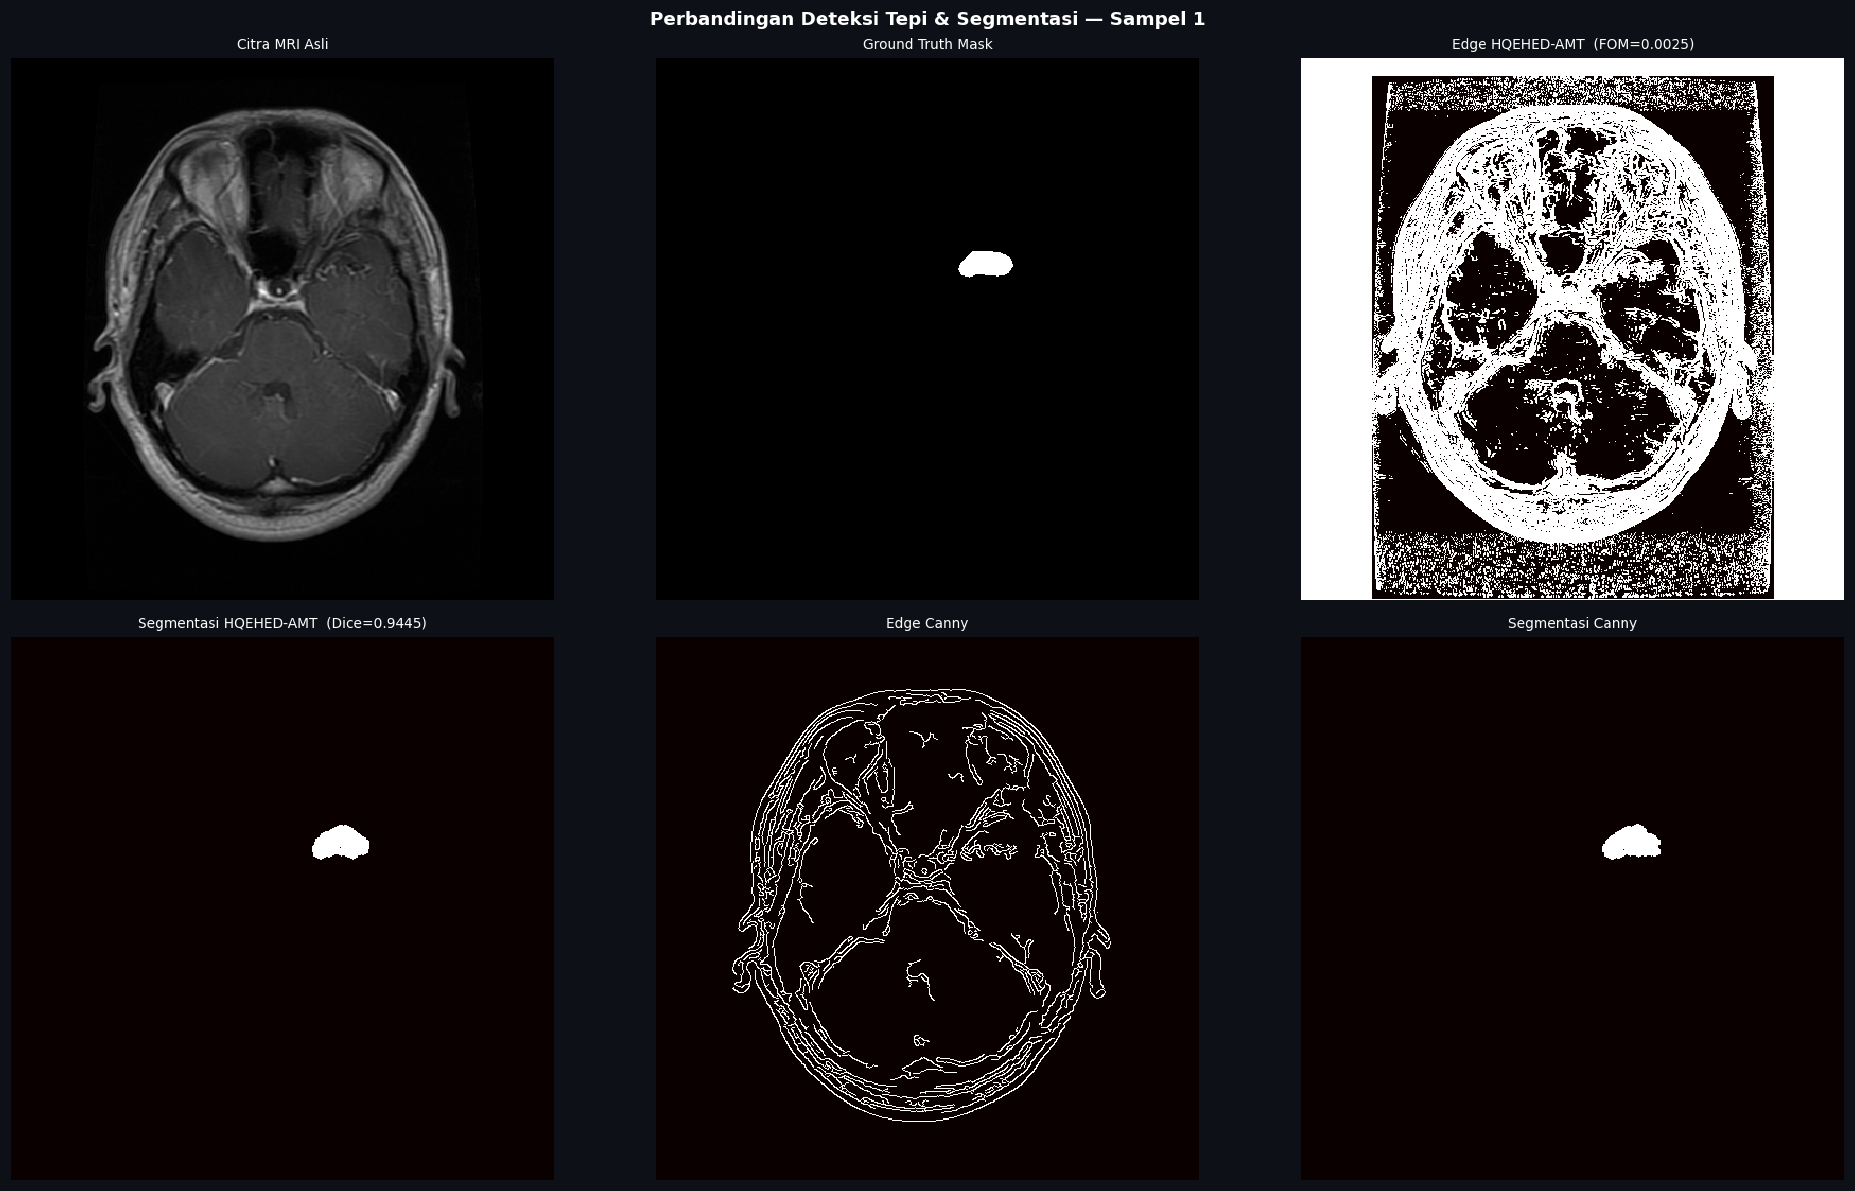

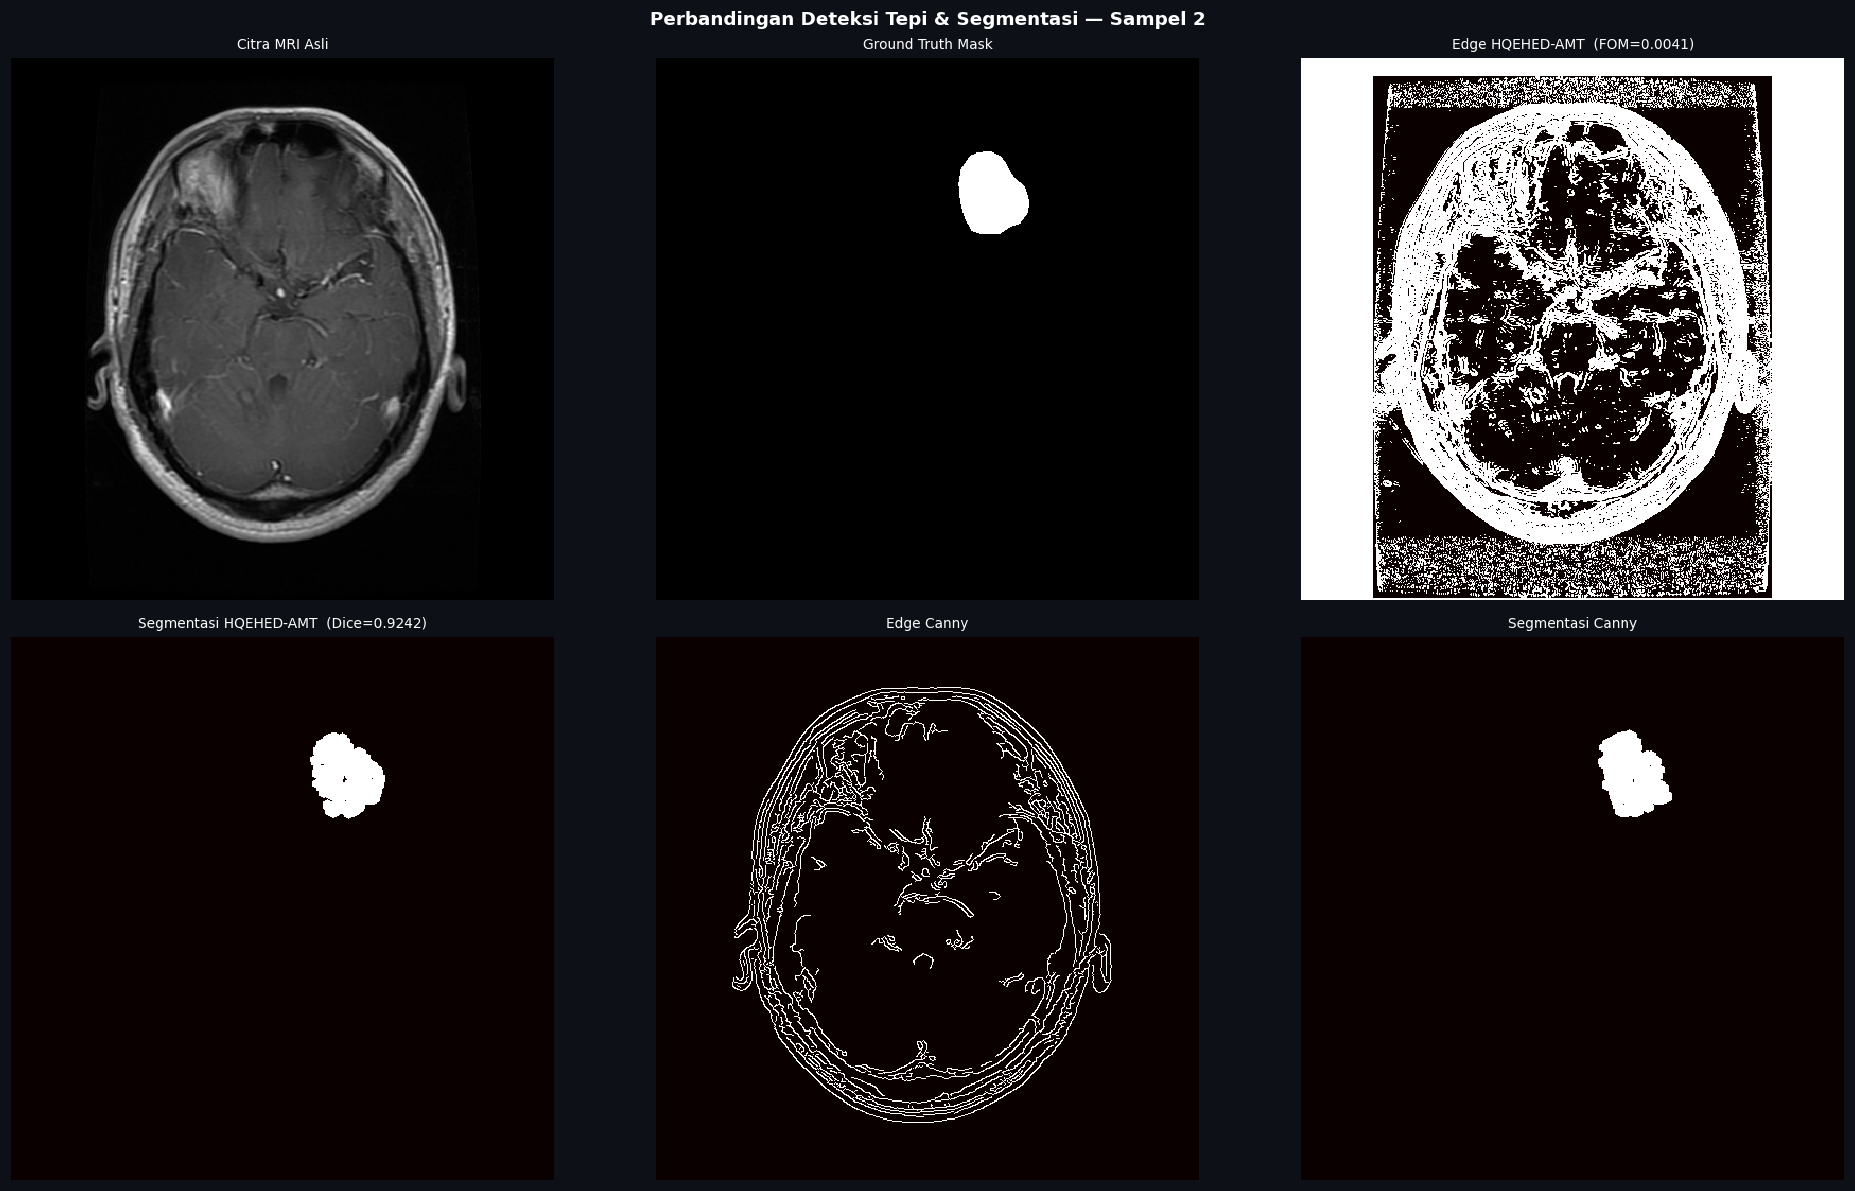

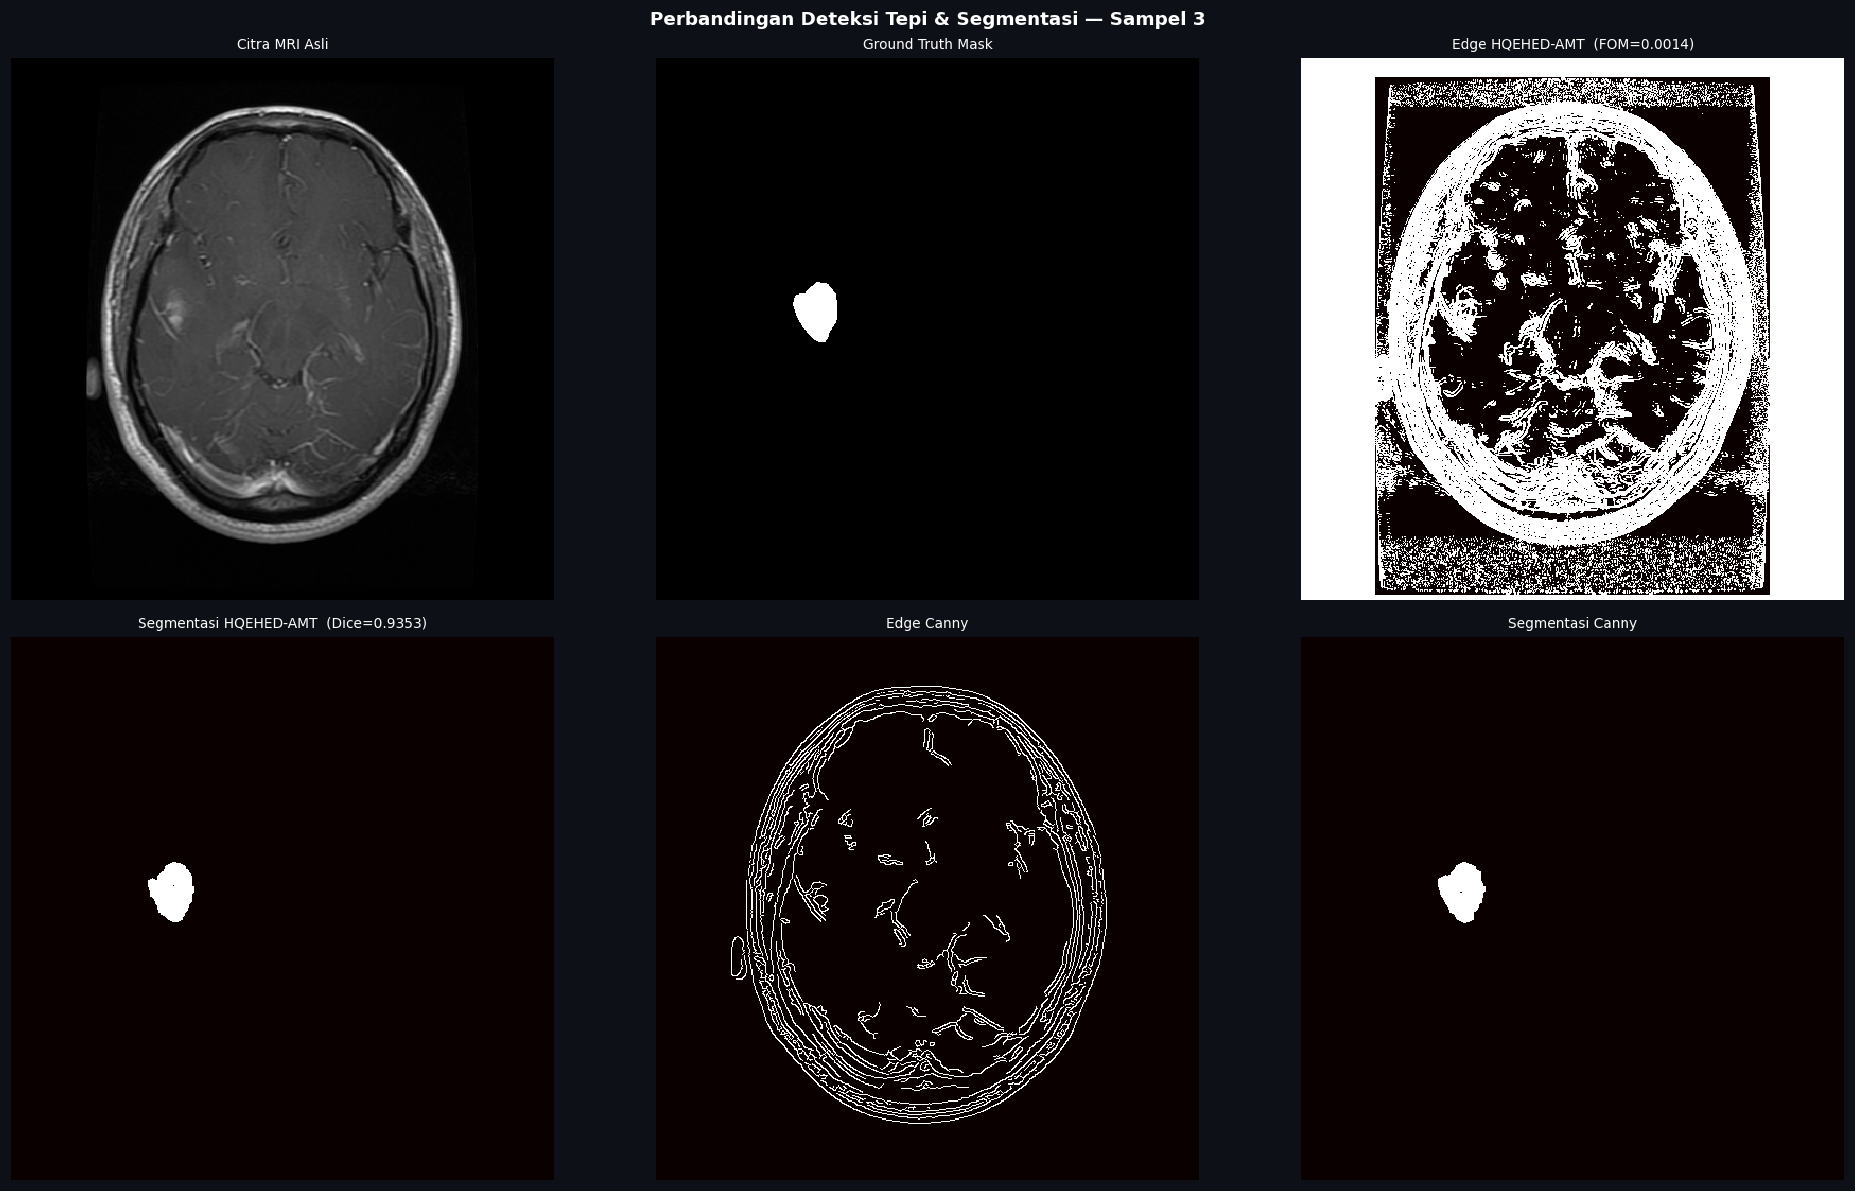

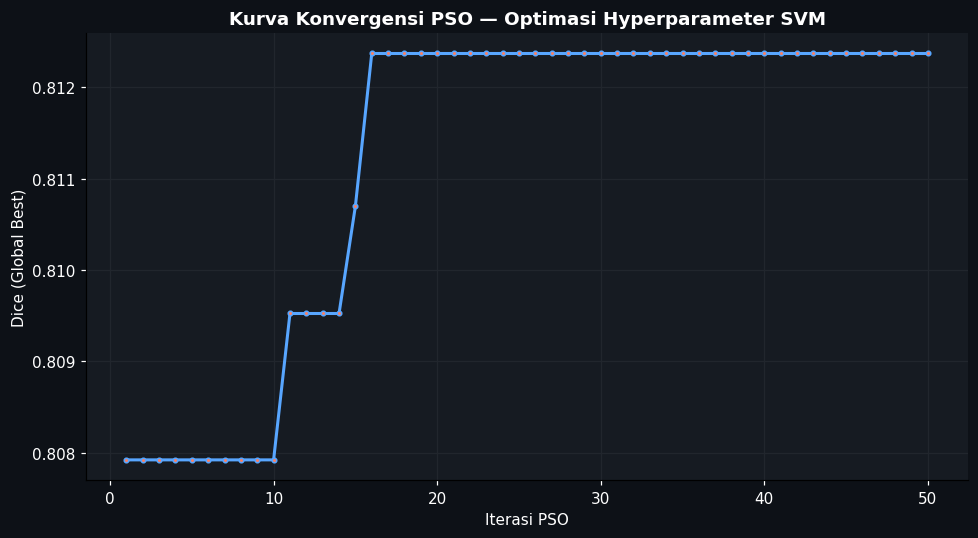

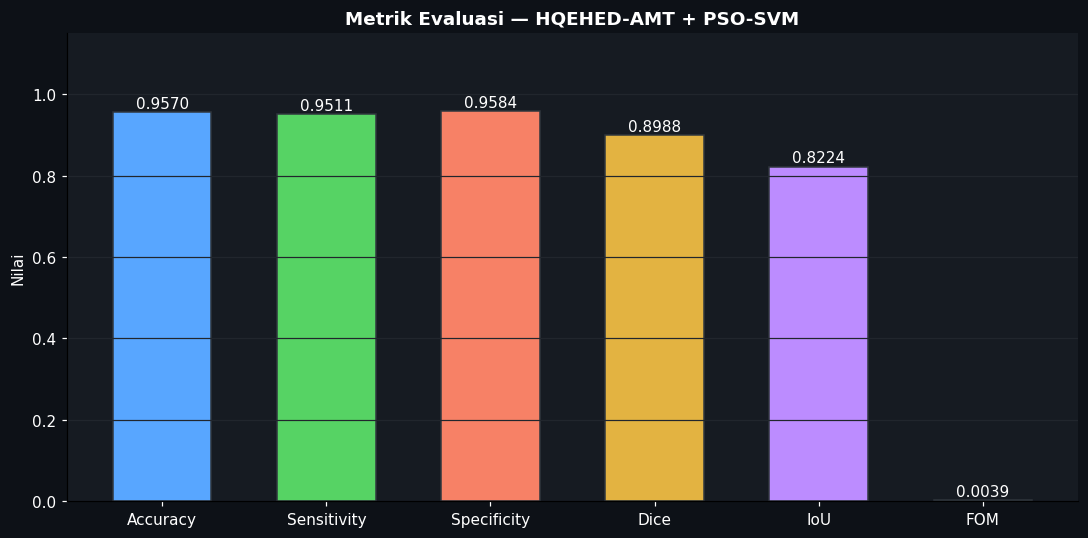

Gambar tersimpan di: ./results_paper1/


In [ ]:
if 'vis_samples' not in dir() or not vis_samples:
    print('Jalankan Cell 12 terlebih dahulu.')
else:
    from skimage.measure import label as sk_label
    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

    def _clean_mask(pred_raw):
        """Morphological open + connected-component filtering."""
        kernel_cc   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        pred_opened = cv2.morphologyEx(pred_raw.astype(np.uint8),
                                       cv2.MORPH_OPEN, kernel_cc, iterations=2)
        labeled_m, n_blobs = sk_label(pred_opened, return_num=True)
        blobs = sorted([(np.sum(labeled_m == j), j)
                        for j in range(1, n_blobs + 1)], reverse=True)
        pred_clean = np.zeros_like(pred_raw)
        for sz, blob_idx in blobs[:cfg.CC_MAX_BLOBS]:
            if sz >= cfg.CC_MIN_SIZE:
                pred_clean[labeled_m == blob_idx] = 1
        return pred_clean

    for i, s in enumerate(vis_samples):
        # ── Prediksi segmentasi penuh ─────────────────────────────
        pred_hq = _clean_mask(
            _predict_full_image(s['img_pre'], s['edge_map'],
                                s['svm'], s['scaler']))
        pred_cn = _clean_mask(
            _predict_full_image(s['img_pre'], s['edge_canny'],
                                s['svm_canny'], s['scaler_canny']))

        # ── 6-panel grid (2 baris × 3 kolom) ─────────────────────
        fig, axes = plt.subplots(2, 3, figsize=(18, 11))
        fig.patch.set_facecolor('#0d1117')

        panels = [
            (s['img_raw'],    'Citra MRI Asli',                            'gray'),
            (s['gt_mask'],    'Ground Truth Mask',                         'gray'),
            (s['edge_map'],   f'Edge HQEHED-AMT  (FOM={s["fom"]:.4f})',   'hot'),
            (pred_hq,         f'Segmentasi HQEHED-AMT  (Dice={s["metrics"]["Dice"]:.4f})', 'hot'),
            (s['edge_canny'], 'Edge Canny',                                'hot'),
            (pred_cn,         'Segmentasi Canny',                          'hot'),
        ]
        for ax, (im, title, cmap) in zip(axes.flat, panels):
            ax.imshow(im, cmap=cmap, interpolation='nearest')
            ax.set_title(title, color='white', fontsize=9, pad=6)
            ax.axis('off')

        fig.suptitle(
            f'Perbandingan Deteksi Tepi & Segmentasi — Sampel {i + 1}',
            color='white', fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        plt.savefig(
            os.path.join(cfg.OUTPUT_DIR, f'hasil_segmentasi_{i + 1}.png'),
            dpi=100, bbox_inches='tight', facecolor='#0d1117'
        )
        plt.show()
        plt.close()

    plot_pso_convergence(pso_history,
                         save_path=os.path.join(cfg.OUTPUT_DIR, 'konvergensi_pso.png'))
    avg_m       = {k: float(np.mean([r['metrics'][k] for r in per_image_results]))
                   for k in per_image_results[0]['metrics']}
    avg_fom_all = float(np.mean([r['fom'] for r in per_image_results]))
    plot_metrics_bar(avg_m, avg_fom_all,
                     save_path=os.path.join(cfg.OUTPUT_DIR, 'metrik_evaluasi.png'))
    print(f'Gambar tersimpan di: {cfg.OUTPUT_DIR}/')


## Cell 14 — Log Eksperimen (Manual)

Isi setelah setiap percobaan selesai.

In [ ]:
# ── Export hasil ke Excel (append per eksperimen) ────────────────────
# Jalankan setelah Cell 8 (Panel Viz). pip install openpyxl jika belum.

try:
    import openpyxl
    from openpyxl.drawing.image import Image as XLImage
    from openpyxl.styles import Font, PatternFill, Alignment
except ImportError:
    raise ImportError("Jalankan: pip install openpyxl")

if not results_quick:
    print("Jalankan Cell 7 (Quick-Viz) terlebih dahulu.")
else:
    HEADERS = [
        "Run", "Sample", "gamma", "gamma_neg", "crop_size",
        "gauss_ksize", "gauss_sigma",
        "PSNR_canny",        "MSE_canny",        "FOM_canny",
        "PSNR_hqehed_raw",   "MSE_hqehed_raw",   "FOM_hqehed_raw",
        "PSNR_hqehed",       "MSE_hqehed",       "FOM_hqehed",
        "Panel Image"
    ]
    out_path = os.path.join(cfg.OUTPUT_DIR, "results_log.xlsx")

    # Load file lama atau buat baru
    if os.path.exists(out_path):
        wb = openpyxl.load_workbook(out_path)
        ws = wb.active
        next_run = max(
            (ws.cell(r, 1).value or 0)
            for r in range(2, ws.max_row + 1)
            if isinstance(ws.cell(r, 1).value, int)
        ) + 1 if ws.max_row > 1 else 1
    else:
        wb = openpyxl.Workbook()
        ws = wb.active
        ws.title = "HQEHED Results"
        hdr_fill = PatternFill("solid", fgColor="1F4E79")
        hdr_font = Font(color="FFFFFF", bold=True)
        for col, h in enumerate(HEADERS, 1):
            c = ws.cell(row=1, column=col, value=h)
            c.fill = hdr_fill; c.font = hdr_font
            c.alignment = Alignment(horizontal="center")
        next_run = 1

    start_row = ws.max_row + 1
    for i, r in enumerate(results_quick):
        row = start_row + i
        ws.row_dimensions[row].height = 90
        for col, v in enumerate([
            next_run, i+1, GAMMA, GAMMA_NEG, CROP_SIZE,
            GAUSS_KSIZE, GAUSS_SIGMA,
            round(r["psnr_canny"],4),       round(r["mse_canny"],6),       round(r["fom_canny"],4),
            round(r["psnr_hqehed_raw"],4),  round(r["mse_hqehed_raw"],6),  round(r["fom_hqehed_raw"],4),
            round(r["psnr_hqehed"],4),      round(r["mse_hqehed"],6),      round(r["fom_hqehed"],4),
        ], 1):
            ws.cell(row=row, column=col, value=v)

        img_path = os.path.join(cfg.OUTPUT_DIR, f"panel_{i+1}.png")
        if os.path.exists(img_path):
            xl_img = XLImage(img_path)
            xl_img.width = 500; xl_img.height = 85
            col_letter = openpyxl.utils.get_column_letter(len(HEADERS))
            ws.add_image(xl_img, f"{col_letter}{row}")

    for col in range(1, len(HEADERS)):
        ws.column_dimensions[openpyxl.utils.get_column_letter(col)].width = 18
    ws.column_dimensions[openpyxl.utils.get_column_letter(len(HEADERS))].width = 75

    # Simpan — jika file sedang terbuka di Excel, coba nama alternatif
    try:
        wb.save(out_path)
    except PermissionError:
        import time
        out_path = out_path.replace(".xlsx", f"_{int(time.time())}.xlsx")
        wb.save(out_path)
        print("[INFO] File lama terbuka di Excel — disimpan ke nama baru.")
    print(f"Excel disimpan: {out_path}")
    print(f"  Run #{next_run} — {len(results_quick)} sampel ditambahkan")
    print(f"  Total baris data: {ws.max_row - 1}")



Excel disimpan: ./results_paper1\results_log.xlsx
  Run #9 — 5 sampel ditambahkan
  Total baris data: 45


---
---

# BAGIAN 3 — EVALUASI KOMPARATIF

> **Prasyarat:** Selesaikan Bagian 1 (Cell 1–11) dan Bagian 2 (Cell 12) sebelum menjalankan cell ini.

Evaluasi dua tahap secara terpisah, dibandingkan per metode deteksi tepi, dan dipecah per kelas tumor.

---

## Struktur Evaluasi

| Tahap | Metrik | Keterangan |
|-------|--------|-----------|
| **Deteksi Tepi** | FOM (Pratt's) | Kualitas tepi vs ground-truth tumor boundary |
| **Segmentasi** | Confusion Matrix, Dice, IoU, Accuracy, Sensitivity, Specificity | Kualitas segmentasi tumor vs GT mask |

## Metode yang Dibandingkan

| Metode | Deskripsi |
|--------|-----------|
| **Canny** | Deteksi tepi klasik (low=50, high=150) |
| **HQEHED-AMT** | Deteksi tepi kuantum (parameter dari Cell 6/12) |

## Kelas Tumor

`glioma` · `meningioma` · `pituitary`

Dataset dimuat ulang: 3064 total gambar
Distribusi per kelas:
  glioma: 1426 tersedia, 15 akan dievaluasi
  meningioma: 708 tersedia, 15 akan dievaluasi
  pituitary: 930 tersedia, 15 akan dievaluasi

Evaluasi kelas [GLIOMA] (15 gambar) ...


  glioma: 100%|██████████| 15/15 [02:16<00:00,  9.13s/it]



Evaluasi kelas [MENINGIOMA] (15 gambar) ...


  meningioma: 100%|██████████| 15/15 [02:08<00:00,  8.58s/it]



Evaluasi kelas [PITUITARY] (15 gambar) ...


  pituitary: 100%|██████████| 15/15 [02:20<00:00,  9.37s/it]



  HASIL EVALUASI KOMPARATIF

  ┌── GLIOMA ────────────────────────────────────────────────────
  │  Metrik                         Canny           Sobel         Prewitt             LoG      HQEHED-AMT
  │  ────────────────────────────────────────────────────────────────────────────────────────────────────
  │  [Deteksi Tepi]
  │  FOM (Pratt's)                 0.0083          0.0072          0.0072          0.0070          0.0036
  │  [Segmentasi]
  │  Accuracy                      0.9640          0.9611          0.9612          0.9557          0.9649
  │  Sensitivity                   0.9613          0.9620          0.9650          0.9540          0.9624
  │  Specificity                   0.9647          0.9609          0.9604          0.9562          0.9655
  │  Dice                          0.9157          0.9110          0.9105          0.8986          0.9175
  │  IoU                           0.8510          0.8447          0.8434          0.8262          0.8543
  │  [Confusion Ma

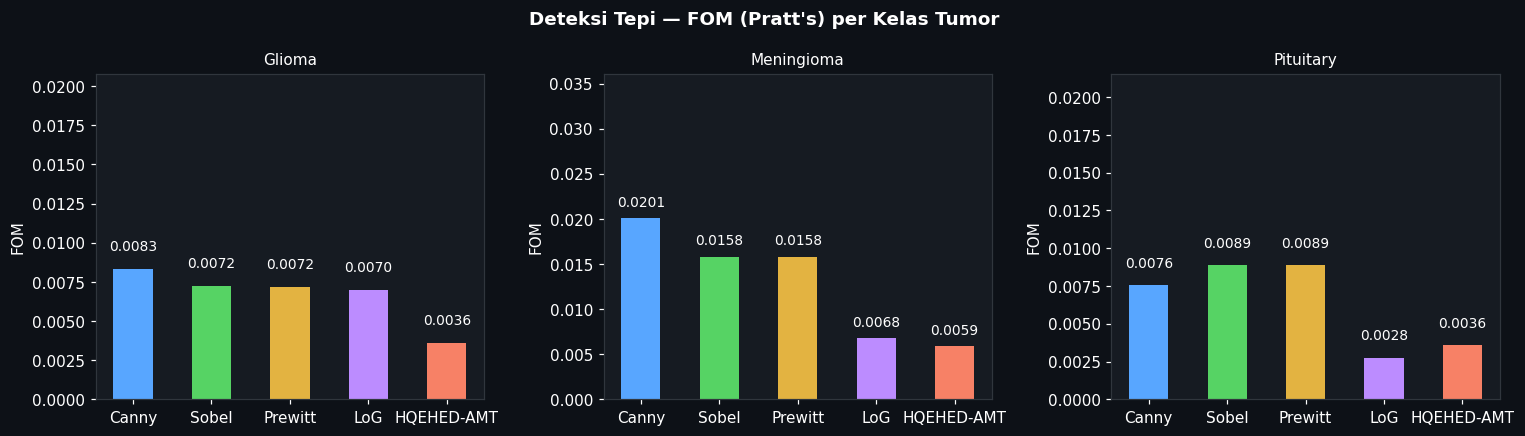

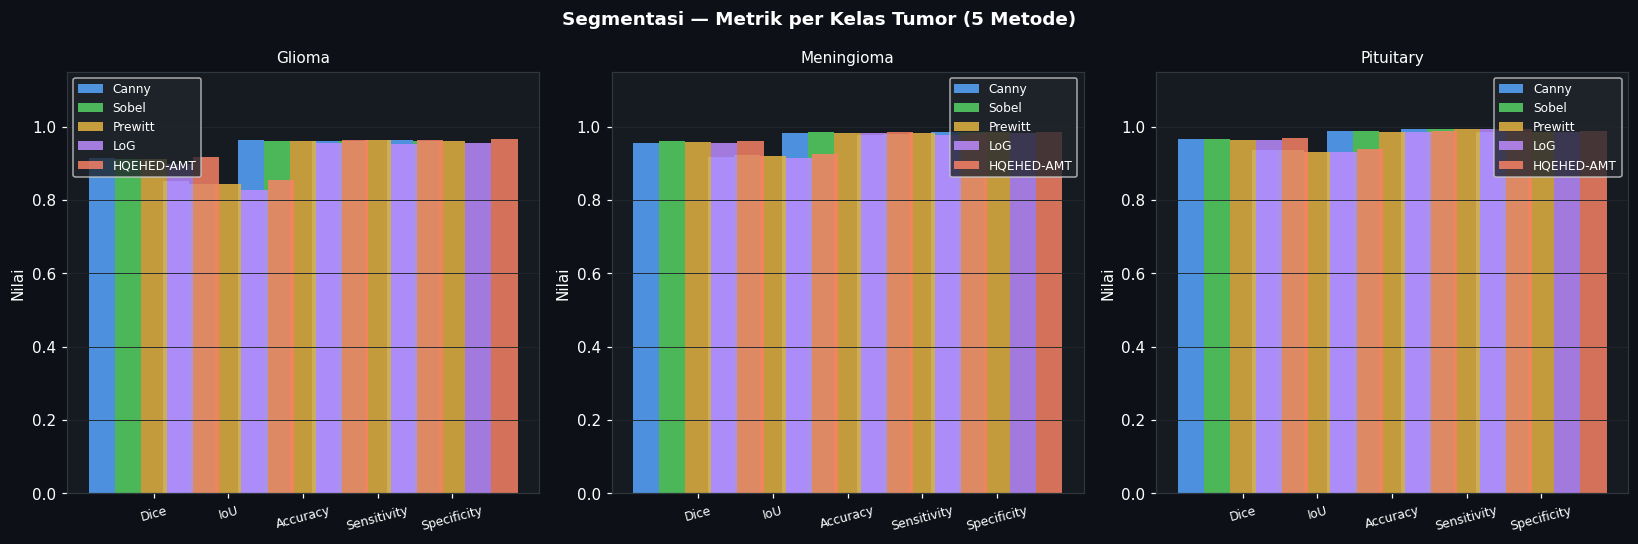

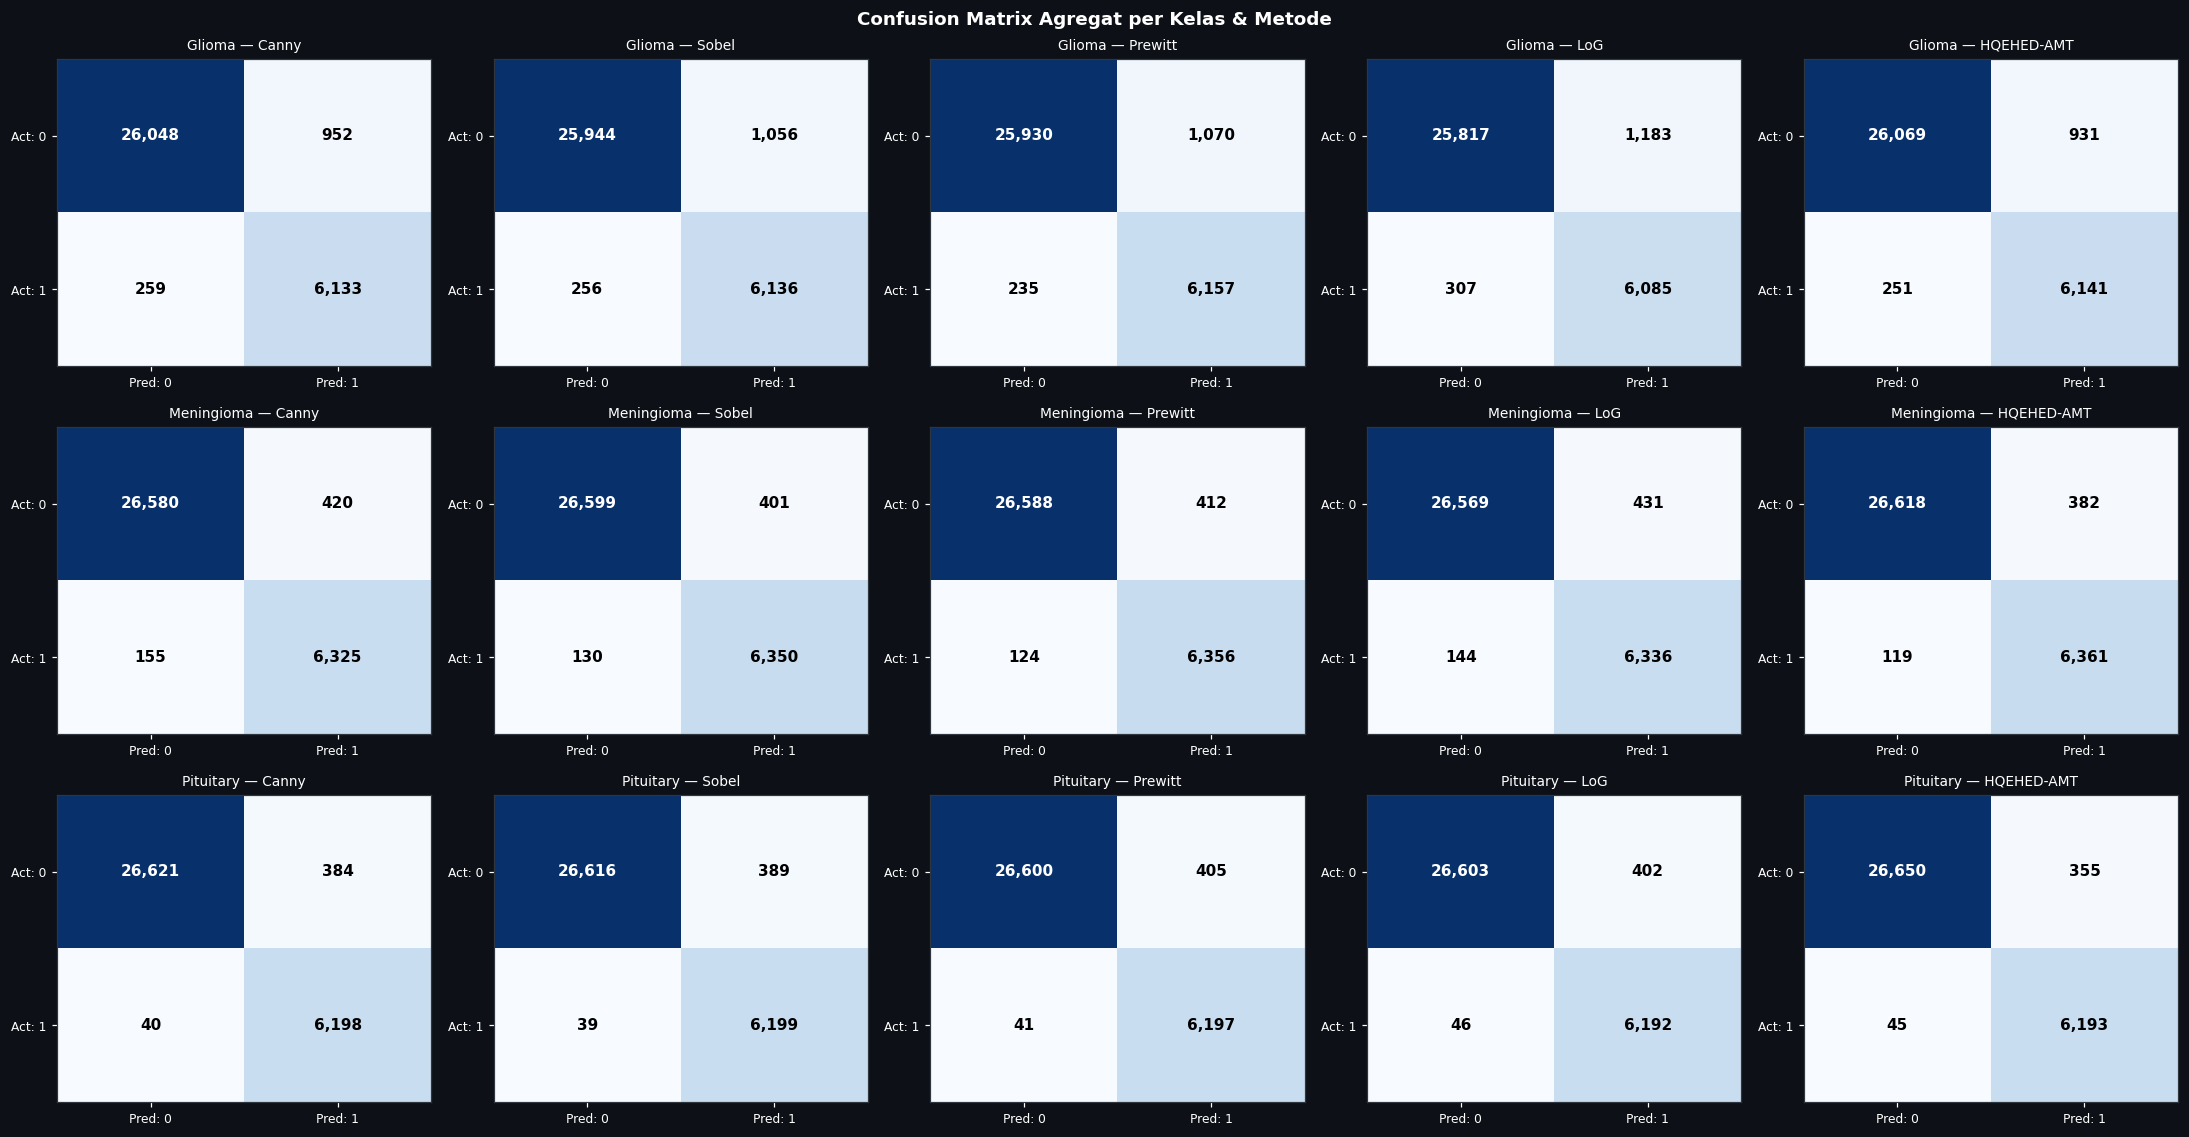


  RATA-RATA KESELURUHAN (semua kelas)
  Metrik                         Canny           Sobel         Prewitt             LoG      HQEHED-AMT
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  [Deteksi Tepi]
  FOM (Pratt's)                 0.0120          0.0106          0.0106          0.0055          0.0044
  [Segmentasi]
  Accuracy                      0.9781          0.9775          0.9773          0.9750          0.9793
  Sensitivity                   0.9773          0.9789          0.9799          0.9749          0.9790
  Specificity                   0.9783          0.9772          0.9767          0.9751          0.9794
  Dice                          0.9463          0.9457          0.9446          0.9395          0.9491
  IoU                           0.9014          0.9011          0.8989          0.8913          0.9066

Gambar tersimpan di: ./results_paper1/
  - eval_fom_per_kelas.png
  - eval_segmentasi_per_kelas.png
  - 

  Ablasi pituitary: 100%|██████████| 10/10 [00:12<00:00,  1.25s/it]



  [GLIOMA]
  Metrik                WithEdge   WithoutEdge         Delta
  ──────────────────────────────────────────────────────────
  Dice                    0.9346        0.9202       +0.0144
  IoU                     0.8793        0.8545       +0.0248
  Accuracy                0.9732        0.9669       +0.0064
  Sensitivity             0.9712        0.9712       -0.0000
  Specificity             0.9738        0.9659       +0.0078

  [MENINGIOMA]
  Metrik                WithEdge   WithoutEdge         Delta
  ──────────────────────────────────────────────────────────
  Dice                    0.9650        0.9565       +0.0085
  IoU                     0.9327        0.9174       +0.0154
  Accuracy                0.9856        0.9819       +0.0037
  Sensitivity             0.9882        0.9867       +0.0016
  Specificity             0.9849        0.9807       +0.0042

  [PITUITARY]
  Metrik                WithEdge   WithoutEdge         Delta
  ────────────────────────────────────────

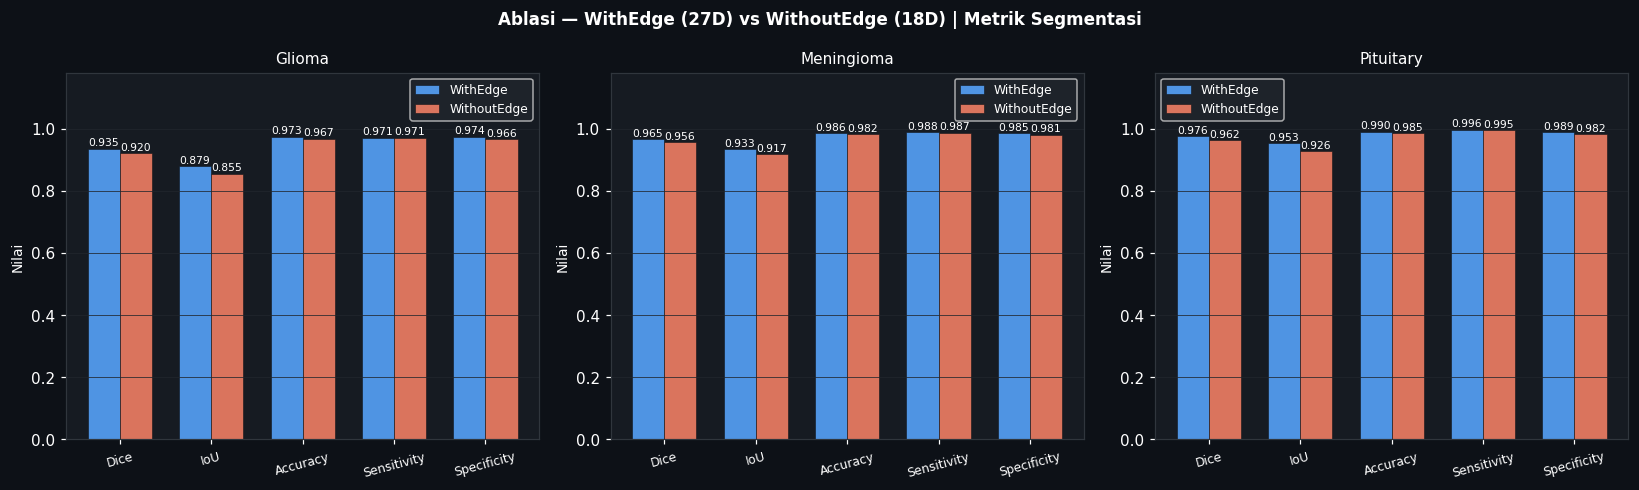

  - eval_ablasi_edge.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
# BAGIAN 3 — Evaluasi Komparatif per Kelas Tumor
# ══════════════════════════════════════════════════════════════════

if not pairs or 'C_opt' not in dir():
    print("Prasyarat belum terpenuhi:")
    print("  - Jalankan Cell 5  (load dataset)")
    print("  - Jalankan Cell 12 (PSO tuning -> C_opt, g_opt)")
else:
    import warnings
    warnings.filterwarnings("ignore")

    # ── Konfigurasi evaluasi ──────────────────────────────────────
    TUMOR_CLASSES      = ['glioma', 'meningioma', 'pituitary']
    N_EVAL_PER_CLASS   = 15        # gambar per kelas; kurangi jika lambat
    CANNY_LOW          = 50
    CANNY_HIGH         = 150
    _G     = BEST_GAMMA     if 'BEST_GAMMA'     in dir() else GAMMA
    _GNEG  = BEST_GAMMA_NEG if 'BEST_GAMMA_NEG' in dir() else GAMMA_NEG
    _CROP  = BEST_CROP_SIZE if 'BEST_CROP_SIZE' in dir() else CROP_SIZE

    import seaborn as sns
    import pandas as pd
    try:
        from tabulate import tabulate as _tabulate; _HAS_TAB = True
    except ImportError:
        _HAS_TAB = False

    def _cc_clean(mask_raw):
        if mask_raw.max() == 0: return mask_raw.copy()
        k3 = np.ones((3,3), np.uint8)
        opened = cv2.morphologyEx(mask_raw.astype(np.uint8), cv2.MORPH_OPEN, k3)
        n_lbl, lbl, stats, _ = cv2.connectedComponentsWithStats(opened, connectivity=8)
        sizes = [(stats[i,cv2.CC_STAT_AREA],i) for i in range(1,n_lbl)
                 if stats[i,cv2.CC_STAT_AREA] >= cfg.CC_MIN_SIZE]
        sizes.sort(reverse=True)
        out = np.zeros_like(mask_raw, dtype=np.uint8)
        for _, idx in sizes[:cfg.CC_MAX_BLOBS]: out[lbl==idx] = 1
        return out

    EVAL_METHODS = {
        'Canny'     : lambda img_pre: cv2.Canny(
            (img_pre * 255).astype(np.uint8), CANNY_LOW, CANNY_HIGH) // 255,
        'Sobel'     : sobel_edge,
        'Prewitt'   : prewitt_edge,
        'LoG'       : log_edge,
        'HQEHED-AMT': lambda img_pre: hqehed_amt(img_pre, _CROP, _G, _GNEG),
    }

    # ── Load ulang semua pairs dari disk ─────────────────────────
    # Jangan pakai variable 'pairs' dari sesi sebelumnya yang
    # mungkin sudah difilter/terbatas — load fresh dari DATA_ROOT.
    all_pairs = load_dataset_paths(cfg.DATA_ROOT)
    print(f"Dataset dimuat ulang: {len(all_pairs)} total gambar")

    # ── Kelompokkan per kelas ─────────────────────────────────────
    class_pairs = {tc: [] for tc in TUMOR_CLASSES}
    for img_p, msk_p in all_pairs:
        tc = os.path.basename(os.path.dirname(os.path.dirname(img_p)))
        if tc in class_pairs:
            class_pairs[tc].append((img_p, msk_p))

    # ── Diagnostik distribusi ─────────────────────────────────────
    print("Distribusi per kelas:")
    for tc in TUMOR_CLASSES:
        n_total = len(class_pairs[tc])
        n_eval  = min(N_EVAL_PER_CLASS, n_total)
        if n_total == 0:
            print(f"  [PERINGATAN] {tc}: 0 gambar — periksa DATA_ROOT={cfg.DATA_ROOT}")
        else:
            print(f"  {tc}: {n_total} tersedia, {n_eval} akan dievaluasi")

    # ── Fungsi evaluasi satu gambar ───────────────────────────────
    def _eval_image(img_pre, gt_mask, edge_map):
        """Kembalikan dict metrik deteksi tepi + segmentasi."""
        # --- Tahap 1: Deteksi Tepi (FOM) ---
        gt_edge = cv2.Canny((gt_mask * 255).astype(np.uint8), 50, 150) // 255
        fom_val = figure_of_merit(edge_map, gt_edge)

        # --- Tahap 2: Segmentasi (SVM) ---
        fm         = _build_feature_maps(img_pre, edge_map)
        tumor_c    = list(zip(*np.where(gt_mask == 1)))
        nontumor_c = list(zip(*np.where(gt_mask == 0)))
        n_t  = min(EVAL_N_TUMOR,    len(tumor_c))
        n_nt = min(EVAL_N_NONTUMOR, len(nontumor_c))
        if n_t == 0:
            return None
        sampled = random.sample(tumor_c, n_t) + random.sample(nontumor_c, n_nt)
        labels  = [1] * n_t + [0] * n_nt
        X_img   = np.array([_feat_vec(fm, y, x) for (y, x) in sampled],
                           dtype=np.float32)
        y_img   = np.array(labels, dtype=np.int32)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_img, y_img, test_size=0.3, random_state=42, stratify=y_img)
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)
        svm_e  = SVC(C=C_opt, gamma=g_opt, kernel=cfg.SVM_KERNEL,
                     class_weight=cfg.SVM_CLASS_WEIGHT)
        svm_e.fit(X_tr_s, y_tr)
        y_pred = svm_e.predict(X_te_s)

        tp = int(np.sum((y_pred == 1) & (y_te == 1)))
        tn = int(np.sum((y_pred == 0) & (y_te == 0)))
        fp = int(np.sum((y_pred == 1) & (y_te == 0)))
        fn = int(np.sum((y_pred == 0) & (y_te == 1)))
        eps = 1e-8
        return {
            'fom' : fom_val,
            'tp'  : tp, 'tn': tn, 'fp': fp, 'fn': fn,
            'dice': 2*tp  / (2*tp + fp + fn + eps),
            'iou' : tp    / (tp + fp + fn + eps),
            'acc' : (tp+tn) / (tp+tn+fp+fn + eps),
            'sen' : tp    / (tp + fn + eps),
            'spe' : tn    / (tn + fp + eps),
        }

    # ── Loop evaluasi utama ───────────────────────────────────────
    eval_results = {tc: {m: [] for m in EVAL_METHODS} for tc in TUMOR_CLASSES}

    for tc in TUMOR_CLASSES:
        subset = class_pairs[tc][:N_EVAL_PER_CLASS]
        print(f"\nEvaluasi kelas [{tc.upper()}] ({len(subset)} gambar) ...")
        for img_p, msk_p in tqdm(subset, desc=f"  {tc}"):
            img_raw, gt_mask = load_image_mask(img_p, msk_p, cfg.IMG_SIZE)
            img_pre = preprocess(img_raw, GAUSS_KSIZE, GAUSS_SIGMA)
            for method_name, edge_fn in EVAL_METHODS.items():
                edge_map = edge_fn(img_pre)
                r = _eval_image(img_pre, gt_mask, edge_map)
                if r:
                    eval_results[tc][method_name].append(r)

    # ── Agregasi hasil ────────────────────────────────────────────
    SEG_KEYS  = ['acc', 'sen', 'spe', 'dice', 'iou']
    EDGE_KEYS = ['fom']
    SEG_LABEL = {'acc':'Accuracy','sen':'Sensitivity','spe':'Specificity',
                 'dice':'Dice','iou':'IoU'}

    summary = {}
    for tc in TUMOR_CLASSES:
        summary[tc] = {}
        for m in EVAL_METHODS:
            rs = eval_results[tc][m]
            if not rs:
                continue
            summary[tc][m] = {
                k: float(np.mean([r[k] for r in rs]))
                for k in SEG_KEYS + EDGE_KEYS
            }
            summary[tc][m]['TP'] = sum(r['tp'] for r in rs)
            summary[tc][m]['TN'] = sum(r['tn'] for r in rs)
            summary[tc][m]['FP'] = sum(r['fp'] for r in rs)
            summary[tc][m]['FN'] = sum(r['fn'] for r in rs)

    # ── Print tabel ringkasan ─────────────────────────────────────
    METHODS = list(EVAL_METHODS.keys())
    W = 14

    def _ptbl(title, hdrs, rows):
        print(f"\n  {title}")
        if _HAS_TAB:
            print(_tabulate(rows, headers=hdrs, tablefmt='rounded_outline',
                            floatfmt='.4f', numalign='right'))
        else:
            print("  " + f"{'Metrik':<18}" + "".join(f"{h:>{W}}" for h in hdrs[1:]))
            print("  " + "─"*18 + "─"*W*len(hdrs[1:]))
            for row in rows:
                lbl = row[0]; vals = row[1:]
                print("  " + f"{lbl:<18}" +
                      "".join((f"{v:>{W}.4f}" if isinstance(v,float) else
                               (f"{v:>{W},}" if isinstance(v,int) else f"{v:>{W}}"))
                              for v in vals))

    print(f"\n{'═'*72}")
    print("  HASIL EVALUASI KOMPARATIF — RINGKASAN PER KELAS")
    print(f"{'═'*72}")
    for tc in TUMOR_CLASSES:
        print(f"\n  ▌ {tc.upper()}")
        rows_e = [['FOM (Pratt\'s)'] +
                  [summary[tc].get(m,{}).get('fom', float('nan')) for m in METHODS]]
        for k, lbl in [('prec','Precision'),('rec','Recall'),('f1','F1-Score')]:
            rows_e.append([lbl] +
                [summary[tc].get(m,{}).get(k, float('nan')) for m in METHODS])
        _ptbl('Deteksi Tepi:', ['Metrik']+METHODS, rows_e)
        rows_s = [[SEG_LABEL[k]] +
                  [summary[tc].get(m,{}).get(k, float('nan')) for m in METHODS]
                  for k in SEG_KEYS]
        _ptbl('Segmentasi:', ['Metrik']+METHODS, rows_s)

    # ══════════════════════════════════════════════════════════════
    # VISUALISASI
    # ══════════════════════════════════════════════════════════════

    # ── 1. Bar chart FOM per kelas ────────────────────────────────
    PALETTE = {'Canny':'#58a6ff','Sobel':'#56d364','Prewitt':'#e3b341',
               'LoG':'#bc8cff','HQEHED-AMT':'#f78166'}
    colors = PALETTE

    # ── 1. Grouped bar: FOM + F1 + Dice + IoU (4 metrik × 3 kelas) ──────
    _met4 = [('fom','FOM'),('f1','F1-Score'),('dice','Dice'),('iou','IoU')]
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle('Evaluasi Deteksi Tepi & Segmentasi — Semua Metode & Kelas Tumor',
                 color='white', fontsize=12, fontweight='bold')
    x_c = np.arange(len(TUMOR_CLASSES)); bw = 0.75/len(METHODS)
    for ax, (mk, mlbl) in zip(axes, _met4):
        ax.set_facecolor('#161b22')
        for j, m in enumerate(METHODS):
            vals = [summary[tc].get(m,{}).get(mk,0) for tc in TUMOR_CLASSES]
            offset = (j-(len(METHODS)-1)/2)*bw
            bars = ax.bar(x_c+offset, vals, bw, label=m,
                          color=PALETTE[m], alpha=0.88,
                          edgecolor='#0d1117', linewidth=0.4)
            for b, v in zip(bars, vals):
                ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                        f'{v:.3f}', ha='center', color='white',
                        fontsize=6.5, fontweight='bold')
        ax.set_xticks(x_c)
        ax.set_xticklabels([tc.capitalize() for tc in TUMOR_CLASSES],
                           color='white', fontsize=9)
        ax.set_ylabel(mlbl, color='white', fontsize=9)
        ax.set_ylim(0, 1.2)
        ax.tick_params(colors='white'); ax.spines[:].set_color('#30363d')
        ax.legend(facecolor='#21262d', labelcolor='white', fontsize=7.5,
                  loc='upper right')
        ax.grid(axis='y', color='#21262d', linewidth=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'eval_fom_per_kelas.png'),
                dpi=120, bbox_inches='tight', facecolor='#0d1117')
    plt.show(); plt.close()

    # ── 2. Heatmap metrik segmentasi: Metode × Metrik (per kelas + avg) ──
    n_classes = len(TUMOR_CLASSES); n_methods = len(METHODS)
    seg_display = ['dice','iou','acc','sen','spe']
    seg_labels  = ['Dice','IoU','Accuracy','Sensitivity','Specificity']

    fig, axes = plt.subplots(1, n_classes+1,
                             figsize=(5.5*(n_classes+1), 4.5))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle('Heatmap Metrik Segmentasi PSO-SVM (Metode × Metrik)',
                 color='white', fontsize=12, fontweight='bold')
    for ax, tc in zip(axes[:-1], TUMOR_CLASSES):
        df_tc = pd.DataFrame(
            {lbl: [summary[tc].get(m,{}).get(k,0) for m in METHODS]
             for k, lbl in zip(seg_display, seg_labels)},
            index=METHODS)
        sns.heatmap(df_tc, ax=ax, annot=True, fmt='.3f', cmap='YlGnBu',
                    linewidths=0.5, linecolor='#0d1117',
                    annot_kws={'size':9,'weight':'bold','color':'black'},
                    cbar_kws={'shrink':0.8}, vmin=0, vmax=1)
        ax.set_title(tc.capitalize(), color='white', fontsize=10, pad=8)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right',
                           color='white', fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0,
                           color='white', fontsize=8)
        ax.tick_params(colors='white', length=0)
    # Rata-rata semua kelas
    df_avg = pd.DataFrame(
        {lbl: [np.mean([summary[tc].get(m,{}).get(k,0) for tc in TUMOR_CLASSES])
               for m in METHODS]
         for k, lbl in zip(seg_display, seg_labels)},
        index=METHODS)
    sns.heatmap(df_avg, ax=axes[-1], annot=True, fmt='.3f', cmap='YlOrRd',
                linewidths=0.5, linecolor='#0d1117',
                annot_kws={'size':9,'weight':'bold','color':'black'},
                cbar_kws={'shrink':0.8}, vmin=0, vmax=1)
    axes[-1].set_title('Rata-rata Semua Kelas', color='white', fontsize=10, pad=8)
    axes[-1].set_xticklabels(axes[-1].get_xticklabels(), rotation=25,
                              ha='right', color='white', fontsize=8)
    axes[-1].set_yticklabels(axes[-1].get_yticklabels(), rotation=0,
                              color='white', fontsize=8)
    axes[-1].tick_params(colors='white', length=0)
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'eval_segmentasi_per_kelas.png'),
                dpi=120, bbox_inches='tight', facecolor='#0d1117')
    plt.show(); plt.close()

    # ── 3. Confusion matrix heatmap per kelas × metode ────────────
    fig, axes = plt.subplots(n_classes, n_methods,
                             figsize=(4*n_methods, 3.8*n_classes))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle('Confusion Matrix Segmentasi — Per Kelas & Metode',
                 color='white', fontsize=12, fontweight='bold')
    for i, tc in enumerate(TUMOR_CLASSES):
        for j, m in enumerate(METHODS):
            ax = axes[i][j]
            s_ = summary[tc].get(m, {})
            cm_arr = np.array([[s_.get('TN',0), s_.get('FP',0)],
                                [s_.get('FN',0), s_.get('TP',0)]])
            sns.heatmap(cm_arr, ax=ax, annot=True, fmt=',d', cmap='Blues',
                        linewidths=1.0, linecolor='#0d1117',
                        xticklabels=['Pred–','Pred+'],
                        yticklabels=['Act–', 'Act+'],
                        annot_kws={'size':10,'weight':'bold'},
                        cbar=False)
            ax.set_title(f'{tc.capitalize()} — {m}', color='white',
                         fontsize=8.5, fontweight='bold', pad=4)
            ax.set_xticklabels(ax.get_xticklabels(), color='white', fontsize=8)
            ax.set_yticklabels(ax.get_yticklabels(), color='white',
                               fontsize=8, rotation=0)
            ax.tick_params(colors='white', length=0)
            ax.set_facecolor('#161b22')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'eval_confusion_matrix.png'),
                dpi=120, bbox_inches='tight', facecolor='#0d1117')
    plt.show(); plt.close()

    # ── 4. Ringkasan numerik akhir ────────────────────────────────
    print(f"\n{'='*70}")
    print("  RATA-RATA KESELURUHAN (semua kelas)")
    print(f"{'='*70}")
    _all_keys = ([('FOM (Pratt\'s)', 'fom')] +
                 [(lbl, k) for k, lbl in zip(seg_display, seg_labels)])
    _sum_rows = []
    for lbl, k in _all_keys:
        vals = [float(np.nanmean([summary[tc].get(m,{}).get(k,float('nan'))
                                  for tc in TUMOR_CLASSES]))
                for m in METHODS]
        _sum_rows.append([lbl] + vals)
    _ptbl('Rata-rata semua kelas (Deteksi Tepi + Segmentasi):',
          ['Metrik']+METHODS, _sum_rows)
    print(f"\nGambar tersimpan di: {cfg.OUTPUT_DIR}/")
    print("  - eval_fom_per_kelas.png       (grouped bar 4 metrik)")
    print("  - eval_segmentasi_per_kelas.png (heatmap metrik segmentasi)")
    print("  - eval_confusion_matrix.png    (seaborn heatmap)")
    # ══════════════════════════════════════════════════════════════
    # ABLASI — Kontribusi Fitur Edge Detection: 27D vs 18D
    # ══════════════════════════════════════════════════════════════
    # WithEdge   (27D): fitur dari 9 map x 3 statistik (termasuk edge)
    # WithoutEdge(18D): fitur dari 6 map x 3 statistik (citra saja)
    N_ABL = min(10, N_EVAL_PER_CLASS)
    print(f"\n{'='*70}")
    print("  ABLASI — WithEdge (27D) vs WithoutEdge (18D)")
    print(f"{'='*70}")
    _ABL_KEYS = ['dice', 'iou', 'acc', 'sen', 'spe']
    _ABL_LBL  = {'dice':'Dice','iou':'IoU','acc':'Accuracy',
                 'sen':'Sensitivity','spe':'Specificity'}
    res_abl = {tc: {'WithEdge': [], 'WithoutEdge': []} for tc in TUMOR_CLASSES}

    for tc in TUMOR_CLASSES:
        for img_p, msk_p in tqdm(class_pairs[tc][:N_ABL], desc=f'  Ablasi {tc}'):
            img_raw, gt_mask = load_image_mask(img_p, msk_p, cfg.IMG_SIZE)
            img_pre = preprocess(img_raw, GAUSS_KSIZE, GAUSS_SIGMA)
            edge_we = hqehed_amt(img_pre, _CROP, _G, _GNEG)
            tc_px   = list(zip(*np.where(gt_mask == 1)))
            nc_px   = list(zip(*np.where(gt_mask == 0)))
            n_t     = min(EVAL_N_TUMOR, len(tc_px))
            n_nt    = min(EVAL_N_NONTUMOR, len(nc_px))
            if n_t == 0:
                continue
            spl = random.sample(tc_px, n_t) + random.sample(nc_px, n_nt)
            lbs = [1] * n_t + [0] * n_nt
            y_a = np.array(lbs, np.int32)
            for label in ['WithEdge', 'WithoutEdge']:
                if label == 'WithEdge':
                    fm_a = _build_feature_maps(img_pre, edge_we)
                    X_a  = np.array([_feat_vec(fm_a, y, x) for y, x in spl], np.float32)
                else:
                    fm_a = _build_feature_maps_noedge(img_pre)
                    X_a  = np.array([_feat_vec_noedge(fm_a, y, x) for y, x in spl], np.float32)
                X_tr, X_te, y_tr, y_te = train_test_split(
                    X_a, y_a, test_size=0.3, random_state=42, stratify=y_a)
                sc_a  = StandardScaler()
                svm_a = SVC(C=C_opt, gamma=g_opt, kernel=cfg.SVM_KERNEL,
                            class_weight=cfg.SVM_CLASS_WEIGHT)
                svm_a.fit(sc_a.fit_transform(X_tr), y_tr)
                yp  = svm_a.predict(sc_a.transform(X_te))
                tp  = int(np.sum((yp == 1) & (y_te == 1)))
                tn  = int(np.sum((yp == 0) & (y_te == 0)))
                fp  = int(np.sum((yp == 1) & (y_te == 0)))
                fn  = int(np.sum((yp == 0) & (y_te == 1)))
                eps = 1e-8
                res_abl[tc][label].append({
                    'dice': 2*tp/(2*tp+fp+fn+eps), 'iou': tp/(tp+fp+fn+eps),
                    'acc' : (tp+tn)/(tp+tn+fp+fn+eps),
                    'sen' : tp/(tp+fn+eps),         'spe': tn/(tn+fp+eps),
                })

    # Agregasi & print tabel ablasi
    smm_abl = {}
    for tc in TUMOR_CLASSES:
        smm_abl[tc] = {}
        for m in ['WithEdge', 'WithoutEdge']:
            rs = res_abl[tc][m]
            if rs:
                smm_abl[tc][m] = {k: float(np.mean([r[k] for r in rs]))
                                  for k in _ABL_KEYS}
    Wa = 14
    for tc in TUMOR_CLASSES:
        print(f"\n  [{tc.upper()}]")
        print(f"  {'Metrik':<16}" + ''.join(f"{'WithEdge':>{Wa}}")
              + f"{'WithoutEdge':>{Wa}}" + f"{'Delta':>{Wa}}")
        print(f"  {'─'*16}" + '─' * Wa * 3)
        for k in _ABL_KEYS:
            we  = smm_abl[tc].get('WithEdge',    {}).get(k, float('nan'))
            noe = smm_abl[tc].get('WithoutEdge', {}).get(k, float('nan'))
            if not (we != we or noe != noe):
                d = we - noe; sign = '+' if d >= 0 else ''
                d_str = f'{sign}{d:.4f}'
            else:
                d_str = '    nan'
            print(f"  {_ABL_LBL[k]:<16}{we:>{Wa}.4f}{noe:>{Wa}.4f}{d_str:>{Wa}}")

    # Ablasi: grouped bar + heatmap delta (per kelas)
    ABL_COLORS = ['#58a6ff', '#f78166']
    fig = plt.figure(figsize=(22, 4.5*len(TUMOR_CLASSES)))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle('Ablasi Fitur Edge — WithEdge (27D) vs WithoutEdge (18D)',
                 color='white', fontsize=12, fontweight='bold')
    gs = fig.add_gridspec(len(TUMOR_CLASSES), 3, width_ratios=[2.2,2.2,1.6],
                          hspace=0.45, wspace=0.38)
    for ri, tc in enumerate(TUMOR_CLASSES):
        ax_bar = fig.add_subplot(gs[ri, :2])
        ax_bar.set_facecolor('#161b22')
        x_abl = np.arange(len(_ABL_KEYS)); bw_abl = 0.32
        for j, (m, color) in enumerate(zip(['WithEdge','WithoutEdge'], ABL_COLORS)):
            vals = [smm_abl[tc].get(m,{}).get(k,0) for k in _ABL_KEYS]
            offset = (j-0.5)*bw_abl
            bars = ax_bar.bar(x_abl+offset, vals, bw_abl, label=m,
                              color=color, alpha=0.88, edgecolor='#0d1117', linewidth=0.4)
            for b, v in zip(bars, vals):
                ax_bar.text(b.get_x()+b.get_width()/2, b.get_height()+0.013,
                            f'{v:.3f}', ha='center', color='white',
                            fontsize=8, fontweight='bold')
        ax_bar.set_xticks(x_abl)
        ax_bar.set_xticklabels([_ABL_LBL[k] for k in _ABL_KEYS],
                                color='white', fontsize=9)
        ax_bar.set_ylim(0, 1.22); ax_bar.set_ylabel('Nilai', color='white')
        ax_bar.set_title(f'{tc.capitalize()} — Metrik Segmentasi',
                          color='white', fontsize=10, fontweight='bold')
        ax_bar.tick_params(colors='white'); ax_bar.spines[:].set_color('#30363d')
        ax_bar.legend(facecolor='#21262d', labelcolor='white', fontsize=9)
        ax_bar.grid(axis='y', color='#21262d', linewidth=0.5)
        # Delta heatmap
        ax_hm = fig.add_subplot(gs[ri, 2])
        we_v  = [smm_abl[tc].get('WithEdge',   {}).get(k, float('nan')) for k in _ABL_KEYS]
        noe_v = [smm_abl[tc].get('WithoutEdge',{}).get(k, float('nan')) for k in _ABL_KEYS]
        delta = [we-noe if not(we!=we or noe!=noe) else float('nan')
                 for we,noe in zip(we_v, noe_v)]
        df_d  = pd.DataFrame({'WithEdge':we_v,'W/oEdge':noe_v,'Δ':delta},
                              index=[_ABL_LBL[k] for k in _ABL_KEYS])
        sns.heatmap(df_d, ax=ax_hm, annot=True, fmt='.3f', cmap='RdYlGn',
                    center=0, linewidths=0.5, linecolor='#0d1117',
                    annot_kws={'size':8,'weight':'bold'},
                    cbar_kws={'shrink':0.7})
        ax_hm.set_title(f'{tc.capitalize()} — Δ (WithEdge−W/oEdge)',
                         color='white', fontsize=10, fontweight='bold')
        ax_hm.set_xticklabels(ax_hm.get_xticklabels(), color='white',
                               fontsize=8, rotation=15, ha='right')
        ax_hm.set_yticklabels(ax_hm.get_yticklabels(), color='white',
                               fontsize=8, rotation=0)
        ax_hm.tick_params(colors='white', length=0)
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'eval_ablasi_edge.png'),
                dpi=120, bbox_inches='tight', facecolor='#0d1117')
    plt.show(); plt.close()
    print(f"  - eval_ablasi_edge.png")

    # ══════════════════════════════════════════════════════════════
    # VISUALISASI SEGMENTASI: WithEdge (27D) vs WithoutEdge (18D)
    # 1 gambar per kelas tumor — prediksi full-image
    # ══════════════════════════════════════════════════════════════
    print(f"\n{'='*70}")
    print("  VISUALISASI SEGMENTASI — WithEdge (27D) vs WithoutEdge (18D)")
    print(f"{'='*70}")
    _SEG_TITLES = ['MRI Input','GT Mask','WithEdge 27D','WithoutEdge 18D',
                   'Overlay Perbandingan']
    _vis_imgs = [(tc, class_pairs[tc][0][0], class_pairs[tc][0][1])
                 for tc in TUMOR_CLASSES if class_pairs[tc]]
    n_vis = len(_vis_imgs)
    fig, axes = plt.subplots(n_vis, len(_SEG_TITLES),
                             figsize=(4.8*len(_SEG_TITLES), 4.8*n_vis))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle('Segmentasi WithEdge (27D) vs WithoutEdge (18D) — 1 Sampel per Kelas',
                 color='white', fontsize=12, fontweight='bold')
    if n_vis == 1: axes = [axes]
    for ci, t in enumerate(_SEG_TITLES):
        axes[0][ci].set_title(t, color='white', fontsize=9, fontweight='bold')
    for ri, (tc, ip, mp) in enumerate(_vis_imgs):
        img_v, gt_v = load_image_mask(ip, mp, cfg.IMG_SIZE)
        img_p_v     = preprocess(img_v, GAUSS_KSIZE, GAUSS_SIGMA)
        edge_v      = hqehed_amt(img_p_v, _CROP, _G, _GNEG)
        tc_px_v = list(zip(*np.where(gt_v==1)))
        nc_px_v = list(zip(*np.where(gt_v==0)))
        n_t_v = min(EVAL_N_TUMOR,    len(tc_px_v))
        n_nt_v= min(EVAL_N_NONTUMOR, len(nc_px_v))
        if n_t_v == 0:
            for ci in range(len(_SEG_TITLES)): axes[ri][ci].axis('off')
            continue
        spl_v = random.sample(tc_px_v, n_t_v) + random.sample(nc_px_v, n_nt_v)
        lbs_v = [1]*n_t_v + [0]*n_nt_v
        # WithEdge 27D
        fm_we = _build_feature_maps(img_p_v, edge_v)
        X_we  = np.array([_feat_vec(fm_we,y,x) for y,x in spl_v], dtype=np.float32)
        sc_we = StandardScaler(); svm_we = SVC(C=C_opt, gamma=g_opt,
                    kernel=cfg.SVM_KERNEL, class_weight=cfg.SVM_CLASS_WEIGHT)
        svm_we.fit(sc_we.fit_transform(X_we), lbs_v)
        pred_we = _cc_clean(_predict_full_image(img_p_v, edge_v, svm_we, sc_we))
        # WithoutEdge 18D
        fm_ne = _build_feature_maps_noedge(img_p_v)
        X_ne  = np.array([_feat_vec_noedge(fm_ne,y,x) for y,x in spl_v], dtype=np.float32)
        sc_ne = StandardScaler(); svm_ne = SVC(C=C_opt, gamma=g_opt,
                    kernel=cfg.SVM_KERNEL, class_weight=cfg.SVM_CLASS_WEIGHT)
        svm_ne.fit(sc_ne.fit_transform(X_ne), lbs_v)
        pred_ne = _cc_clean(_predict_full_noedge(img_p_v, svm_ne, sc_ne))
        d_we = dice_score(pred_we, gt_v); d_ne = dice_score(pred_ne, gt_v)
        print(f"  {tc:<12}: WithEdge Dice={d_we:.4f} | WithoutEdge Dice={d_ne:.4f}"
              f" | Δ={d_we-d_ne:+.4f}")
        # Overlay: hijau=hanya WE, merah=hanya NE, biru=keduanya, kuning=GT kontur
        ov = np.zeros((*gt_v.shape,3), dtype=np.uint8)
        ov[(pred_we==1)&(pred_ne==0)] = [80,  200, 80 ]
        ov[(pred_we==0)&(pred_ne==1)] = [200, 80,  80 ]
        ov[(pred_we==1)&(pred_ne==1)] = [120, 160, 220]
        gt_u8 = (gt_v*255).astype(np.uint8)
        ctr,_ = cv2.findContours(gt_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(ov, ctr, -1, (255,220,0), 2)
        for ci,(im,cm_,xlbl) in enumerate([
            (img_v,'gray',''),
            (gt_v,'hot',''),
            (pred_we,'hot',f'Dice={d_we:.3f}'),
            (pred_ne,'hot',f'Dice={d_ne:.3f}'),
            (ov,None,'●Hijau=WE ●Merah=NE ●Biru=Both ●Kuning=GT'),
        ]):
            ax=axes[ri][ci]; ax.set_facecolor('#0d1117')
            ax.imshow(im, cmap=cm_) if cm_ else ax.imshow(im)
            ax.axis('off')
            if xlbl:
                ax.set_xlabel(xlbl, color='#8b949e', fontsize=7.5)
        axes[ri][0].set_ylabel(tc.capitalize(), color='white', fontsize=10,
                               rotation=0, labelpad=55, va='center')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'eval_ablasi_seg_samples.png'),
                dpi=110, bbox_inches='tight', facecolor='#0d1117')
    plt.show(); plt.close()
    print(f"  - eval_ablasi_seg_samples.png")

    # ══════════════════════════════════════════════════════════════════
    # BENCHMARK KECEPATAN DETEKSI TEPI
    # Mengukur waktu eksekusi tiap metode pada gambar representatif
    # ══════════════════════════════════════════════════════════════════
    import time as _time

    print(f"\n{'='*70}")
    print("  BENCHMARK KECEPATAN — Metode Deteksi Tepi")
    print(f"{'='*70}")

    # Ambil 1 gambar representatif (dari kelas pertama yang tersedia)
    _bm_img = None
    for _tc_bm in TUMOR_CLASSES:
        if class_pairs[_tc_bm]:
            _bm_ip, _bm_mp = class_pairs[_tc_bm][0]
            _bm_raw, _     = load_image_mask(_bm_ip, _bm_mp, cfg.IMG_SIZE)
            _bm_img        = preprocess(_bm_raw, GAUSS_KSIZE, GAUSS_SIGMA)
            print(f"  Gambar uji: {os.path.basename(_bm_ip)}"
                  f" ({cfg.IMG_SIZE}x{cfg.IMG_SIZE} px)")
            break
    if _bm_img is None:
        print("  [SKIP] Tidak ada gambar tersedia untuk benchmark.")
    else:
        N_WARMUP = 5
        N_BENCH  = 80   # run per metode
        _spd_raw = {}
        for _mn, _mfn in EVAL_METHODS.items():
            for _ in range(N_WARMUP): _mfn(_bm_img)   # warm-up
            _t_list = []
            for _ in range(N_BENCH):
                _t0 = _time.perf_counter()
                _mfn(_bm_img)
                _t_list.append((_time.perf_counter() - _t0) * 1000)
            _spd_raw[_mn] = _t_list

        _hq_mean = float(np.mean(_spd_raw['HQEHED-AMT']))
        _spd_st  = {m: {
            'mean'   : float(np.mean(t)),
            'std'    : float(np.std(t)),
            'median' : float(np.median(t)),
            'min'    : float(np.min(t)),
            'fps'    : 1000.0 / float(np.mean(t)),
            'speedup': _hq_mean / float(np.mean(t)),
        } for m, t in _spd_raw.items()}

        # Tabel hasil
        _spd_rows = [
            [m,
             f"{_spd_st[m]['mean']:.3f}",
             f"{_spd_st[m]['std']:.3f}",
             f"{_spd_st[m]['median']:.3f}",
             f"{_spd_st[m]['min']:.3f}",
             f"{_spd_st[m]['fps']:.1f}",
             f"{_spd_st[m]['speedup']:.2f}x"]
            for m in METHODS
        ]
        _ptbl(f'Benchmark Kecepatan ({N_BENCH} run/metode):',
              ['Metode','Mean(ms)','Std(ms)','Median(ms)','Min(ms)',
               'FPS','Speedup vs HQEHED-AMT'],
              _spd_rows)

        # ── Visualisasi 4-panel ───────────────────────────────────────
        PALETTE_SPD = {'Canny':'#58a6ff','Sobel':'#56d364',
                       'Prewitt':'#e3b341','LoG':'#bc8cff',
                       'HQEHED-AMT':'#f78166'}
        _means  = [_spd_st[m]['mean']    for m in METHODS]
        _stds   = [_spd_st[m]['std']     for m in METHODS]
        _fps_v  = [_spd_st[m]['fps']     for m in METHODS]
        _spdup  = [_spd_st[m]['speedup'] for m in METHODS]
        _clrs   = [PALETTE_SPD[m]        for m in METHODS]

        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        fig.patch.set_facecolor('#0d1117')
        fig.suptitle(
            f'Benchmark Kecepatan Deteksi Tepi — {N_BENCH} run | '
            f'{cfg.IMG_SIZE}×{cfg.IMG_SIZE} px',
            color='white', fontsize=12, fontweight='bold')

        # Panel 1: Mean waktu (ms) + error bar std
        ax0 = axes[0]; ax0.set_facecolor('#161b22')
        _b0 = ax0.bar(METHODS, _means, color=_clrs, alpha=0.88,
                      edgecolor='#0d1117', linewidth=0.5, zorder=3)
        ax0.errorbar(METHODS, _means, yerr=_stds, fmt='none',
                     color='white', capsize=6, linewidth=1.8, zorder=4)
        for b, v, s in zip(_b0, _means, _stds):
            ax0.text(b.get_x()+b.get_width()/2, v+s+0.3,
                     f'{v:.2f}', ha='center', color='white',
                     fontsize=8.5, fontweight='bold')
        ax0.set_title('Waktu Eksekusi Rata-rata', color='white',
                      fontsize=10, fontweight='bold')
        ax0.set_ylabel('ms / gambar', color='white', fontsize=9)
        ax0.tick_params(colors='white', labelsize=8)
        ax0.set_xticklabels(METHODS, rotation=12, ha='right', color='white')
        ax0.spines[:].set_color('#30363d')
        ax0.grid(axis='y', color='#21262d', linewidth=0.5, zorder=0)

        # Panel 2: FPS
        ax1 = axes[1]; ax1.set_facecolor('#161b22')
        _b1 = ax1.bar(METHODS, _fps_v, color=_clrs, alpha=0.88,
                      edgecolor='#0d1117', linewidth=0.5)
        for b, v in zip(_b1, _fps_v):
            ax1.text(b.get_x()+b.get_width()/2, v + max(_fps_v)*0.015,
                     f'{v:.1f}', ha='center', color='white',
                     fontsize=8.5, fontweight='bold')
        ax1.set_title('Throughput (FPS)', color='white',
                      fontsize=10, fontweight='bold')
        ax1.set_ylabel('frame / detik', color='white', fontsize=9)
        ax1.tick_params(colors='white', labelsize=8)
        ax1.set_xticklabels(METHODS, rotation=12, ha='right', color='white')
        ax1.spines[:].set_color('#30363d')
        ax1.grid(axis='y', color='#21262d', linewidth=0.5)

        # Panel 3: Speedup vs HQEHED-AMT
        _bar_c3 = ['#56d364' if v >= 1.0 else '#f78166' for v in _spdup]
        ax2 = axes[2]; ax2.set_facecolor('#161b22')
        _b2 = ax2.bar(METHODS, _spdup, color=_bar_c3, alpha=0.88,
                      edgecolor='#0d1117', linewidth=0.5)
        ax2.axhline(1.0, color='white', linewidth=1.4, linestyle='--',
                    alpha=0.65, label='Baseline HQEHED-AMT')
        for b, v in zip(_b2, _spdup):
            _va = 'bottom' if v >= 0 else 'top'
            ax2.text(b.get_x()+b.get_width()/2,
                     v + (max(_spdup)*0.02 if v >= 1 else -max(_spdup)*0.04),
                     f'{v:.2f}×', ha='center', color='white',
                     fontsize=8.5, fontweight='bold')
        ax2.set_title('Speedup vs HQEHED-AMT\n(hijau = lebih cepat)',
                      color='white', fontsize=10, fontweight='bold')
        ax2.set_ylabel('Speedup', color='white', fontsize=9)
        ax2.tick_params(colors='white', labelsize=8)
        ax2.set_xticklabels(METHODS, rotation=12, ha='right', color='white')
        ax2.spines[:].set_color('#30363d')
        ax2.grid(axis='y', color='#21262d', linewidth=0.5)
        ax2.legend(facecolor='#21262d', labelcolor='white', fontsize=8.5,
                   loc='upper right')

        plt.tight_layout()
        plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'eval_speed_benchmark.png'),
                    dpi=120, bbox_inches='tight', facecolor='#0d1117')
        plt.show(); plt.close()
        print(f"  - eval_speed_benchmark.png")

        # Ringkasan singkat
        _fastest  = min(METHODS, key=lambda m: _spd_st[m]['mean'])
        _slowest  = max(METHODS, key=lambda m: _spd_st[m]['mean'])
        _hq_rank  = sorted(METHODS, key=lambda m: _spd_st[m]['mean']).index('HQEHED-AMT') + 1
        print(f"\n  Tercepat : {_fastest} ({_spd_st[_fastest]['mean']:.3f} ms)")
        print(f"  Terlambat: {_slowest} ({_spd_st[_slowest]['mean']:.3f} ms)")
        print(f"  HQEHED-AMT peringkat ke-{_hq_rank} dari {len(METHODS)} metode")
        print(f"  Speedup HQEHED-AMT vs metode lain (rata-rata): "
              f"{np.mean([_spd_st[m]['speedup'] for m in METHODS if m!='HQEHED-AMT']):.2f}x")



---
---

## Validasi Domain — Digit (Natural) vs MRI Brain Tumor (Medis)

**Hipotesis:** Jika FOM(Digit) >> FOM(MRI) maka keterbatasan HQEHED-AMT bersifat *domain-specific* — MRI memiliki tekstur jaringan lunak yang jauh lebih kompleks dari digit tulisan tangan.

Dataset digit: `sklearn.datasets.load_digits` (8×8) atau MNIST 28×28, di-resize ke 128×128.
GT edge digit: morphological boundary dari digit mask (bukan Canny self-referencing).

In [ ]:
# Validasi domain menggunakan fungsi sobel_edge, prewitt_edge, log_edge,
# hqehed_amt yang sudah didefinisikan di Cell 3 (Cell 6).
# Dataset: natural images dari skimage.data — mengisi seluruh frame tanpa
# background hitam, sesuai citra uji di paper HQEHED-AMT (Fig 13, Fig 14).

import warnings; warnings.filterwarnings('ignore')

_DOM_SZ  = 512   # resize ke ukuran ini

# -- Load natural images (skimage.data) ---------------------------------------
def _load_natural_imgs(size=128):
    from skimage import data as skd
    import skimage.color as skc
    SOURCES = [
        ('camera',    lambda: skd.camera().astype(np.float32) / 255.0),
        ('coins',     lambda: skd.coins().astype(np.float32) / 255.0),
        ('page',      lambda: skd.page().astype(np.float32) / 255.0),
        ('brick',     lambda: skd.brick().astype(np.float32) / 255.0),
        ('grass',     lambda: skd.grass().astype(np.float32) / 255.0),
        ('gravel',    lambda: skd.gravel().astype(np.float32) / 255.0),
        ('chelsea',   lambda: skc.rgb2gray(skd.chelsea()).astype(np.float32)),
        ('coffee',    lambda: skc.rgb2gray(skd.coffee()).astype(np.float32)),
        ('astronaut', lambda: skc.rgb2gray(skd.astronaut()).astype(np.float32)),
        ('rocket',    lambda: skc.rgb2gray(skd.rocket()).astype(np.float32)),
        ('cat',       lambda: skc.rgb2gray(skd.cat()).astype(np.float32)),
        ('eagle',     lambda: skc.rgb2gray(skd.eagle()).astype(np.float32)),
    ]
    imgs, names = [], []
    for name, fn in SOURCES:
        try:
            im = fn()
            mn, mx = im.min(), im.max()
            if mx > mn:
                im = (im - mn) / (mx - mn)
            imgs.append(cv2.resize(im, (size, size), interpolation=cv2.INTER_LINEAR))
            names.append(name)
        except Exception:
            pass
    print(f"  {len(imgs)} natural images: {names}")
    return imgs, names

print("Memuat natural images ...")
_nat_imgs, _nat_names = _load_natural_imgs(_DOM_SZ)
_DOM_N = len(_nat_imgs)

def _nat_gt_edge(img, low=50, high=150):
    """GT tepi natural image: Canny (konsisten dengan GT yang dipakai untuk MRI)."""
    return cv2.Canny((img * 255).astype(np.uint8), low, high) // 255

# -- Daftar detector (reuse dari Cell 6) -------------------------------------
_G_dom   = BEST_GAMMA     if 'BEST_GAMMA'     in dir() else GAMMA
_GN_dom  = BEST_GAMMA_NEG if 'BEST_GAMMA_NEG' in dir() else GAMMA_NEG
_CR_dom  = BEST_CROP_SIZE if 'BEST_CROP_SIZE' in dir() else CROP_SIZE

DETECTORS_DOM = {
    'Canny'     : lambda im: cv2.Canny((im * 255).astype(np.uint8), 50, 150) // 255,
    'Sobel'     : sobel_edge,
    'Prewitt'   : prewitt_edge,
    'LoG'       : log_edge,
    'HQEHED-AMT': lambda im: hqehed_amt(im, _CR_dom, _G_dom, _GN_dom),
}
DET_METHODS_DOM = list(DETECTORS_DOM.keys())
DET_COLORS_DOM  = ['#58a6ff', '#56d364', '#e3b341', '#f78166', '#bc8cff']

# -- Evaluasi domain NATURAL IMAGE -------------------------------------------
print(f"\nEvaluasi domain Natural Image ({_DOM_N} gambar) ...")
res_digit_dom = {m: [] for m in DET_METHODS_DOM}  # key sama agar sisa kode kompatibel
for img in tqdm(_nat_imgs, desc='  natural'):
    img_pre  = preprocess(img, cfg.GAUSS_KSIZE, cfg.GAUSS_SIGMA)
    gt_edge  = _nat_gt_edge(img)
    for mname, efn in DETECTORS_DOM.items():
        emap  = efn(img_pre)
        fom_v = figure_of_merit(emap, gt_edge)
        em    = edge_metrics(emap, gt_edge)
        res_digit_dom[mname].append({
            'fom': fom_v, 'f1': em['F1'],
            'prec': em['Precision'], 'rec': em['Recall'],
        })

# -- Kumpulkan FOM MRI dari eval_results (Cell 31) ---------------------------
if 'eval_results' in dir() and eval_results:
    res_mri_dom = {m: [] for m in DET_METHODS_DOM}
    for tc in ['glioma', 'meningioma', 'pituitary']:
        for m in DET_METHODS_DOM:
            for r in eval_results.get(tc, {}).get(m, []):
                res_mri_dom[m].append({
                    'fom' : r.get('fom', float('nan')),
                    'f1'  : float('nan'),
                    'prec': float('nan'),
                    'rec' : float('nan'),
                })
    print("FOM MRI diambil dari eval_results (Cell 31).")
else:
    print("\nMenjalankan evaluasi MRI singkat (5 gambar/kelas) ...")
    _all_dom = load_dataset_paths(cfg.DATA_ROOT)
    _cls_dom = {'glioma': [], 'meningioma': [], 'pituitary': []}
    for _ip, _mp in _all_dom:
        _tc = os.path.basename(os.path.dirname(os.path.dirname(_ip)))
        if _tc in _cls_dom: _cls_dom[_tc].append((_ip, _mp))
    res_mri_dom = {m: [] for m in DET_METHODS_DOM}
    for _tc in _cls_dom:
        for _ip, _mp in tqdm(_cls_dom[_tc][:5], desc=f'  MRI {_tc}'):
            _img, _msk = load_image_mask(_ip, _mp, cfg.IMG_SIZE)
            _pre = preprocess(_img, GAUSS_KSIZE, GAUSS_SIGMA)
            _gte = cv2.Canny((_msk * 255).astype(np.uint8), 50, 150) // 255
            for mname, efn in DETECTORS_DOM.items():
                _e = _zero_border(efn(_pre))
                _f = figure_of_merit(_e, _gte)
                _em = edge_metrics(_e, _gte)
                res_mri_dom[mname].append({
                    'fom': _f, 'f1': _em['F1'],
                    'prec': _em['Precision'], 'rec': _em['Recall'],
                })

# -- Ringkasan tabel ----------------------------------------------------------
print(f"\n{'='*65}")
print("  VALIDASI DOMAIN (rata-rata FOM & F1)")
print(f"  {'Metode':<15} {'Digit FOM':>10} {'MRI FOM':>10} {'Delta':>8}"
      + f"  {'Digit F1':>10} {'MRI F1':>8}")
print(f"  {'─'*15}{'─'*10}{'─'*10}{'─'*10}  {'─'*10}{'─'*10}")
for m in DET_METHODS_DOM:
    d_fom = float(np.nanmean([r['fom'] for r in res_digit_dom[m]])) if res_digit_dom[m] else float('nan')
    m_fom = float(np.nanmean([r['fom'] for r in res_mri_dom[m]]))   if res_mri_dom[m]   else float('nan')
    d_f1  = float(np.nanmean([r['f1']  for r in res_digit_dom[m]])) if res_digit_dom[m] else float('nan')
    m_f1  = float(np.nanmean([r['f1']  for r in res_mri_dom[m]]))   if res_mri_dom[m]   else float('nan')
    delta = d_fom - m_fom
    sign  = '+' if delta >= 0 else ''
    print(f"  {m:<15} {d_fom:>10.4f} {m_fom:>10.4f} {sign}{delta:>7.4f}"
          f"  {d_fom:>10.4f} {m_f1:>8.4f}")

# -- Visualisasi 1: Box plot FOM per domain -----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle("Validasi Domain: FOM — Natural Image vs MRI (Medis)",
             color='white', fontsize=12, fontweight='bold')
for ax, (dom_lbl, res_d) in zip(axes, [
        ('Domain Natural Image', res_digit_dom),
        ('Domain MRI (Medis)',     res_mri_dom)]):
    ax.set_facecolor('#161b22')
    fom_lists = [[r['fom'] for r in res_d[m]] if res_d[m] else [0.0]
                 for m in DET_METHODS_DOM]
    bp = ax.boxplot(fom_lists, labels=DET_METHODS_DOM, patch_artist=True,
                    medianprops=dict(color='yellow', linewidth=2),
                    whiskerprops=dict(color='white'), capprops=dict(color='white'),
                    flierprops=dict(marker='o', color='white', markersize=3))
    for patch, color in zip(bp['boxes'], DET_COLORS_DOM):
        patch.set_facecolor(color); patch.set_alpha(0.65)
    for j, m in enumerate(DET_METHODS_DOM):
        vals = [r['fom'] for r in res_d[m]] if res_d[m] else [0.0]
        ax.scatter(j + 1, float(np.nanmean(vals)), color='white', s=40, zorder=5,
                   marker='D', linewidths=0.5, edgecolors='black')
    ax.set_xticklabels(DET_METHODS_DOM, color='white', fontsize=9, rotation=15)
    ax.set_ylabel("FOM (Pratt's)", color='white')
    ax.set_title(dom_lbl, color='white', fontsize=10, fontweight='bold')
    ax.tick_params(colors='white'); ax.spines[:].set_color('#30363d')
    ax.grid(axis='y', color='#21262d', linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'eval_domain_fom_boxplot.png'),
            dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show(); plt.close()

# -- Visualisasi 2: Bar perbandingan FOM Digit vs MRI per metode --------------
fom_dig_v = [float(np.nanmean([r['fom'] for r in res_digit_dom[m]])) for m in DET_METHODS_DOM]
fom_mri_v = [float(np.nanmean([r['fom'] for r in res_mri_dom[m]]))   for m in DET_METHODS_DOM]
fig, ax = plt.subplots(figsize=(11, 4.5))
fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#161b22')
x7  = np.arange(len(DET_METHODS_DOM)); bw7 = 0.35
for j, (lbl, vals, color) in enumerate([
        ('Natural Image', fom_dig_v, '#58a6ff'),
        ('MRI (Medis)',     fom_mri_v, '#f78166')]):
    bars = ax.bar(x7 + (j - 0.5) * bw7, vals, bw7, label=lbl,
                  color=color, alpha=0.85, edgecolor='#0d1117', linewidth=0.4)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{v:.3f}', ha='center', color='white', fontsize=8.5)
ax.set_xticks(x7); ax.set_xticklabels(DET_METHODS_DOM, color='white', fontsize=10)
ax.set_ylabel("FOM (Pratt's)", color='white'); ax.set_ylim(0, max(max(fom_dig_v), max(fom_mri_v)) * 1.35 + 0.05)
ax.set_title("FOM Domain Natural Image vs MRI — Semua Metode", color='white', fontsize=11, fontweight='bold')
ax.tick_params(colors='white'); ax.spines[:].set_color('#30363d')
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=10)
ax.grid(axis='y', color='#21262d', linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'eval_domain_fom_bar.png'),
            dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show(); plt.close()

# -- Visualisasi 3: Sampel deteksi tepi pada digit (3 gambar x 5 metode) -----
n_show  = len(_nat_imgs)          # tampilkan semua natural images
n_cols  = len(DET_METHODS_DOM) + 2   # Original + GT + 5 detektor
cell_w  = 2.4
cell_h  = 2.4
fig, axes = plt.subplots(n_show, n_cols,
                         figsize=(cell_w * n_cols, cell_h * n_show))
fig.patch.set_facecolor('#0d1117')
fig.suptitle("Perbandingan Domain — Natural Image (Input | GT Edge | 5 Metode)",
             color='white', fontsize=11, fontweight='bold', y=1.01)
col_titles = ['Original', 'GT Edge'] + DET_METHODS_DOM
for col_i, title in enumerate(col_titles):
    axes[0][col_i].set_title(title, color='white', fontsize=8, fontweight='bold')
for row_i, (img, name) in enumerate(zip(_nat_imgs, _nat_names)):
    img_pre  = preprocess(img, cfg.GAUSS_KSIZE, cfg.GAUSS_SIGMA)
    gt_edge6 = _nat_gt_edge(img)
    row_imgs = [(img, 'gray'), (gt_edge6, 'gray')] +                [(DETECTORS_DOM[m](img_pre), 'hot') for m in DET_METHODS_DOM]
    for col_i, (im, cm) in enumerate(row_imgs):
        ax = axes[row_i][col_i]
        ax.imshow(im, cmap=cm, interpolation='nearest')
        if col_i == 0:
            ax.set_ylabel(name, color='#8b949e', fontsize=7, rotation=0,
                          labelpad=40, va='center')
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'eval_domain_digit_samples.png'),
            dpi=100, bbox_inches='tight', facecolor='#0d1117')
plt.show(); plt.close()

# -- Interpretasi otomatis ----------------------------------------------------
print(f"\n{'='*55}")
print("  INTERPRETASI VALIDASI DOMAIN")
print(f"{'='*55}")
for m in DET_METHODS_DOM:
    d_fom = float(np.nanmean([r['fom'] for r in res_digit_dom[m]])) if res_digit_dom[m] else float('nan')
    m_fom = float(np.nanmean([r['fom'] for r in res_mri_dom[m]]))   if res_mri_dom[m]   else float('nan')
    delta = d_fom - m_fom
    if abs(delta) < 0.05:
        interp = "performa konsisten antar domain"
    elif delta > 0:
        interp = f"FOM +{delta:.3f} lebih tinggi di natural image -> keterbatasan domain MRI"
    else:
        interp = f"FOM {delta:.3f} lebih rendah di natural image (tidak umum)"
    print(f"  {m:<15}: {interp}")
print(f"\nOutput: {cfg.OUTPUT_DIR}/eval_domain_*.png")


Memuat natural images ...
  11 natural images: ['camera', 'coins', 'page', 'brick', 'grass', 'gravel', 'chelsea', 'coffee', 'astronaut', 'rocket', 'cat']

Evaluasi domain Natural Image (11 gambar) ...


  natural:  36%|███▋      | 4/11 [00:03<00:07,  1.02s/it]